# verify IHC

In [ ]:
# @title HER2-IHC-40x — download to Drive, verify, and inventory (no extraction)
# ============================================================
# Zenodo record 15179608, CC BY-SA 4.0
#   Nabi et al. (2025) Data in Brief 111922.  doi:10.5281/zenodo.15179608
#
# Downloads both zips to Drive with resume support, verifies MD5,
# then lists the archive contents WITHOUT unpacking. Extraction to
# Drive is deliberately avoided: ~21k small files on Drive is slow
# to write and slow to walk afterwards.
# ============================================================

import os, sys, time, hashlib, zipfile, collections
import pandas as pd
import requests

DRIVE_DIR = '/content/drive/MyDrive/HER2_IHC_40x'   # where the zips live
VERIFY_MD5 = True

FILES = [
    dict(name='her2-ihc-40x-patch.zip',
         url='https://zenodo.org/records/15179608/files/her2-ihc-40x-patch.zip?download=1',
         md5='c05d1e73335912cbdd8e46e349d5ec72', size=1_700_000_000),
    dict(name='her2-ihc-40x-wsi.zip',
         url='https://zenodo.org/records/15179608/files/her2-ihc-40x-wsi.zip?download=1',
         md5='b34b004628283e41b6f2fc9df1f64f0c', size=1_500_000_000),
]

# ── Drive ──
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Target: {DRIVE_DIR}\n")

# ── resumable download ──
def download(url, dest, expected=None):
    """Streams to dest, resuming from wherever it left off via Range."""
    have = os.path.getsize(dest) if os.path.exists(dest) else 0
    if expected and have >= expected * 0.98:
        print(f"  already present ({have/1e9:.2f} GB), skipping download")
        return
    headers = {'Range': f'bytes={have}-'} if have else {}
    r = requests.get(url, headers=headers, stream=True, timeout=120)
    if r.status_code not in (200, 206):
        raise RuntimeError(f"HTTP {r.status_code}")
    total = have + int(r.headers.get('content-length', 0))
    mode = 'ab' if r.status_code == 206 else 'wb'
    if mode == 'wb':
        have = 0
    t0, last = time.time(), have
    with open(dest, mode) as f:
        for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
            f.write(chunk); have += len(chunk)
            if have - last > 100 * 1024 * 1024:
                el = time.time() - t0
                pct = 100 * have / total if total else 0
                sys.stdout.write(f"\r  {have/1e9:.2f} / {total/1e9:.2f} GB "
                                 f"({pct:4.1f}%)  {(have-last)/1e6/max(el,1):.0f} MB/s   ")
                sys.stdout.flush(); last = have
    print(f"\r  done: {have/1e9:.2f} GB{' '*30}")

def md5sum(path, bufsize=8 * 1024 * 1024):
    h = hashlib.md5()
    n, sz = 0, os.path.getsize(path)
    with open(path, 'rb') as f:
        while True:
            b = f.read(bufsize)
            if not b: break
            h.update(b); n += len(b)
            sys.stdout.write(f"\r  hashing {100*n/sz:5.1f}%"); sys.stdout.flush()
    print("\r" + " " * 24 + "\r", end='')
    return h.hexdigest()

for spec in FILES:
    dest = os.path.join(DRIVE_DIR, spec['name'])
    print(f"{spec['name']}")
    for attempt in range(4):
        try:
            download(spec['url'], dest, spec['size']); break
        except Exception as e:
            print(f"\n  attempt {attempt+1} failed: {e}, resuming in 10 s")
            time.sleep(10)
    else:
        print("  giving up on this file"); continue

    if VERIFY_MD5:
        got = md5sum(dest)
        ok = (got == spec['md5'])
        print(f"  md5 {'OK' if ok else 'MISMATCH'}: {got}")
        if not ok:
            print("  -> file is corrupt or truncated. Delete it and re-run this cell.")
    print()

# ══════════════════════════════════════════════════════════════
# INVENTORY — reads the zip's central directory only, no unpacking
# ══════════════════════════════════════════════════════════════
def inventory(zpath):
    print(f"\n{'='*70}\n  {os.path.basename(zpath)}\n{'='*70}")
    with zipfile.ZipFile(zpath) as z:
        infos = [i for i in z.infolist() if not i.is_dir()]

    raw = sum(i.file_size for i in infos)
    print(f"  {len(infos):,} files | {raw/1e9:.2f} GB uncompressed\n")

    ext = collections.Counter(os.path.splitext(i.filename)[1].lower() for i in infos)
    print("  Extensions:")
    for e, n in ext.most_common():
        mb = sum(i.file_size for i in infos
                 if os.path.splitext(i.filename)[1].lower() == e) / 1e6
        print(f"    {e or '(none)':<10} {n:>7,}   {mb:>9,.0f} MB")

    # directory tree, first three levels
    print("\n  Tree (first 3 levels, file counts):")
    lvl = collections.Counter()
    for i in infos:
        parts = i.filename.split('/')[:-1]
        for d in range(1, min(len(parts), 3) + 1):
            lvl['/'.join(parts[:d])] += 1
    for path in sorted(lvl):
        depth = path.count('/')
        print(f"    {'  '*depth}{path.split('/')[-1]}/  ({lvl[path]:,})")

    # HER2 class counts, matched from any path component
    CLS = ['0', '1+', '2+', '3+']
    cls = collections.Counter()
    for i in infos:
        for p in i.filename.split('/'):
            if p.strip() in CLS:
                cls[p.strip()] += 1; break
    if cls:
        print("\n  HER2 class counts (from folder names):")
        for c in CLS:
            print(f"    {c:<4} {cls[c]:>7,}")

    print("\n  Sample paths:")
    for i in infos[:5]:
        print(f"    {i.filename}  ({i.file_size/1e3:.0f} KB)")
    for i in infos[len(infos)//2 : len(infos)//2 + 3]:
        print(f"    {i.filename}  ({i.file_size/1e3:.0f} KB)")

    return pd.DataFrame([{'zip': os.path.basename(zpath),
                          'path': i.filename,
                          'bytes': i.file_size} for i in infos])

frames = []
for spec in FILES:
    p = os.path.join(DRIVE_DIR, spec['name'])
    if os.path.exists(p):
        try:
            frames.append(inventory(p))
        except zipfile.BadZipFile:
            print(f"\n{spec['name']}: not a valid zip (download incomplete)")

if frames:
    man = pd.concat(frames, ignore_index=True)
    out = os.path.join(DRIVE_DIR, 'inventory.csv')
    man.to_csv(out, index=False)
    print(f"\n\nFull file listing -> {out}  ({len(man):,} rows)")
    print("Nothing was extracted. Paste the output above and we'll decide "
          "which subset to unpack.")

Mounted at /content/drive
Target: /content/drive/MyDrive/HER2_IHC_40x

her2-ihc-40x-patch.zip
  done: 1.65 GB                              
  md5 OK: c05d1e73335912cbdd8e46e349d5ec72

her2-ihc-40x-wsi.zip
  done: 1.51 GB                              
  md5 OK: b34b004628283e41b6f2fc9df1f64f0c


  her2-ihc-40x-patch.zip
  2 files | 1.65 GB uncompressed

  Extensions:
    .zip             2       1,655 MB

  Tree (first 3 levels, file counts):
    Patch-based-dataset/  (2)

  Sample paths:
    Patch-based-dataset/test_data_patch.zip  (333493 KB)
    Patch-based-dataset/train_data_patch.zip  (1321284 KB)
    Patch-based-dataset/train_data_patch.zip  (1321284 KB)

  her2-ihc-40x-wsi.zip
  2 files | 1.51 GB uncompressed

  Extensions:
    .zip             2       1,508 MB

  Tree (first 3 levels, file counts):
    WSI-based-dataset/  (2)

  Sample paths:
    WSI-based-dataset/test_data_wsi.zip  (279503 KB)
    WSI-based-dataset/train_data_wsi.zip  (1228821 KB)
    WSI-based-dataset/train_da

In [ ]:
# @title HER2-IHC-40x — unpack the inner zips and inventory the patches
# ============================================================
# The two Zenodo archives each contain two nested zips. This extracts
# only those inner zips to LOCAL disk (/content, not Drive), then reads
# their central directories to list the patches without extracting them.
# ============================================================

import os, zipfile, collections, re, sys
import pandas as pd

DRIVE_DIR = '/content/drive/MyDrive/HER2_IHC_40x'
INNER_DIR = '/content/her2_inner'          # local, wiped on session end
os.makedirs(INNER_DIR, exist_ok=True)

OUTER = ['her2-ihc-40x-patch.zip', 'her2-ihc-40x-wsi.zip']

# ── stage 1: pull the inner zips out ──
inner_paths = []
for name in OUTER:
    src = os.path.join(DRIVE_DIR, name)
    if not os.path.exists(src):
        print(f"missing: {src}"); continue
    with zipfile.ZipFile(src) as z:
        for info in z.infolist():
            if info.is_dir() or not info.filename.lower().endswith('.zip'):
                continue
            out = os.path.join(INNER_DIR, os.path.basename(info.filename))
            if os.path.exists(out) and os.path.getsize(out) == info.file_size:
                print(f"  cached  {os.path.basename(info.filename)}")
            else:
                print(f"  extract {os.path.basename(info.filename)} "
                      f"({info.file_size/1e6:.0f} MB)...", end='', flush=True)
                with z.open(info) as fsrc, open(out, 'wb') as fdst:
                    while True:
                        b = fsrc.read(8 * 1024 * 1024)
                        if not b: break
                        fdst.write(b)
                print(" done")
            inner_paths.append((name, out))

# ── stage 2: inventory each inner zip ──
CLS_PAT = re.compile(r'(?:^|[/_\-])(0|1\+|2\+|3\+|score[_\-]?[0123]\+?)(?:$|[/_\-.])',
                     re.IGNORECASE)

def classify(path):
    """Find the HER2 class from any path component or filename token."""
    for part in reversed(path.split('/')):
        m = CLS_PAT.search(part)
        if m:
            t = m.group(1).lower().replace('score', '').strip('_-')
            return t if t.endswith('+') or t == '0' else t + '+'
    return None

rows = []
for outer, zp in inner_paths:
    print(f"\n{'='*72}\n  {os.path.basename(zp)}   (from {outer})\n{'='*72}")
    with zipfile.ZipFile(zp) as z:
        infos = [i for i in z.infolist() if not i.is_dir()]

    print(f"  {len(infos):,} files | "
          f"{sum(i.file_size for i in infos)/1e9:.2f} GB uncompressed\n")

    ext = collections.Counter(os.path.splitext(i.filename)[1].lower() for i in infos)
    print("  Extensions:")
    for e, n in ext.most_common(10):
        print(f"    {e or '(none)':<10} {n:>7,}")

    print("\n  Tree (first 3 levels):")
    lvl = collections.Counter()
    for i in infos:
        parts = i.filename.split('/')[:-1]
        for d in range(1, min(len(parts), 3) + 1):
            lvl['/'.join(parts[:d])] += 1
    for p in sorted(lvl):
        print(f"    {'  '*p.count('/')}{p.split('/')[-1]}/  ({lvl[p]:,})")

    cls = collections.Counter(classify(i.filename) for i in infos)
    print("\n  Detected HER2 class:")
    for c, n in sorted(cls.items(), key=lambda x: str(x[0])):
        print(f"    {str(c):<8} {n:>7,}")

    print("\n  Sample filenames:")
    step = max(1, len(infos) // 8)
    for i in infos[::step][:8]:
        print(f"    {i.filename}")

    for i in infos:
        rows.append({'outer': outer, 'inner': os.path.basename(zp),
                     'path': i.filename, 'bytes': i.file_size,
                     'her2_class': classify(i.filename),
                     'basename': os.path.basename(i.filename)})

man = pd.DataFrame(rows)
out = os.path.join(DRIVE_DIR, 'patch_inventory.csv')
man.to_csv(out, index=False)

print(f"\n\n{'='*72}")
print(f"  {len(man):,} patches catalogued -> {out}")
print(f"{'='*72}")
print(man.groupby(['inner', 'her2_class']).size().to_string())
print("\nStill nothing extracted beyond the four inner zips.")

  extract test_data_patch.zip (333 MB)... done
  extract train_data_patch.zip (1321 MB)... done
  extract test_data_wsi.zip (280 MB)... done
  extract train_data_wsi.zip (1229 MB)... done

  test_data_patch.zip   (from her2-ihc-40x-patch.zip)
  2,200 files | 0.33 GB uncompressed

  Extensions:
    .png         2,197
    .jpg             3

  Tree (first 3 levels):
    class_0/  (758)
    class_1+/  (538)
    class_2+/  (226)
    class_3+/  (678)

  Detected HER2 class:
    0            841
    1+           540
    2+           150
    3+           669

  Sample filenames:
    class_0/her2-0-score_test_09.png
    class_0/her2-0-score_train_2344.png
    class_0/her2-0-score_train_6107.png
    class_1+/her2-0-score_train_8156.png
    class_1+/her2-1+-score_train_2734.png
    class_2+/her2-2+-score_test_05.png
    class_3+/her2-3+-score_test_859.png
    class_3+/her2-3+-score_train_260.png

  train_data_patch.zip   (from her2-ihc-40x-patch.zip)
  8,797 files | 1.32 GB uncompressed

  Exten

In [ ]:
# @title HER2-IHC-40x — label audit, dedup, and build a balanced validation set
# ============================================================
# Checks folder label against filename label, deduplicates across the
# four inner zips, then extracts a class-balanced subset to local disk
# in the folder layout Step H1 expects (one subfolder per class).
# ============================================================

import os, re, zipfile, collections, random, shutil
import pandas as pd

DRIVE_DIR = '/content/drive/MyDrive/HER2_IHC_40x'
INNER_DIR = '/content/her2_inner'
OUT_DIR   = '/content/HER2_validation_1000'     # feed this to Step H1
N_PER_CLASS = 1000                          # 2+ is the bottleneck; raise later
SEED = 0

man = pd.read_csv(os.path.join(DRIVE_DIR, 'patch_inventory.csv'))

# folder label = first path component
man['folder_label'] = man['path'].str.split('/').str[0].str.replace('class_', '', regex=False)
# filename label = the her2-X-score prefix
man['file_label'] = man['basename'].str.extract(r'her2-([0123]\+?)-score', expand=False)

print("=" * 62)
print("  Folder label vs filename label")
print("=" * 62)
ct = pd.crosstab(man['folder_label'], man['file_label'], dropna=False)
print(ct.to_string())
agree = (man['folder_label'] == man['file_label']).mean()
print(f"\n  agreement: {agree:.1%}  ({(man.folder_label != man.file_label).sum():,} disagree)")

# ── deduplicate on basename, check for label conflicts across zips ──
print("\n" + "=" * 62)
print("  Deduplication")
print("=" * 62)
print(f"  {len(man):,} rows -> {man.basename.nunique():,} unique filenames")

conf = (man.groupby('basename')['folder_label'].nunique()
           .pipe(lambda s: s[s > 1]))
print(f"  {len(conf):,} filenames carry CONFLICTING folder labels across zips")
if len(conf):
    ex = man[man.basename.isin(conf.index[:3])][['inner', 'path', 'folder_label']]
    print(ex.to_string(index=False))
    print("  -> these are dropped")

clean = man[~man.basename.isin(conf.index)].drop_duplicates('basename').copy()
clean = clean[clean.basename.str.lower().str.endswith('.png')]   # drop the 3 stray .jpg
print(f"\n  {len(clean):,} usable unique PNGs")
print(clean.folder_label.value_counts().sort_index().to_string())

# ── balanced sample ──
random.seed(SEED)
picks = []
for c in ['0', '1+', '2+', '3+']:
    sub = clean[clean.folder_label == c]
    n = min(N_PER_CLASS, len(sub))
    picks.append(sub.sample(n, random_state=SEED))
    if n < N_PER_CLASS:
        print(f"  note: only {n} available for class {c}")
sel = pd.concat(picks, ignore_index=True)
print(f"\n  selected {len(sel)} images "
      f"({', '.join(f'{c}:{(sel.folder_label==c).sum()}' for c in ['0','1+','2+','3+'])})")

# ── extract only those images ──
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
for c in sel.folder_label.unique():
    os.makedirs(os.path.join(OUT_DIR, f'HER2_{c}'), exist_ok=True)

by_zip = sel.groupby('inner')
written = 0
for zname, grp in by_zip:
    zp = os.path.join(INNER_DIR, zname)
    with zipfile.ZipFile(zp) as z:
        for _, r in grp.iterrows():
            dst = os.path.join(OUT_DIR, f"HER2_{r.folder_label}", r.basename)
            with z.open(r.path) as fsrc, open(dst, 'wb') as fdst:
                shutil.copyfileobj(fsrc, fdst)
            written += 1
    print(f"  {zname}: {len(grp)} extracted")

# ── ground-truth key ──
key = sel[['basename', 'folder_label', 'file_label', 'inner', 'path']].rename(
    columns={'basename': 'file', 'folder_label': 'her2_truth'})
key['her2_numeric'] = key['her2_truth'].map({'0': 0, '1+': 1, '2+': 2, '3+': 3})
key_path = os.path.join(DRIVE_DIR, 'validation_key_1000.csv')
key.to_csv(key_path, index=False)

# check an image
from PIL import Image
p0 = os.path.join(OUT_DIR, f"HER2_{sel.folder_label.iloc[0]}", sel.basename.iloc[0])
im = Image.open(p0)
print(f"\n{written} files -> {OUT_DIR}")
print(f"Ground truth key -> {key_path}")
print(f"Sample image: {im.size} {im.mode}, {os.path.getsize(p0)/1e3:.0f} KB")
print(f"\nPoint Step H1 at: {OUT_DIR}")
print("Marker folders will read as HER2_0 / HER2_1+ / HER2_2+ / HER2_3+,")
print("so Step H4's per-marker summary gives mean H-score per HER2 grade directly.")

  Folder label vs filename label
file_label       0    1+    2+    3+
folder_label                        
0             7578     0     0     0
1+             536  4306     0     0
2+               0   497  1268     0
3+               0    24    24  6704

  agreement: 94.8%  (1,081 disagree)

  Deduplication
  20,937 rows -> 10,997 unique filenames
  0 filenames carry CONFLICTING folder labels across zips

  10,991 usable unique PNGs
folder_label
0     3789
1+    2683
2+    1131
3+    3388

  selected 4000 images (0:1000, 1+:1000, 2+:1000, 3+:1000)
  test_data_patch.zip: 819 extracted
  train_data_patch.zip: 3181 extracted

4000 files -> /content/HER2_validation_1000
Ground truth key -> /content/drive/MyDrive/HER2_IHC_40x/validation_key_1000.csv
Sample image: (1024, 1024) RGB, 119 KB

Point Step H1 at: /content/HER2_validation_1000
Marker folders will read as HER2_0 / HER2_1+ / HER2_2+ / HER2_3+,
so Step H4's per-marker summary gives mean H-score per HER2 grade directly.


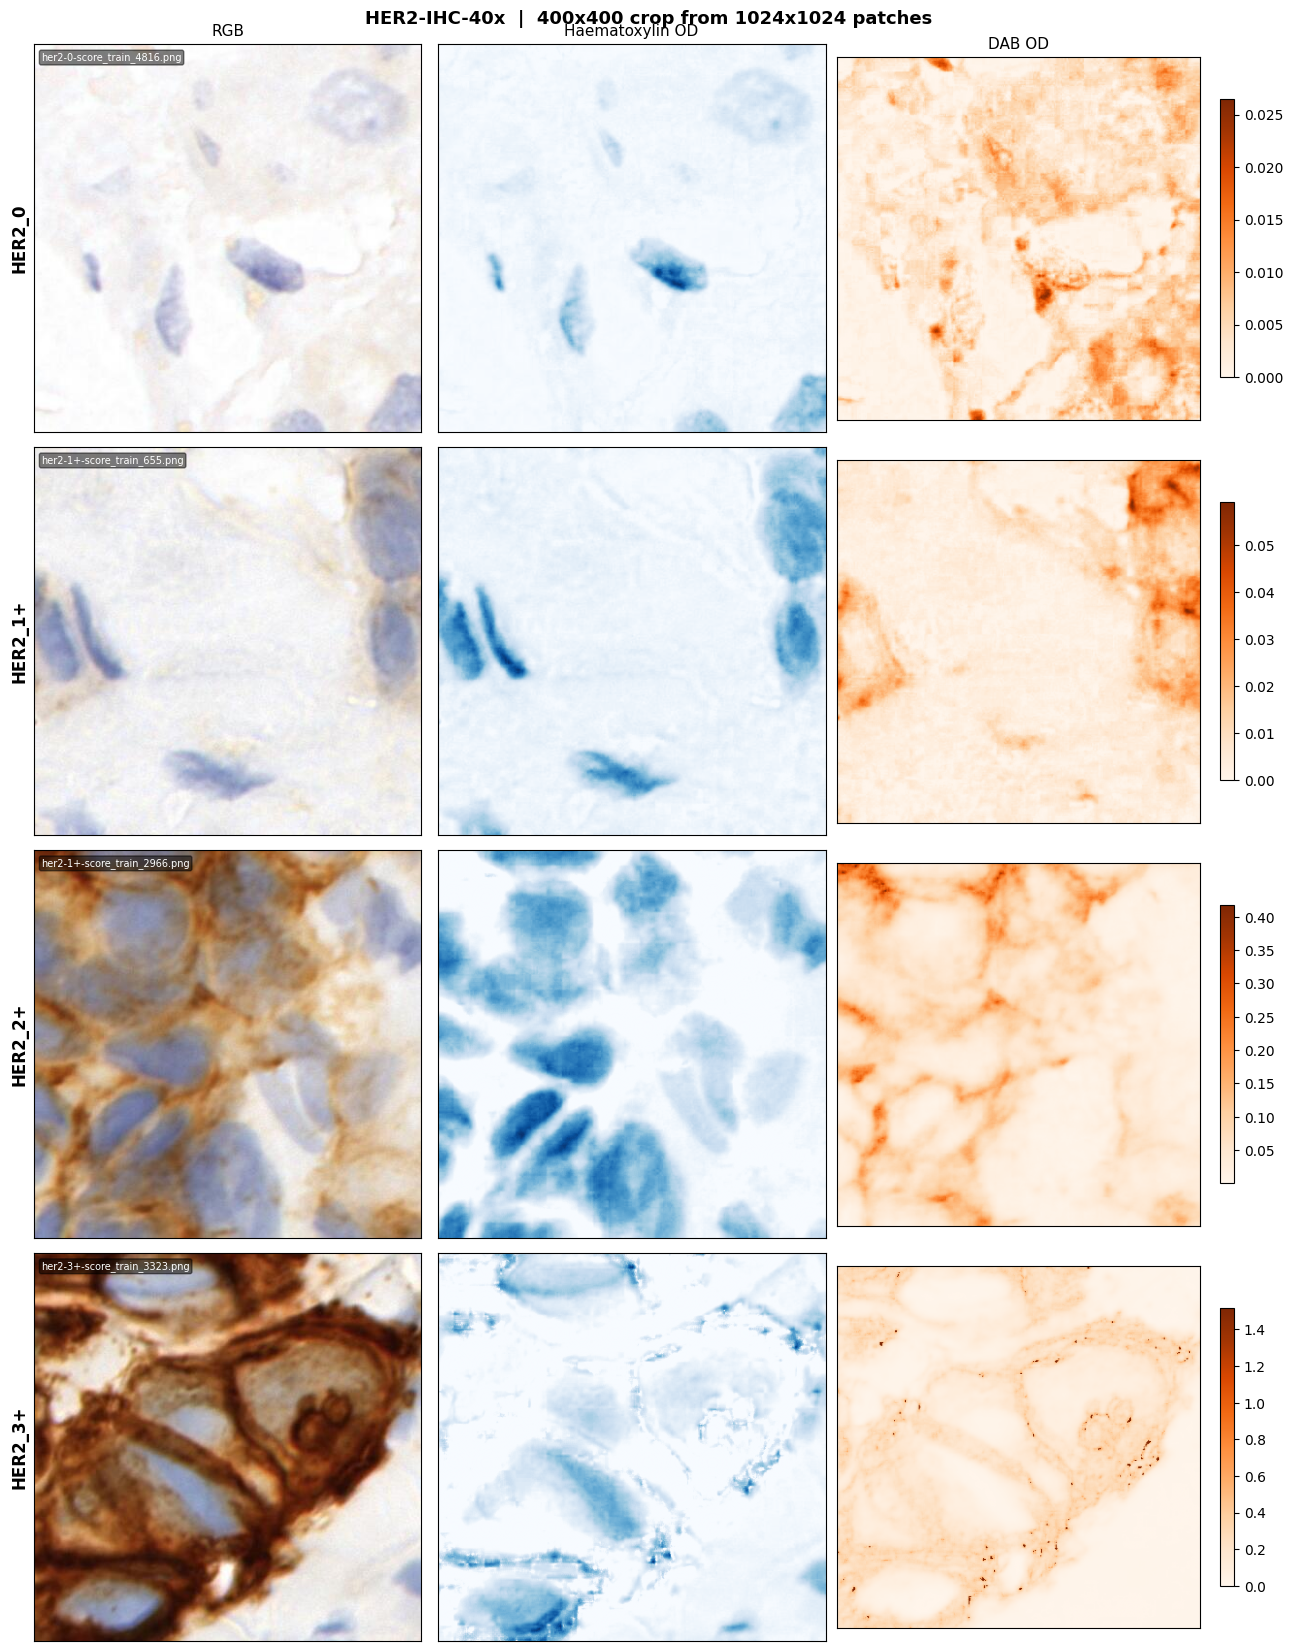


Whole-patch DAB OD statistics by grade (n=20 patches each):
  HER2_0    mean +0.0057   p95 +0.0136
  HER2_1+   mean +0.0100   p95 +0.0273
  HER2_2+   mean +0.0254   p95 +0.0744
  HER2_3+   mean +0.0957   p95 +0.2834


In [ ]:
# @title HER2 patches — RGB, haematoxylin and DAB channels by grade
# ============================================================
# Shows what Step H3 will actually be measuring. The point is to see
# WHERE the DAB sits relative to the nuclei, since that determines
# whether a nuclear mask can capture it.
# ============================================================

import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2hed

OUT_DIR = '/content/HER2_validation'
CROP = 400          # zoom into a corner so cells are visible at this figure size
SEED = 3
random.seed(SEED)

classes = ['HER2_0', 'HER2_1+', 'HER2_2+', 'HER2_3+']
fig, axes = plt.subplots(len(classes), 3, figsize=(13, 4.2 * len(classes)),
                         facecolor='white')

for r, c in enumerate(classes):
    files = sorted(glob.glob(os.path.join(OUT_DIR, c, '*.png')))
    if not files:
        for a in axes[r]: a.axis('off')
        continue
    p = random.choice(files)
    rgb = np.array(Image.open(p).convert('RGB'))[:CROP, :CROP]
    hed = rgb2hed(rgb)
    hema, dab = hed[:, :, 0], hed[:, :, 2]

    axes[r, 0].imshow(rgb)
    axes[r, 0].set_ylabel(c, fontsize=12, fontweight='bold')
    axes[r, 0].set_title('RGB' if r == 0 else '', fontsize=11)

    axes[r, 1].imshow(hema, cmap='Blues')
    axes[r, 1].set_title('Haematoxylin OD' if r == 0 else '', fontsize=11)

    im = axes[r, 2].imshow(dab, cmap='Oranges')
    axes[r, 2].set_title('DAB OD' if r == 0 else '', fontsize=11)
    plt.colorbar(im, ax=axes[r, 2], fraction=0.035)

    for a in axes[r]:
        a.set_xticks([]); a.set_yticks([])
    axes[r, 0].text(0.02, 0.98, os.path.basename(p)[:34], transform=axes[r, 0].transAxes,
                    va='top', fontsize=7, color='w',
                    bbox=dict(boxstyle='round,pad=0.2', fc='k', alpha=0.5))

plt.suptitle(f'HER2-IHC-40x  |  {CROP}x{CROP} crop from 1024x1024 patches',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# quick quantitative check: is DAB inside or outside nuclei?
print("\nWhole-patch DAB OD statistics by grade (n=20 patches each):")
for c in classes:
    files = sorted(glob.glob(os.path.join(OUT_DIR, c, '*.png')))
    sample = random.sample(files, min(20, len(files)))
    means, p95 = [], []
    for p in sample:
        d = rgb2hed(np.array(Image.open(p).convert('RGB')))[:, :, 2]
        means.append(d.mean()); p95.append(np.percentile(d, 95))
    print(f"  {c:<9} mean {np.mean(means):+.4f}   p95 {np.mean(p95):+.4f}")

In [ ]:
# @title Step H3 - H-DAB Deconvolution + Cellpose Segmentation + Per-Cell Measurement (All Files)
# ============================================================
# STEP H3: Deconvolution + Segmentation + Measurement
#
# Converts each RGB image to Hematoxylin and DAB optical density
# channels using the Ruifrok and Johnston (2001) H-DAB deconvolution
# matrix, segments cell nuclei on the Hematoxylin channel with
# Cellpose, and measures per-cell DAB optical density in a selectable
# subcellular compartment for H-score classification in Step H4.
#
# Compartment options:
#   Nuclear      measures inside the Cellpose nuclear mask. Correct for
#                nuclear markers such as Ki-67, p53, ER and PR.
#   Membrane     expands each nucleus and subtracts the nucleus itself,
#                leaving a ring. Correct for membranous markers such as
#                HER2, EGFR, PD-L1 and E-cadherin, where DAB surrounds a
#                counterstained nucleus and a nuclear mask reads the
#                unstained interior.
#   Whole cell   expanded mask including the nucleus. Suitable for
#                cytoplasmic markers.
#
# Each figure is written to disk and closed immediately after it is
# rendered and shown, only the file path is kept in memory afterward.
# This means Format and DPI must be set before running (they determine
# how each figure gets saved at processing time), changing them
# afterward does not retroactively change already-processed files,
# rerun those specific files to regenerate them at new settings.
#
# After the full batch completes, individual files can be reprocessed
# with different segmentation parameters, a different model, or a
# different compartment without re-running the whole batch. Rerun
# results are appended below the original results rather than
# replacing the display.
#
# The segmentation model list is read from the installed Cellpose
# package at runtime. Required packages are installed automatically
# if missing.
# ============================================================

import os, shutil, zipfile, gc, resource
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import subprocess, sys
from IPython.display import display, clear_output
from PIL import Image as PILImage
from skimage.color import rgb2hed, label2rgb
from skimage import measure
from skimage.segmentation import find_boundaries, expand_labels
from skimage.measure import regionprops
from collections import OrderedDict

def _mem_mb():
    """Current process peak resident memory in MB (Linux, stdlib only)."""
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024

# ── Dependencies ──────────────────────────────────────────────
def _try_import_cellpose():
    try:
        from cellpose import models as _models
        return _models, None
    except ImportError as e:
        return None, str(e)

def _try_import_dinov3():
    try:
        import dinov3
        return True, None
    except ImportError as e:
        return False, str(e)

models, _cp_err = _try_import_cellpose()
_dinov3_ok, _dino_err = _try_import_dinov3()

if models is None or not _dinov3_ok:
    print("Installing necessary packages...")

if models is None:
    try:
        _r = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', 'cellpose'],
            capture_output=True, text=True, timeout=900)
        if _r.returncode != 0:
            print("Cellpose installation failed:")
            print(_r.stderr[-1500:] if _r.stderr else '(no error output)')
        else:
            models, _cp_err = _try_import_cellpose()
            if models is None:
                print(f"Cellpose installed but import failed: {_cp_err}")
                print("Restart the runtime (Runtime > Restart session) and re-run this cell.")
    except subprocess.TimeoutExpired:
        print("Cellpose installation timed out. Check your network connection.")
    except Exception as e:
        print(f"Cellpose installation error: {e}")

if models is None:
    print("Cellpose is required for this step and could not be installed.")
    raise SystemExit

if not _dinov3_ok:
    try:
        _r = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q',
             'git+https://github.com/facebookresearch/dinov3'],
            capture_output=True, text=True, timeout=900)
        if _r.returncode == 0:
            _dinov3_ok, _dino_err = _try_import_dinov3()
    except Exception:
        pass

if not IHC_STATE.get('file_marker'):
    print("Run Step H2 first.")
    raise SystemExit

use_gpu = torch.cuda.is_available()

try:
    import importlib.metadata
    _CP_VERSION = importlib.metadata.version('cellpose')
except Exception:
    _CP_VERSION = '0.0.0'
_CP_MAJOR = int(_CP_VERSION.split('.')[0])

# ── Segmentation model registry ──────────────────────────────
_INSTALLED_MODEL_NAMES = None
if _CP_MAJOR >= 4:
    try:
        from cellpose.models import MODEL_NAMES as _INSTALLED_MODEL_NAMES
    except ImportError:
        _INSTALLED_MODEL_NAMES = None

_KNOWN_MODEL_INFO = OrderedDict([
    ('cpsam_v2', {
        'backbone': 'SAM-ViTL',
        'why': 'Best default for most images. Fewer spurious masks in low-contrast '
               'regions than the original cpsam. Start here for Hematoxylin.',
        'requires_dinov3': False,
    }),
    ('cpsam', {
        'backbone': 'SAM-ViTL',
        'why': 'Original CellposeSAM release. Mainly useful to reproduce results '
               'from a prior analysis that specifically used this version.',
        'requires_dinov3': False,
    }),
    ('cpdino', {
        'backbone': 'DINOv3-ViTL',
        'why': 'Larger 384x384 processing tile instead of the SAM models\' fixed '
               '256x256. Worth trying if hematoxylin-stained nuclei are unusually '
               'large, elongated, or densely packed and cpsam_v2 is merging or '
               'fragmenting them.',
        'requires_dinov3': True,
    }),
    ('cpdino-vitb', {
        'backbone': 'DINOv3-ViTB',
        'why': 'Smaller and faster DINO variant. Use for large batches or memory limits.',
        'requires_dinov3': True,
    }),
])

CP4_MODEL_INFO = OrderedDict()
if _CP_MAJOR >= 4:
    _names = _INSTALLED_MODEL_NAMES if _INSTALLED_MODEL_NAMES is not None else list(_KNOWN_MODEL_INFO.keys())
    for name in _names:
        if name in _KNOWN_MODEL_INFO:
            info = dict(_KNOWN_MODEL_INFO[name])
        else:
            info = {'backbone': 'unknown',
                    'why': 'Available in this Cellpose installation.',
                    'requires_dinov3': False}
        if info.get('requires_dinov3') and not _dinov3_ok:
            continue
        CP4_MODEL_INFO[name] = info

MODEL_OPTIONS = list(CP4_MODEL_INFO.keys()) if _CP_MAJOR >= 4 else ['nuclei']
MODEL_DEFAULT = ('cpsam_v2' if 'cpsam_v2' in MODEL_OPTIONS
                  else (MODEL_OPTIONS[0] if MODEL_OPTIONS else None))

if not MODEL_OPTIONS:
    print("No segmentation model available. Check your Cellpose installation.")
    raise SystemExit

def _ihc_norm_disp(arr):
    p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip((arr - p1) / (p99 - p1 + 1e-8), 0, 1)

def _ihc_build_model(mt, gpu):
    if _CP_MAJOR >= 4:
        return models.CellposeModel(gpu=gpu, pretrained_model=mt)
    return models.Cellpose(gpu=gpu, model_type='nuclei')

def _ihc_run_cellpose(model, img_2d, diameter, flow_t, prob_t, min_sz):
    kw = dict(flow_threshold=flow_t, cellprob_threshold=prob_t, min_size=min_sz)
    if diameter is not None:
        kw['diameter'] = diameter
    if _CP_MAJOR >= 4:
        masks, _, _ = model.eval(img_2d, **kw)
    else:
        masks, _, _, _ = model.eval(img_2d, channels=[0, 0], **kw)
    return masks

# ── Compartment construction ─────────────────────────────────
COMPARTMENT_LABELS = {
    'nuclear':  'Nuclear',
    'membrane': 'Membrane ring',
    'whole':    'Whole cell',
}

def _estimate_nuclear_diameter(masks):
    """
    Median equivalent circle diameter of the segmented objects, measured
    directly from mask geometry so the expansion distance scales with the
    cell size actually present in each image rather than a fixed pixel
    count. Patches in some public datasets are resized rather than
    cropped, so pixel scale is not guaranteed constant between files.
    """
    props = regionprops(masks)
    if not props:
        return 30.0
    areas = np.array([p.area for p in props], dtype=np.float64)
    return float(np.median(np.sqrt(4 * areas / np.pi)))

def _build_measurement_mask(masks, compartment, ring_ratio):
    """
    Returns (measure_mask, ring_radius_px). Labels are preserved from the
    nuclear mask so every region can be matched back to its own cell.
    expand_labels is collision aware, so neighbouring cells stop at each
    other rather than overlapping.
    """
    if compartment == 'nuclear':
        return masks.copy(), 0

    diam = _estimate_nuclear_diameter(masks)
    radius = max(1, int(round((diam / 2.0) * ring_ratio)))
    expanded = expand_labels(masks, distance=radius)

    if compartment == 'whole':
        return expanded.astype(masks.dtype), radius

    ring = expanded.copy()
    ring[masks > 0] = 0
    return ring.astype(masks.dtype), radius

def _make_ihc_panel(rgb, masks, measure_mask, hema_od, dab_od, fname,
                    subfolder, marker, model_name, n_cells,
                    compartment, ring_radius):
    hema_n = _ihc_norm_disp(hema_od)
    seg_rgb = label2rgb(masks, image=hema_n, bg_label=0, alpha=0.40, image_alpha=1.0)
    seg_rgb = np.clip(seg_rgb, 0, 1)
    meas_rgb = label2rgb(measure_mask, image=hema_n, bg_label=0, alpha=0.55, image_alpha=1.0)
    meas_rgb = np.clip(meas_rgb, 0, 1)
    bounds = find_boundaries(masks, mode='outer')

    fig, axes = plt.subplots(1, 4, figsize=(21, 5.5), facecolor='white')

    axes[0].imshow(rgb)
    axes[0].set_title('Original', fontsize=10, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(seg_rgb)
    axes[1].set_title(f'Cellpose nuclei ({model_name})  {n_cells} cells',
                      fontsize=10, fontweight='bold')
    axes[1].axis('off')

    comp_title = COMPARTMENT_LABELS.get(compartment, compartment)
    if compartment != 'nuclear':
        comp_title += f'  (r={ring_radius}px)'
    axes[2].imshow(meas_rgb)
    axes[2].set_title(f'Measurement region: {comp_title}',
                      fontsize=10, fontweight='bold')
    axes[2].axis('off')

    dab_disp = _ihc_norm_disp(dab_od)
    im = axes[3].imshow(dab_disp, cmap='Oranges')
    axes[3].contour(bounds, colors='#2c3e50', linewidths=0.4)
    cb = fig.colorbar(im, ax=axes[3], fraction=0.035, pad=0.02)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('DAB OD (normalized)', fontsize=7)
    axes[3].set_title('DAB optical density', fontsize=10, fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(f"{subfolder} / {fname}   marker={marker}   "
                 f"{n_cells} cells   compartment={COMPARTMENT_LABELS.get(compartment, compartment)}",
                 fontsize=11, fontweight='bold')
    plt.tight_layout(pad=0.8)
    return fig

def _save_ihc_fig(fig, base, fmt, dpi):
    """base must have NO extension. Returns saved path."""
    if fmt == 'PNG':
        out = base + '.png'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    elif fmt == 'TIFF':
        out = base + '.tiff'
        fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    else:
        out = base + '.svg'
        fig.savefig(out, format='svg', bbox_inches='tight', facecolor='white')
    return out

def _process_one_file(f, model, mt, diam, flow_t, prob_t, min_sz, fmt, dpi,
                      compartment, ring_ratio):
    """
    Runs deconvolution, segmentation, and measurement for a single file,
    then immediately saves the figure to disk and closes it. Only the
    saved file path is returned, the live Figure object is not kept, so
    memory does not accumulate across a large batch.
    Returns (df_f, saved_path, n_cells, n_dropped).
    """
    marker = IHC_STATE['file_marker'][f['path']]
    img = PILImage.open(f['path']).convert('RGB')
    rgb = np.array(img)
    hed = rgb2hed(rgb)
    hema_od = hed[:, :, 0].astype(np.float32)
    dab_od  = hed[:, :, 2].astype(np.float32)
    hema_u8 = (_ihc_norm_disp(hema_od) * 255).astype(np.uint8)
    masks = _ihc_run_cellpose(model, hema_u8, diam, flow_t, prob_t, min_sz)
    n_cells = int(masks.max())

    measure_mask, ring_radius = _build_measurement_mask(masks, compartment, ring_ratio)

    nuc_props = measure.regionprops_table(
        masks, intensity_image=dab_od,
        properties=['label', 'area', 'centroid', 'intensity_mean'])
    nuc_df = pd.DataFrame(nuc_props).rename(
        columns={'intensity_mean': 'DAB_OD_nuclear',
                 'centroid-0': 'y_px', 'centroid-1': 'x_px'})

    hema_props = measure.regionprops_table(
        masks, intensity_image=hema_od, properties=['label', 'intensity_mean'])
    hema_df = pd.DataFrame(hema_props).rename(
        columns={'intensity_mean': 'Hematoxylin_OD_mean'})

    meas_props = measure.regionprops_table(
        measure_mask, intensity_image=dab_od,
        properties=['label', 'area', 'intensity_mean'])
    meas_df = pd.DataFrame(meas_props).rename(
        columns={'area': 'measure_area', 'intensity_mean': 'DAB_OD_mean'})

    df_f = nuc_df.merge(hema_df, on='label', how='left')
    n_before = len(df_f)
    df_f = df_f.merge(meas_df, on='label', how='inner')
    n_dropped = n_before - len(df_f)

    df_f['file']        = f['filename']
    df_f['file_path']   = f['path']
    df_f['subfolder']   = f['subfolder']
    df_f['marker']      = marker
    df_f['superfolder'] = IHC_STATE.get('superfolder', '')
    df_f['segmentation_model'] = mt
    df_f['compartment']        = compartment
    df_f['ring_radius_px']     = ring_radius

    fig = _make_ihc_panel(rgb, masks, measure_mask, hema_od, dab_od,
                          f['filename'], f['subfolder'], marker, mt, n_cells,
                          compartment, ring_radius)
    plt.show()

    base = (f"{f['subfolder']}_{os.path.splitext(f['filename'])[0]}"
            f"_seg_{compartment}")
    saved_path = _save_ihc_fig(fig, base, fmt, dpi)
    plt.close(fig)
    del fig, rgb, hed, hema_od, dab_od, hema_u8, masks, measure_mask
    gc.collect()

    return df_f, saved_path, n_cells, n_dropped

def _replace_fig_entry(figs_info, fpath, new_entry):
    """Replace the entry for fpath in-place if present, otherwise append."""
    for i, entry in enumerate(figs_info):
        if entry[4] == fpath:
            figs_info[i] = new_entry
            return
    figs_info.append(new_entry)

# ══════════════════════════════════════════════════════════════
# PROCESSING SETTINGS
# Format and DPI here apply at processing time, each figure is saved
# and closed immediately after it is generated, so these must be set
# before clicking Run or Rerun, not chosen afterward at export time.
# ══════════════════════════════════════════════════════════════
model_dd = widgets.Dropdown(
    options=MODEL_OPTIONS, value=MODEL_DEFAULT, description='Model:',
    style={'description_width': '130px'}, layout=widgets.Layout(width='340px'))

if _CP_MAJOR >= 4:
    _rows_html = ""
    for k, v in CP4_MODEL_INFO.items():
        _rows_html += (
            "<tr>"
            f"<td style='padding:4px 8px;font-family:monospace'>{k}</td>"
            f"<td style='padding:4px 8px'>{v['backbone']}</td>"
            f"<td style='padding:4px 8px;max-width:340px'>{v['why']}</td>"
            "</tr>"
        )
    model_table_html = widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
        "<b>Model options</b><br>"
        "<table style='margin-top:4px;border-collapse:collapse'>"
        "<tr style='color:#9b59b6'>"
        "<th style='padding:4px 8px;text-align:left'>Name</th>"
        "<th style='padding:4px 8px;text-align:left'>Backbone</th>"
        "<th style='padding:4px 8px;text-align:left'>Why use it</th>"
        "</tr>" + _rows_html + "</table>"
        "</div>"
    )
else:
    model_table_html = widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #9b59b6'>"
        "Cellpose 3.x detected, using the legacy 'nuclei' model.</div>"
    )

compartment_radio = widgets.RadioButtons(
    options=[('Nuclear, measure inside the nuclear mask', 'nuclear'),
             ('Membrane ring, expand then subtract the nucleus', 'membrane'),
             ('Whole cell, expanded mask including the nucleus', 'whole')],
    value='nuclear',
    layout=widgets.Layout(width='620px'))

ring_ratio_sl = widgets.FloatSlider(
    value=0.5, min=0.05, max=2.0, step=0.05, description='Expansion ratio:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='420px'), readout_format='.2f')

ring_ratio_note = widgets.HTML(
    "<small style='color:gray'>Expansion distance = ratio x (measured nuclear "
    "diameter / 2). 0.5 gives a ring roughly half a nuclear radius wide. The "
    "diameter is measured from the segmented objects in each image, so the "
    "expansion adapts to images at different pixel scales.</small>")

compartment_help = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#ccc;border-radius:6px;border-left:3px solid #3498db'>"
    "<b>Choosing a compartment</b><br><br>"
    "<b>Nuclear</b> for markers that localise to the nucleus, such as Ki-67, "
    "p53, ER and PR. This is the default and reproduces the behaviour of "
    "earlier versions of this step.<br><br>"
    "<b>Membrane ring</b> for markers that localise to the cell membrane, such "
    "as HER2, EGFR, PD-L1 and E-cadherin. In these stains the DAB forms a ring "
    "around a hematoxylin counterstained nucleus, so a nuclear mask measures "
    "the unstained interior and systematically under-reads the signal.<br><br>"
    "<b>Whole cell</b> for cytoplasmic markers, where signal fills the cell "
    "body rather than outlining it.<br><br>"
    "Cells that end up with no pixels in the chosen compartment, which can "
    "happen in confluent tissue where a nucleus is completely enclosed by its "
    "neighbours, are excluded from the measurement and reported in the run log."
    "</div>")

ring_box = widgets.VBox([])

def _on_compartment(change):
    if change['new'] == 'nuclear':
        ring_box.children = []
    else:
        ring_box.children = [ring_ratio_sl, ring_ratio_note]
compartment_radio.observe(_on_compartment, names='value')

diam_sl  = widgets.FloatSlider(value=0, min=0, max=100, step=1, description='Diameter (0=auto):',
                                style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
flow_sl  = widgets.FloatSlider(value=0.4, min=0, max=1, step=0.05, description='Flow threshold:',
                                style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
prob_sl  = widgets.FloatSlider(value=0.0, min=-6, max=6, step=0.5, description='Cellprob threshold:',
                                style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
minsz_sl = widgets.IntSlider(value=15, min=0, max=200, step=5, description='Min size (px):',
                              style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))

fmt_radio  = widgets.RadioButtons(
    options=['PNG', 'SVG', 'TIFF'], value='PNG',
    description='Save format:', style={'description_width': '90px'},
    layout=widgets.Layout(width='300px'))
dpi_slider = widgets.IntSlider(
    value=150, min=72, max=600, step=10, description='DPI:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='300px'))
dpi_note   = widgets.HTML(
    "<small style='color:gray'>DPI applies to PNG and TIFF only</small>")
fmt_box    = widgets.HBox(
    [fmt_radio, widgets.VBox([dpi_slider, dpi_note])],
    layout=widgets.Layout(align_items='flex-start', gap='20px'))

def _on_fmt(change): dpi_slider.disabled = (change['new'] == 'SVG')
fmt_radio.observe(_on_fmt, names='value')

fmt_note = widgets.HTML(
    "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
    "background:#1a1a2e;color:#999;border-radius:6px;border-left:3px solid #3498db'>"
    "Each figure is written to disk and freed from memory as soon as it is "
    "generated, this format and DPI is what gets used, set it before running. "
    "Changing it afterward only affects files you rerun after the change.</div>"
)

run_all_btn = widgets.Button(description='Run All Files', button_style='success',
                              layout=widgets.Layout(width='220px', height='40px'))
run_progress = widgets.IntProgress(
    value=0, min=0, max=1, description='Idle', bar_style='',
    layout=widgets.Layout(width='420px'))
run_progress_label = widgets.HTML(value='')
h3_out = widgets.Output()

rerun_container = widgets.VBox([], layout=widgets.Layout(display='none'))
save_panel       = widgets.VBox([], layout=widgets.Layout(display='none'))

def _on_run_all(b):
    if IHC_STATE.get('_h3_running'):
        return
    IHC_STATE['_h3_running'] = True
    run_all_btn.disabled = True
    try:
        with h3_out:
            clear_output()
            mt   = model_dd.value
            fmt  = fmt_radio.value
            dpi  = dpi_slider.value
            comp = compartment_radio.value
            rr   = ring_ratio_sl.value
            print(f"Building Cellpose ({mt})...")
            print(f"Compartment: {COMPARTMENT_LABELS[comp]}"
                  + (f", expansion ratio {rr:.2f}" if comp != 'nuclear' else ''))
            print(f"Save format: {fmt}" + (f" at {dpi} DPI" if fmt != 'SVG' else ''))
            print(f"Starting memory: {_mem_mb():.0f} MB\n")
            model = _ihc_build_model(mt, use_gpu)
            diam = diam_sl.value if diam_sl.value > 0 else None
            batch_files = IHC_STATE['batch_files']
            all_dfs = []
            figs_info = []
            total_dropped = 0

            run_progress.max = len(batch_files)
            run_progress.value = 0
            run_progress.bar_style = 'info'

            for i, f in enumerate(batch_files, 1):
                marker = IHC_STATE['file_marker'][f['path']]
                run_progress.description = f'{i-1}/{len(batch_files)}'
                run_progress_label.value = (
                    f"<span style='font-size:12px'>Processing <b>{i}/{len(batch_files)}</b>: "
                    f"{f['subfolder']}/{f['filename']}...</span>")
                print(f"[{i}/{len(batch_files)}] {f['filename']} ({marker})...")
                df_f, saved_path, n_cells, n_dropped = _process_one_file(
                    f, model, mt, diam, flow_sl.value, prob_sl.value,
                    minsz_sl.value, fmt, dpi, comp, rr)
                all_dfs.append(df_f)
                total_dropped += n_dropped
                base = (f"{f['subfolder']}_{os.path.splitext(f['filename'])[0]}"
                        f"_seg_{comp}")
                figs_info.append((saved_path, base, f['subfolder'], f['filename'], f['path']))
                drop_txt = f" | {n_dropped} without compartment pixels" if n_dropped else ""
                print(f"    {n_cells} cells segmented{drop_txt} | saved: {saved_path} | "
                      f"RAM: {_mem_mb():.0f} MB")
                run_progress.value = i
                run_progress.description = f'{i}/{len(batch_files)}'

            run_progress.bar_style = 'success'
            run_progress_label.value = (
                f"<span style='font-size:12px;color:#2ecc71'>"
                f"Complete: {len(batch_files)}/{len(batch_files)} files processed.</span>")

            IHC_STATE['batch_df'] = pd.concat(all_dfs, ignore_index=True)
            IHC_STATE['_seg_figs_info'] = figs_info
            IHC_STATE['_last_rerun_paths'] = set()
            IHC_STATE['compartment']       = comp
            IHC_STATE['ring_ratio']        = rr if comp != 'nuclear' else None
            print(f"\nTotal: {len(IHC_STATE['batch_df'])} cells across {len(batch_files)} file(s).")
            if total_dropped:
                print(f"{total_dropped} cell(s) excluded for having no pixels in the "
                      f"selected compartment.")
            print(f"{len(figs_info)} figure(s) saved and ready for export below.")
            print(f"Final memory: {_mem_mb():.0f} MB")
            print("\nBatch complete. Rerun individual files below if needed, "
                  "then proceed to Step H4 (H-Score Threshold & Classification).")
    finally:
        IHC_STATE['_h3_running'] = False
        run_all_btn.disabled = False

    rerun_container.children = [_build_rerun_panel()]
    rerun_container.layout.display = ''
    save_panel.layout.display = ''

run_all_btn._click_handlers.callbacks.clear()
run_all_btn.on_click(_on_run_all)

# ══════════════════════════════════════════════════════════════
# RERUN PANEL - built fresh each time the batch completes.
# ══════════════════════════════════════════════════════════════
def _build_rerun_panel():
    batch_files = IHC_STATE.get('batch_files', [])
    latest_counts = {}
    if IHC_STATE.get('batch_df') is not None:
        for fpath, grp in IHC_STATE['batch_df'].groupby('file_path'):
            latest_counts[fpath] = len(grp)

    rerun_cbs = {}
    rows = [widgets.HBox([
        widgets.HTML("<b style='font-size:11px'>Select</b>", layout=widgets.Layout(width='60px')),
        widgets.HTML("<b style='font-size:11px'>File (subfolder/name)</b>", layout=widgets.Layout(width='340px')),
        widgets.HTML("<b style='font-size:11px'>Cells (latest run)</b>", layout=widgets.Layout(width='140px')),
    ], layout=widgets.Layout(background='#1a1a2e', padding='4px 8px', border_radius='4px', gap='8px'))]

    for f in batch_files:
        cb = widgets.Checkbox(value=False, description='', indent=False,
                              layout=widgets.Layout(width='60px'))
        rerun_cbs[f['path']] = cb
        n = latest_counts.get(f['path'], '?')
        rows.append(widgets.HBox([
            cb,
            widgets.HTML(f"<span style='font-size:11px;font-family:monospace;color:#ccc'>"
                        f"{f['subfolder']}/{f['filename']}</span>",
                        layout=widgets.Layout(width='340px')),
            widgets.HTML(f"<code style='font-size:11px'>{n}</code>",
                        layout=widgets.Layout(width='140px')),
        ], layout=widgets.Layout(align_items='center', margin='1px 0', gap='8px')))

    sel_all_btn   = widgets.Button(description='Select All', layout=widgets.Layout(width='100px', height='28px'))
    desel_all_btn = widgets.Button(description='Deselect All', layout=widgets.Layout(width='100px', height='28px'))
    sel_all_btn.on_click(lambda b: [cb.__setattr__('value', True) for cb in rerun_cbs.values()])
    desel_all_btn.on_click(lambda b: [cb.__setattr__('value', False) for cb in rerun_cbs.values()])

    select_table = widgets.VBox(
        rows, layout=widgets.Layout(border='1px solid #333', border_radius='6px',
                                    max_height='2000px', overflow_y='auto'))

    rerun_model_dd = widgets.Dropdown(
        options=MODEL_OPTIONS, value=model_dd.value, description='Model:',
        style={'description_width': '130px'}, layout=widgets.Layout(width='340px'))
    rerun_comp_radio = widgets.RadioButtons(
        options=[('Nuclear', 'nuclear'),
                 ('Membrane ring', 'membrane'),
                 ('Whole cell', 'whole')],
        value=compartment_radio.value,
        description='Compartment:', style={'description_width': '130px'},
        layout=widgets.Layout(width='420px'))
    rerun_ring_sl = widgets.FloatSlider(
        value=ring_ratio_sl.value, min=0.05, max=2.0, step=0.05,
        description='Expansion ratio:', style={'description_width': '150px'},
        layout=widgets.Layout(width='420px'), readout_format='.2f',
        disabled=(rerun_comp_radio.value == 'nuclear'))
    def _on_rerun_comp(change):
        rerun_ring_sl.disabled = (change['new'] == 'nuclear')
    rerun_comp_radio.observe(_on_rerun_comp, names='value')

    rerun_diam_sl  = widgets.FloatSlider(value=diam_sl.value, min=0, max=100, step=1,
                                         description='Diameter (0=auto):',
                                         style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
    rerun_flow_sl  = widgets.FloatSlider(value=flow_sl.value, min=0, max=1, step=0.05,
                                         description='Flow threshold:',
                                         style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
    rerun_prob_sl  = widgets.FloatSlider(value=prob_sl.value, min=-6, max=6, step=0.5,
                                         description='Cellprob threshold:',
                                         style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
    rerun_minsz_sl = widgets.IntSlider(value=minsz_sl.value, min=0, max=200, step=5,
                                       description='Min size (px):',
                                       style={'description_width':'150px'}, layout=widgets.Layout(width='420px'))
    rerun_fmt_radio = widgets.RadioButtons(
        options=['PNG', 'SVG', 'TIFF'], value=fmt_radio.value,
        description='Save format:', style={'description_width': '90px'},
        layout=widgets.Layout(width='300px'))
    rerun_dpi_slider = widgets.IntSlider(
        value=dpi_slider.value, min=72, max=600, step=10, description='DPI:',
        style={'description_width': '50px'}, layout=widgets.Layout(width='300px'),
        disabled=(rerun_fmt_radio.value == 'SVG'))
    def _on_rerun_fmt(change): rerun_dpi_slider.disabled = (change['new'] == 'SVG')
    rerun_fmt_radio.observe(_on_rerun_fmt, names='value')

    rerun_note = widgets.HTML(
        "<div style='font-size:11px;padding:8px 12px;margin:6px 0;"
        "background:#332b12;color:#f5d78e;border-radius:6px;"
        "border-left:3px solid #f39c12'>"
        "Mixing compartments within one batch means Step H4 will threshold a "
        "pooled optical density distribution drawn from different measurement "
        "regions. Use the same compartment for every file in a batch unless you "
        "are deliberately comparing them.</div>")

    rerun_go_btn = widgets.Button(description='Rerun Selected', button_style='warning',
                                  layout=widgets.Layout(width='220px', height='40px'))
    rerun_progress = widgets.IntProgress(
        value=0, min=0, max=1, description='Idle', bar_style='',
        layout=widgets.Layout(width='420px'))
    rerun_progress_label = widgets.HTML(value='')
    rerun_status = widgets.Output()

    def _on_rerun(b):
        selected_paths = [p for p, cb in rerun_cbs.items() if cb.value]
        with rerun_status:
            clear_output()
            if not selected_paths:
                print("Select at least one file to rerun.")
                return
        if IHC_STATE.get('_h3_running'):
            with rerun_status:
                print("Batch is still running, wait for it to finish first.")
            return

        IHC_STATE['_h3_running'] = True
        rerun_go_btn.disabled = True
        try:
            rerun_progress.max = len(selected_paths)
            rerun_progress.value = 0
            rerun_progress.bar_style = 'info'
            rerun_progress.description = f'0/{len(selected_paths)}'

            with h3_out:
                mt   = rerun_model_dd.value
                diam = rerun_diam_sl.value if rerun_diam_sl.value > 0 else None
                fmt  = rerun_fmt_radio.value
                dpi  = rerun_dpi_slider.value
                comp = rerun_comp_radio.value
                rr   = rerun_ring_sl.value
                print(f"\n{'='*55}")
                print(f"  RERUN: {len(selected_paths)} file(s) with model={mt}, "
                      f"compartment={COMPARTMENT_LABELS[comp]}")
                print(f"{'='*55}")
                print(f"Memory before rerun: {_mem_mb():.0f} MB")
                model = _ihc_build_model(mt, use_gpu)

                batch_by_path = {f['path']: f for f in IHC_STATE['batch_files']}
                new_dfs = []
                for i, fpath in enumerate(selected_paths, 1):
                    f = batch_by_path[fpath]
                    marker = IHC_STATE['file_marker'][fpath]
                    rerun_progress_label.value = (
                        f"<span style='font-size:12px'>Rerunning <b>{i}/{len(selected_paths)}</b>: "
                        f"{f['subfolder']}/{f['filename']}...</span>")
                    print(f"[{i}/{len(selected_paths)}] {f['filename']} ({marker})...")
                    df_f, saved_path, n_cells, n_dropped = _process_one_file(
                        f, model, mt, diam, rerun_flow_sl.value, rerun_prob_sl.value,
                        rerun_minsz_sl.value, fmt, dpi, comp, rr)
                    new_dfs.append(df_f)
                    base = (f"{f['subfolder']}_{os.path.splitext(f['filename'])[0]}"
                            f"_seg_{comp}")
                    drop_txt = f" | {n_dropped} without compartment pixels" if n_dropped else ""
                    print(f"    {n_cells} cells segmented (rerun){drop_txt} | "
                          f"saved: {saved_path} | RAM: {_mem_mb():.0f} MB")
                    _replace_fig_entry(IHC_STATE['_seg_figs_info'], fpath,
                                       (saved_path, base, f['subfolder'], f['filename'], fpath))
                    rerun_progress.value = i
                    rerun_progress.description = f'{i}/{len(selected_paths)}'

                rerun_progress.bar_style = 'success'
                rerun_progress_label.value = (
                    f"<span style='font-size:12px;color:#2ecc71'>"
                    f"Rerun complete: {len(selected_paths)}/{len(selected_paths)} files.</span>")

                old_df = IHC_STATE['batch_df']
                kept   = old_df[~old_df['file_path'].isin(selected_paths)]
                IHC_STATE['batch_df'] = pd.concat([kept] + new_dfs, ignore_index=True)
                IHC_STATE['_last_rerun_paths'] = set(selected_paths)

                print(f"\nRerun complete. {len(selected_paths)} file(s) updated with "
                      f"model={mt}, compartment={COMPARTMENT_LABELS[comp]}"
                      + (f", expansion ratio={rr:.2f}" if comp != 'nuclear' else '')
                      + f", diameter={'auto' if diam is None else diam}, "
                      f"flow={rerun_flow_sl.value}, cellprob={rerun_prob_sl.value}, "
                      f"min_size={rerun_minsz_sl.value}, format={fmt}.")
                mixed = IHC_STATE['batch_df']['compartment'].nunique()
                if mixed > 1:
                    print(f"Note: this batch now contains {mixed} different "
                          f"compartments. Step H4 thresholds a pooled distribution "
                          f"across all of them.")
                print(f"Memory after rerun: {_mem_mb():.0f} MB")
                print("Use the download scope toggle below to export only these "
                      "rerun files if needed.")
        finally:
            IHC_STATE['_h3_running'] = False
            rerun_go_btn.disabled = False

    rerun_go_btn._click_handlers.callbacks.clear()
    rerun_go_btn.on_click(_on_rerun)

    return widgets.VBox([
        widgets.HTML(
            "<hr><div style='font-size:13px;font-weight:bold;margin:10px 0 6px'>"
            "Rerun individual files</div>"
            "<div style='font-size:11px;color:#888;margin-bottom:8px'>"
            "Select files below, adjust parameters, model, compartment, or save "
            "format, and rerun only those files. Results appear below the existing "
            "plots for comparison, the measurement data used for Step H4 always "
            "reflects the most recent run for each file.</div>"),
        widgets.HBox([sel_all_btn, desel_all_btn], layout=widgets.Layout(gap='8px', margin='0 0 6px 0')),
        select_table,
        widgets.HTML('<br>'),
        rerun_model_dd, rerun_comp_radio, rerun_ring_sl, rerun_note,
        rerun_diam_sl, rerun_flow_sl, rerun_prob_sl, rerun_minsz_sl,
        widgets.HTML("<div style='font-size:11px;font-weight:bold;margin:8px 0 4px'>"
                     "Save format for rerun files:</div>"),
        widgets.HBox([rerun_fmt_radio, rerun_dpi_slider], layout=widgets.Layout(gap='20px')),
        widgets.HTML('<br>'),
        rerun_go_btn, rerun_progress, rerun_progress_label,
        rerun_status,
    ])

# ══════════════════════════════════════════════════════════════
# EXPORT PANEL: per-file marker tags, download scope toggle,
# save already-written figures to Drive or download as ZIP.
# Figures are already saved to disk during processing, this panel
# only copies or zips the existing files, it does not re-render them.
# ══════════════════════════════════════════════════════════════
_ihc_file_tags = {}
_ihc_tag_rows  = []

_ihc_tag_rows.append(widgets.HBox([
    widgets.HTML("<b style='font-size:11px'>File (subfolder/name)</b>",
                 layout=widgets.Layout(width='360px')),
    widgets.HTML("<b style='font-size:11px'>Tag to prepend</b>",
                 layout=widgets.Layout(width='220px')),
    widgets.HTML("<b style='font-size:11px'>Result in ZIP</b>",
                 layout=widgets.Layout(width='260px')),
], layout=widgets.Layout(background='#1a1a2e', padding='4px 8px',
                          border_radius='4px', gap='8px')))

for _fi in IHC_STATE.get('batch_files', []):
    _fpath   = _fi['path']
    _sf      = _fi['subfolder']
    _fname_s = _fi['filename']
    _marker  = IHC_STATE.get('file_marker', {}).get(_fpath, _sf)
    _display = f"{_sf}/{_fname_s}"

    _tb = widgets.Text(
        value=_marker,
        placeholder='e.g. Ki67 or leave empty',
        layout=widgets.Layout(width='220px'))

    _path_html = widgets.HTML(
        f"<span style='font-family:monospace;font-size:10px;color:#aaa'>"
        f"{_display}</span>",
        layout=widgets.Layout(width='360px'))

    _tag_safe = _marker.replace(' ', '_')
    _prev_html = widgets.HTML(
        f"<span style='font-size:10px;color:#2ecc71'>"
        f"{_tag_safe}_{_sf}/{_tag_safe}_{_fname_s}</span>",
        layout=widgets.Layout(width='260px'))

    def _upd_ihc_tag(ch, pw=_prev_html, sf=_sf, fn_s=_fname_s):
        t = ch['new'].strip().replace(' ', '_')
        if t:
            pw.value = (f"<span style='font-size:10px;color:#2ecc71'>"
                        f"{t}_{sf}/{t}_{fn_s}</span>")
        else:
            pw.value = (f"<span style='font-size:10px;color:#888'>"
                        f"{sf}/{fn_s}</span>")
    _tb.observe(_upd_ihc_tag, names='value')

    _ihc_file_tags[_fpath] = _tb
    _ihc_tag_rows.append(widgets.HBox(
        [_path_html, _tb, _prev_html],
        layout=widgets.Layout(align_items='center', margin='1px 0', gap='8px')))

_ihc_tag_clear_btn = widgets.Button(description='Clear all',  button_style='',
                                    layout=widgets.Layout(width='100px', height='28px'))
_ihc_tag_reset_btn = widgets.Button(description='Reset to marker', button_style='',
                                    layout=widgets.Layout(width='120px', height='28px'))
_ihc_tag_clear_btn.on_click(lambda b: [tb.__setattr__('value', '')
                                       for tb in _ihc_file_tags.values()])
_ihc_tag_reset_btn.on_click(lambda b: [_ihc_file_tags[fi['path']].__setattr__(
    'value', IHC_STATE.get('file_marker', {}).get(fi['path'], fi['subfolder']))
    for fi in IHC_STATE.get('batch_files', []) if fi['path'] in _ihc_file_tags])

_ihc_tag_panel = widgets.VBox(
    [widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin:10px 0 4px'>"
        "File tag for ZIP structure:</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:6px'>"
        "Each file gets a tag prepended to its filename and folder in the ZIP.<br>"
        "Pre-filled with the marker name from Step H2, edit or clear as needed.</div>"),
     widgets.HBox([_ihc_tag_clear_btn, _ihc_tag_reset_btn],
                  layout=widgets.Layout(gap='8px', margin='0 0 6px 0'))]
    + _ihc_tag_rows,
    layout=widgets.Layout(
        max_height='3000px', overflow_y='auto',
        border='1px solid #2d4a2d', border_radius='6px',
        padding='8px 12px', margin='6px 0 10px 0'))

def _ihc_arc_path(fpath, local_filename):
    tb      = _ihc_file_tags.get(str(fpath))
    raw_tag = tb.value.strip() if tb and tb.value.strip() else ''
    tag     = raw_tag.replace(' ', '_')
    subfolder = os.path.basename(os.path.dirname(str(fpath))) if fpath else ''
    bn      = os.path.basename(local_filename)

    if tag:
        folder_in_zip = f"{tag}_{subfolder}" if subfolder else tag
        tagged_bn     = f"{tag}_{subfolder}_{bn}" if not bn.startswith(tag) else bn
        return os.path.join(folder_in_zip, tagged_bn)
    else:
        return os.path.join(subfolder, bn) if subfolder else bn

dest_radio = widgets.RadioButtons(
    options=[
        ('Save alongside source files on Drive', 'source'),
        ('Save to a new output directory (mirrors structure)', 'mirror'),
    ],
    value='source',
    layout=widgets.Layout(width='700px'))

_ihc_source_folder = IHC_STATE.get('superfolder', '')
mirror_tb    = widgets.Text(
    value=(_ihc_source_folder.rstrip('/') + '/segmentation_output' if _ihc_source_folder else ''),
    placeholder='/content/drive/MyDrive/results/segmentation/',
    layout=widgets.Layout(width='600px'))
mirror_label = widgets.HTML(
    "<div style='font-size:11px;color:#555;margin:4px 0 2px'>"
    "Output root, subfolders mirror source structure</div>")
mirror_panel = widgets.VBox(
    [mirror_label, mirror_tb],
    layout=widgets.Layout(padding='6px 0 0 20px', display='none'))

def _toggle_mirror(change):
    mirror_panel.layout.display = '' if change['new'] == 'mirror' else 'none'
dest_radio.observe(_toggle_mirror, names='value')

download_scope_radio = widgets.RadioButtons(
    options=[
        ('All files', 'all'),
        ('Only files from the most recent rerun', 'rerun_only'),
    ],
    value='all',
    layout=widgets.Layout(width='500px'))
download_scope_note = widgets.HTML(
    "<small style='color:gray'>'Only files from the most recent rerun' becomes "
    "meaningful after using the Rerun panel above, if no rerun has been done "
    "yet, this option exports nothing.</small>")

save_btn     = widgets.Button(
    description='Save to Drive',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='40px'))
download_btn = widgets.Button(
    description='Download as ZIP',
    button_style='info',
    layout=widgets.Layout(width='180px', height='40px'))
save_out     = widgets.Output()
download_out = widgets.Output()

save_panel.children = [
    widgets.HTML(
        "<hr><div style='font-size:13px;font-weight:bold;margin:10px 0 8px'>"
        "Export segmentation figures</div>"
        "<div style='font-size:11px;color:#888;margin-bottom:8px'>"
        "Figures are already saved to disk from processing above, this only "
        "copies or bundles the existing files, it does not re-render them.</div>"),
    _ihc_tag_panel,
    widgets.HTML(
        "<div style='font-size:12px;font-weight:bold;margin:10px 0 4px'>"
        "Download scope:</div>"),
    download_scope_radio,
    download_scope_note,
    widgets.HTML(
        "<hr style='margin:10px 0'>"
        "<div style='font-size:12px;font-weight:bold;margin:6px 0'>"
        "Option A: Save to Google Drive</div>"),
    dest_radio,
    mirror_panel,
    widgets.HTML('<br>'),
    save_btn,
    save_out,
    widgets.HTML(
        "<hr style='margin:10px 0'>"
        "<div style='font-size:12px;font-weight:bold;margin:6px 0'>"
        "Option B: Download to your computer</div>"
        "<small style='color:gray'>"
        "All matching figures are bundled into one zip file, one browser prompt.<br>"
        "You can use this with or without saving to Drive first."
        "</small><br><br>"),
    download_btn,
    download_out,
]

def _scoped_figs_info():
    figs_info = IHC_STATE.get('_seg_figs_info', [])
    if download_scope_radio.value == 'rerun_only':
        last = IHC_STATE.get('_last_rerun_paths', set())
        return [e for e in figs_info if e[4] in last]
    return figs_info

def do_save(b):
    """Copy already-saved figures to Drive. Does not trigger any download."""
    figs_info = _scoped_figs_info()
    if not figs_info:
        with save_out:
            clear_output()
            if download_scope_radio.value == 'rerun_only':
                print("No rerun has been done yet, nothing to export at this scope.")
            else:
                print("Run segmentation first.")
        return

    with save_out:
        clear_output()
        mode     = dest_radio.value
        out_root = mirror_tb.value.strip().rstrip('/')

        if mode == 'mirror' and not out_root:
            print("Enter output root path first."); return

        try:
            from google.colab import drive as gdrive
            if not os.path.exists('/content/drive/MyDrive'):
                print("Mounting Drive...")
                gdrive.mount('/content/drive')
        except Exception as e:
            print(f"Drive mount error: {e}"); return

        print(f"Saving {len(figs_info)} figure(s) to Drive...\n")
        saved, failed = [], []

        for local_path, base, subfolder, fname, fpath_fi in figs_info:
            if mode == 'source':
                src_fi = next((fi for fi in IHC_STATE.get('batch_files', [])
                               if fi['path'] == fpath_fi), None)
                if src_fi is None:
                    dest = os.path.join('.', os.path.basename(local_path))
                else:
                    dest = os.path.join(os.path.dirname(src_fi['path']),
                                        os.path.basename(local_path))
            else:
                arc  = _ihc_arc_path(fpath_fi or '', local_path)
                dest = os.path.join(out_root, arc)
                os.makedirs(os.path.dirname(dest), exist_ok=True)

            try:
                shutil.copy2(local_path, dest)
                saved.append(dest)
                print(f"  Saved: {dest}")
            except Exception as e:
                failed.append((local_path, str(e)))
                print(f"  Error: {e}")

        print(f"\n{'='*52}")
        print(f"  {len(saved)} file(s) saved to Drive")
        if failed: print(f"  {len(failed)} error(s)")
        print(f"{'='*52}")
        print("\nTo also download, click 'Download as ZIP' below.")

def do_download(b):
    if IHC_STATE.get('_download_running', False):
        return
    IHC_STATE['_download_running'] = True
    download_btn.disabled = True
    download_btn.description = 'Downloading...'

    file_to_download = None

    try:
        figs_info = _scoped_figs_info()
        if not figs_info:
            with download_out:
                clear_output()
                if download_scope_radio.value == 'rerun_only':
                    print("No rerun has been done yet, nothing to export at this scope.")
                else:
                    print("Run segmentation first.")
            return

        with download_out:
            clear_output()
            if len(figs_info) == 1:
                file_to_download = figs_info[0][0]
                print(f"Preparing: {os.path.basename(file_to_download)}")
            else:
                zip_path = 'ihc_segmentation_figures.zip'
                print(f"Bundling {len(figs_info)} files into {zip_path}...")
                with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
                    for local_path, base, subfolder, fname, fpath_fi in figs_info:
                        arcname = _ihc_arc_path(fpath_fi or '', local_path)
                        zf.write(local_path, arcname)
                        print(f"  Added: {arcname}")
                zip_mb = os.path.getsize(zip_path) / 1e6
                print(f"Ready: {zip_path} ({zip_mb:.1f} MB)")
                file_to_download = zip_path

    finally:
        IHC_STATE['_download_running'] = False
        download_btn.disabled = False
        download_btn.description = 'Download as ZIP'

    if file_to_download:
        from google.colab import files as colab_files
        colab_files.download(file_to_download)

save_btn._click_handlers.callbacks.clear()
download_btn._click_handlers.callbacks.clear()
save_btn.on_click(do_save)
download_btn.on_click(do_download)

display(widgets.VBox([
    model_dd, model_table_html,
    widgets.HTML("<div style='font-size:12px;font-weight:bold;margin:10px 0 4px'>"
                 "Measurement compartment:</div>"),
    compartment_radio, ring_box, compartment_help,
    diam_sl, flow_sl, prob_sl, minsz_sl,
    widgets.HTML("<div style='font-size:12px;font-weight:bold;margin:10px 0 4px'>"
                 "Save format (applied during processing):</div>"),
    fmt_box, fmt_note,
    run_all_btn, run_progress, run_progress_label, h3_out, rerun_container, save_panel,
]))

NameError: name 'IHC_STATE' is not defined

In [ ]:
# @title Threshold method comparison under 5-fold cross-validation
# ============================================================
# The calibrated thresholds above were fitted and evaluated on the same
# patches, so their performance is optimistic. This refits per fold and
# scores on held-out patches, giving numbers that are safe to publish.
# Fixed-rule methods (Otsu, Triangle, log-Otsu) are also scored per fold
# so every method is compared on identical splits.
# ============================================================

import os, itertools
import numpy as np, pandas as pd
from skimage.filters import threshold_otsu, threshold_yen, threshold_triangle
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold

OUT_DIR     = '/content/drive/MyDrive/HER2_IHC_40x/validation_run'
COMPARTMENT = 'membrane'
HCUTS       = (10, 50, 150)     # fixed, clinically plausible H-score bands
N_SPLITS, SEED = 5, 0

cells = pd.read_csv(os.path.join(OUT_DIR, f'cells_{COMPARTMENT}.csv'))
codes, files = pd.factorize(cells['file'])
x     = cells['DAB_OD_mean'].values.astype(np.float64)
truth = (cells.groupby('file')['her2_truth'].first()
              .reindex(files).map({'0':0,'1+':1,'2+':2,'3+':3}).values)
n_per = np.bincount(codes, minlength=len(files)).astype(float)

def hscores(t1, t2, t3, idx=None):
    band = np.searchsorted([t1, t2, t3], x, side='left')
    H = np.zeros(len(files))
    for b, w in [(1,1), (2,2), (3,3)]:
        H += w * 100 * np.bincount(codes[band == b], minlength=len(files)) / n_per
    return H if idx is None else H[idx]

def fit_thresholds(method, xtr):
    if method == 'otsu_yen':
        o = threshold_otsu(xtr); p = xtr[xtr > o]
        y = threshold_yen(p) if len(p) > 5 else o
        t1, t2 = sorted([o, y])
        return t1, t2, float(np.median(xtr[xtr > t2])) if (xtr > t2).any() else t2
    if method == 'triangle':
        t = threshold_triangle(xtr); return t, t*2.5, t*5
    if method == 'log_otsu':
        t = 10 ** threshold_otsu(np.log10(np.clip(xtr, 1e-5, None)))
        return t, t*2.5, t*5
    if method == 'calibrated':
        return None      # handled separately
    raise ValueError(method)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
METHODS = ['otsu_yen', 'triangle', 'log_otsu', 'calibrated']
scores = {m: {'rho': [], 'kappa': []} for m in METHODS}
scores['mean_OD'] = {'rho': [], 'kappa': []}
picked = {m: [] for m in METHODS}

for tr_i, te_i in skf.split(np.zeros(len(files)), truth):
    tr_mask = np.isin(codes, tr_i)
    xtr = x[tr_mask]

    for m in METHODS:
        if m == 'calibrated':
            grid = np.unique(np.percentile(xtr, np.linspace(20, 99.5, 22)))
            best = (-2, None)
            for c in itertools.combinations(grid, 3):
                r = spearmanr(hscores(*c, idx=tr_i), truth[tr_i]).correlation
                if r > best[0]: best = (r, c)
            t = best[1]
        else:
            t = fit_thresholds(m, xtr)
        picked[m].append(t)
        H = hscores(*t, idx=te_i)
        scores[m]['rho'].append(spearmanr(H, truth[te_i]).correlation)
        scores[m]['kappa'].append(
            cohen_kappa_score(np.digitize(H, HCUTS), truth[te_i], weights='quadratic'))

    mod = cells.groupby('file')['DAB_OD_mean'].mean().reindex(files).values
    scores['mean_OD']['rho'].append(spearmanr(mod[te_i], truth[te_i]).correlation)
    scores['mean_OD']['kappa'].append(np.nan)

print(f"5-fold cross-validated, H-score bands fixed at {HCUTS}\n")
print(f"{'method':<20} {'rho (mean+-sd)':>20} {'kappa (mean+-sd)':>20}")
print("-" * 62)
for m in METHODS + ['mean_OD']:
    r, k = np.array(scores[m]['rho']), np.array(scores[m]['kappa'])
    ks = "        n/a        " if np.isnan(k).all() else f"{k.mean():+.3f} +- {k.std():.3f}"
    print(f"{m:<20} {r.mean():+.3f} +- {r.std():.3f}      {ks}")

print("\nThreshold stability across folds (t1):")
for m in ['triangle', 'log_otsu', 'calibrated']:
    t1s = [p[0] for p in picked[m]]
    print(f"  {m:<12} {np.mean(t1s):.4f} +- {np.std(t1s):.4f}   "
          f"CV={np.std(t1s)/np.mean(t1s):.1%}")

5-fold cross-validated, H-score bands fixed at (10, 50, 150)

method                     rho (mean+-sd)     kappa (mean+-sd)
--------------------------------------------------------------
otsu_yen             +0.801 +- 0.060      +0.394 +- 0.076
triangle             +0.883 +- 0.029      +0.803 +- 0.039
log_otsu             +0.862 +- 0.016      +0.840 +- 0.040
calibrated           +0.908 +- 0.014      +0.652 +- 0.045
mean_OD              +0.909 +- 0.008              n/a        

Threshold stability across folds (t1):
  triangle     0.0332 +- 0.0004   CV=1.2%
  log_otsu     0.0215 +- 0.0007   CV=3.2%
  calibrated   0.0617 +- 0.0044   CV=7.1%


 # HPA

In [ ]:
# @title Cell 1 - Session setup and Drive verification
import os, subprocess, sys

from google.colab import drive
drive.mount('/content/drive')

OUT_DIR   = '/content/drive/MyDrive/HPA_calibration'
IMAGE_DIR = f'{OUT_DIR}/images'
PARTS_DIR = f'{OUT_DIR}/cells_parts'
for d in (IMAGE_DIR, PARTS_DIR):
    os.makedirs(d, exist_ok=True)

_mounted = 'drive' in subprocess.run(
    ['findmnt', '-T', '/content/drive'], capture_output=True, text=True).stdout
if not _mounted:
    raise RuntimeError('Drive is not mounted; output would be written to local disk.')

_p = f'{OUT_DIR}/.write_test'
open(_p, 'w').write('ok')
assert os.path.exists(_p)
os.remove(_p)

for _pkg in ('tqdm', 'pyarrow'):
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg])

import torch
print(f'{OUT_DIR} writable')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/HPA_calibration writable
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# @title Cell 2 - Retrieve HPA cancer cores with per-patient IHC annotation
# HPA v25 schema:
#   tissueExpression[@assayType=cancer, @technology=IHC]/data/patient
#     level[@type=staining], level[@type=intensity], quantity, location
#     sample/assayImage/image/imageUrl
# The assayType="tissue" section carries no patient elements and therefore
# no per-image annotation, so only the cancer section is used.

import os, re, json, collections
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import pandas as pd
from tqdm.auto import tqdm

PANELS = {
    'nuclear':     ['MKI67', 'TP53', 'ESR1', 'AR', 'CCND1', 'FOXP3',
                    'TOP2A', 'PCNA', 'RB1', 'SOX2', 'BCL6', 'CTNNB1'],
    'membranous':  ['ERBB2', 'EGFR', 'CDH1', 'CD274', 'PTPRC', 'SDC1', 'ATP1A1'],
    'cytoplasmic': ['VIM', 'ACTB', 'GAPDH', 'KRT18', 'CD8A'],
}

ONE_IMAGE_PER_PATIENT = True
MAX_IMG_PER_GENE      = 80
XML_WORKERS           = 6
DL_WORKERS            = 12

FALLBACK_ENSG = {
    'MKI67': 'ENSG00000148773', 'TP53': 'ENSG00000141510',
    'ESR1': 'ENSG00000091831',  'AR': 'ENSG00000169083',
    'CCND1': 'ENSG00000110092', 'FOXP3': 'ENSG00000049768',
    'ERBB2': 'ENSG00000141736', 'EGFR': 'ENSG00000146648',
    'CDH1': 'ENSG00000039068',  'CD274': 'ENSG00000120217',
    'PTPRC': 'ENSG00000081237', 'SDC1': 'ENSG00000115884',
    'ATP1A1': 'ENSG00000163399','VIM': 'ENSG00000026025',
    'ACTB': 'ENSG00000075624',  'GAPDH': 'ENSG00000111640',
    'KRT18': 'ENSG00000111057', 'CD8A': 'ENSG00000153563',
}

S = requests.Session()
S.headers.update({'User-Agent': 'academic-pipeline-validation/1.0'})
S.mount('https://', requests.adapters.HTTPAdapter(pool_maxsize=32, max_retries=3))

def resolve_ensg(sym):
    try:
        r = S.get('https://www.proteinatlas.org/api/search_download.php',
                  params={'search': sym, 'format': 'json',
                          'columns': 'g,eg', 'compress': 'no'}, timeout=60)
        for rec in r.json():
            g = rec.get('Gene') or rec.get('g')
            e = rec.get('Ensembl') or rec.get('eg')
            if g and e and g.upper() == sym.upper():
                return e.split(',')[0].strip()
    except Exception:
        pass
    return FALLBACK_ENSG.get(sym)

def lvl(node, kind):
    for e in node.findall('level'):
        if e.get('type') == kind and e.text:
            return e.text.strip()
    return ''

def parse_gene(root, gene, ensg, panel_loc):
    rows = []
    for te in root.iter('tissueExpression'):
        if te.get('assayType') != 'cancer':
            continue
        if (te.get('technology') or '').upper() != 'IHC':
            continue
        for data in te.findall('data'):
            t_el   = data.find('tissue')
            cancer = (t_el.text or '').strip() if t_el is not None else ''
            organ  = t_el.get('organ', '') if t_el is not None else ''
            for pat in data.findall('patient'):
                rec = {
                    'gene': gene, 'ensg': ensg, 'panel_localization': panel_loc,
                    'organ': organ, 'cancer_type': cancer,
                    'patient': (pat.findtext('patientId') or '').strip(),
                    'sex': (pat.findtext('sex') or '').strip(),
                    'age': (pat.findtext('age') or '').strip(),
                    'staining': lvl(pat, 'staining'),
                    'intensity': lvl(pat, 'intensity'),
                    'quantity': (pat.findtext('quantity') or '').strip(),
                    'ihc_location': (pat.findtext('location') or '').strip(),
                }
                cores = []
                for sample in pat.findall('sample'):
                    diag = ';'.join(s.get('tissueDescription', '')
                                    for s in sample.findall('.//snomed')
                                    if s.get('tissueDescription'))
                    for img in sample.findall('.//assayImage/image'):
                        if img.get('imageType') == 'selected':
                            continue
                        url = (img.findtext('imageUrl') or '').strip()
                        if url:
                            cores.append({**rec, 'diagnosis': diag, 'url': url,
                                          'url_tif': (img.findtext('imageUrlTif') or '').strip()})
                rows.extend(cores[:1] if ONE_IMAGE_PER_PATIENT else cores)
    return rows

def fetch_and_parse(sym, panel_loc):
    ensg = resolve_ensg(sym)
    if not ensg:
        return sym, []
    try:
        root = ET.fromstring(
            S.get(f'https://www.proteinatlas.org/{ensg}.xml', timeout=300).text)
    except Exception:
        return sym, []
    return sym, parse_gene(root, sym, ensg, panel_loc)

jobs = [(s, loc) for loc, genes in PANELS.items() for s in genes]
raw = {}
with ThreadPoolExecutor(XML_WORKERS) as ex:
    futs = {ex.submit(fetch_and_parse, s, loc): s for s, loc in jobs}
    for f in tqdm(as_completed(futs), total=len(futs), desc='XML'):
        sym, rows = f.result()
        raw[sym] = rows

# balanced subsample across the four intensity levels
all_rows = []
for sym, rows in raw.items():
    seen, uniq = set(), []
    for r in rows:
        if r['url'] in seen:
            continue
        seen.add(r['url']); uniq.append(r)
    by = collections.defaultdict(list)
    for r in uniq:
        by[r['intensity'] or 'blank'].append(r)
    keep, i = [], 0
    while len(keep) < MAX_IMG_PER_GENE and any(len(v) > i for v in by.values()):
        for k in by:
            if len(by[k]) > i and len(keep) < MAX_IMG_PER_GENE:
                keep.append(by[k][i])
        i += 1
    all_rows.extend(keep)

man = pd.DataFrame(all_rows)
if man.empty:
    raise RuntimeError('No records extracted.')

man['local_file'] = [
    re.sub(r'[^A-Za-z0-9_.-]', '_',
           f"{r.gene}_{r.cancer_type}_{r.patient}_{os.path.basename(r.url)}")
    for r in man.itertuples()]

def download(row):
    p = f'{IMAGE_DIR}/{row.local_file}'
    if os.path.exists(p) and os.path.getsize(p) > 2000:
        return row.local_file
    try:
        b = S.get(row.url, timeout=180).content
        if len(b) < 2000:
            return ''
        open(p, 'wb').write(b)
        return row.local_file
    except Exception:
        return ''

with ThreadPoolExecutor(DL_WORKERS) as ex:
    got = list(tqdm(ex.map(download, list(man.itertuples())),
                    total=len(man), desc='images'))
man['local_file'] = got
man = man[man.local_file.astype(str).str.len() > 0].reset_index(drop=True)

# per-core compartment class: own label for positives, gene-modal for negatives
mode_loc = (man[man.intensity != 'Negative']
            .groupby('gene').ihc_location
            .agg(lambda s: s.value_counts().idxmax() if len(s) else 'none'))
man['loc_core'] = pd.Series(
    [r.ihc_location if r.intensity != 'Negative' else mode_loc.get(r.gene, 'none')
     for r in man.itertuples()])
man = man[~man.loc_core.astype(str).str.contains(',', na=False)]
man['loc_class'] = (man.loc_core == 'nuclear').map(
    {True: 'nuclear', False: 'extranuclear'})

man.to_csv(f'{OUT_DIR}/hpa_cancer_manifest.csv', index=False)

print(f'{len(man)} cores | {man.gene.nunique()} antibodies | '
      f'{man.cancer_type.nunique()} cancer types | {man.patient.nunique()} patients')
print()
print(pd.crosstab(man.loc_class, man.intensity).to_string())
print()
print(pd.crosstab(man.gene, man.loc_class).to_string())

XML:   0%|          | 0/24 [00:00<?, ?it/s]

images:   0%|          | 0/1920 [00:00<?, ?it/s]

1870 cores | 24 antibodies | 20 cancer types | 703 patients

intensity     Moderate  Negative  Strong  Weak
loc_class                                     
extranuclear       250       349     245   255
nuclear            184       202     202   183

loc_class  extranuclear  nuclear
gene                            
ACTB                 80        0
AR                    7       67
ATP1A1               80        0
BCL6                 13       67
CCND1                 0       80
CD274                54       25
CD8A                 68        0
CDH1                 80        0
CTNNB1               78        0
EGFR                 80        0
ERBB2                80        0
ESR1                  4       74
FOXP3                80        0
GAPDH                79        0
KRT18                80        0
MKI67                 0       76
PCNA                  0       80
PTPRC                64       16
RB1                   1       79
SDC1                 80        0
SOX2                 18 

In [ ]:
# 1. Move the existing local folder out of the way
!mv /content/drive /content/drive_backup

In [ ]:
# 2. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# @title HER2 validation, threshold method comparison and figures

"""Recompute threshold dependent results from cached per-cell optical density.

Measurements are per-cell mean deconvolved DAB optical density in the stated
compartment, produced by Cellpose cpsam_v2 segmentation on the haematoxylin
channel (flow 0.4, cell probability 0.0, minimum size 15 px, expansion ratio
0.5 for the perinuclear ring). Segmentation is not repeated here.

Thresholds are estimated on log10 transformed optical density because the
pooled distribution is strongly right skewed and not consistently bimodal on
the native scale.

PRIMARY_METHOD is the rule shipped in the pipeline. It is reported as the
primary result; the remaining methods are reported for comparison.

Input:  cells_membrane.csv, cells_nuclear.csv in OUT_DIR
Output: figures, source data tables and frozen_rule.json in FIG_DIR
"""

import os
import gc
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from skimage.filters import (threshold_otsu, threshold_yen,
                             threshold_triangle, threshold_multiotsu)
from scipy.stats import spearmanr, kruskal
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

OUT_DIR = '/content/drive/MyDrive/HER2_IHC_40x/validation_run'
FIG_DIR = os.path.join(OUT_DIR, 'figures_frozen')

COMPARTMENTS = ['membrane', 'nuclear']
PRIMARY_METHOD = 'Otsu, fixed log offsets'
UPPER_LOG_OFFSETS = (0.398, 0.699)
HCUTS = (10, 50, 150)
N_SPLITS = 5
SEED = 0
EPS = 1e-5

DPI = 600
FORMATS = ['tiff', 'svg']
DOWNLOAD = True

GRADES = ['0', '1+', '2+', '3+']
GCOL = {'0': '#95a5a6', '1+': '#3498db', '2+': '#e67e22', '3+': '#c0392b'}
GMAP = {g: i for i, g in enumerate(GRADES)}
COMP_LABEL = {'membrane': 'Perinuclear ring', 'nuclear': 'Nuclear'}

os.makedirs(FIG_DIR, exist_ok=True)
matplotlib.rcParams['savefig.facecolor'] = 'white'
matplotlib.rcParams['font.size'] = 9
np.random.seed(SEED)

_written = []


def savefig(fig, stem):
    stem = ''.join(c if c.isalnum() or c in '_-.' else '_' for c in stem)
    for ext in FORMATS:
        path = os.path.join(FIG_DIR, f'{stem}.{ext}')
        if ext == 'svg':
            fig.savefig(path, format='svg', bbox_inches='tight',
                        facecolor='white')
        else:
            fig.savefig(path, dpi=DPI, format='tiff', bbox_inches='tight',
                        facecolor='white',
                        pil_kwargs={'compression': 'tiff_lzw'})
        _written.append(path)
    plt.close(fig)
    gc.collect()


def savetable(df, stem):
    path = os.path.join(FIG_DIR, f'{stem}.csv')
    df.to_csv(path, index=False)
    _written.append(path)


def to_z(x):
    return np.log10(np.clip(np.asarray(x, float), EPS, None))


def bands(x, cuts):
    return np.searchsorted(np.sort(cuts), np.asarray(x, float), side='left')


def load_cells(compartment):
    path = os.path.join(OUT_DIR, f'cells_{compartment}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    df = df[np.isfinite(df.DAB_OD_mean) & (df.DAB_OD_mean > 0)]
    df['her2_truth'] = df.her2_truth.astype(str)
    return df.reset_index(drop=True)


def m_otsu_log_offsets(x):
    z1 = float(threshold_otsu(to_z(x)))
    return tuple(10 ** np.array([z1, z1 + UPPER_LOG_OFFSETS[0],
                                 z1 + UPPER_LOG_OFFSETS[1]]))


def m_otsu_yen_linear(x):
    o = float(threshold_otsu(x))
    upper = x[x > o]
    y = float(threshold_yen(upper)) if len(upper) > 5 else o
    t1, t2 = sorted([o, y])
    t3 = float(np.median(x[x > t2])) if (x > t2).any() else t2
    return t1, t2, t3


def m_triangle_log_offsets(x):
    z1 = float(threshold_triangle(to_z(x)))
    return tuple(10 ** np.array([z1, z1 + UPPER_LOG_OFFSETS[0],
                                 z1 + UPPER_LOG_OFFSETS[1]]))


def m_otsu_then_multiotsu(x):
    z = to_z(x)
    z1 = float(threshold_otsu(z))
    upper = z[z > z1]
    if len(upper) < 100:
        return None
    z2, z3 = threshold_multiotsu(upper, classes=3)
    return tuple(10 ** np.array([z1, z2, z3]))


def m_multiotsu(x):
    return tuple(10 ** threshold_multiotsu(to_z(x), classes=4))


METHODS = {
    'Otsu / Yen, linear': m_otsu_yen_linear,
    'Otsu, fixed log offsets': m_otsu_log_offsets,
    'Triangle, fixed log offsets': m_triangle_log_offsets,
    'Otsu + multi-Otsu': m_otsu_then_multiotsu,
    'multi-Otsu, four class': m_multiotsu,
}


def per_patch(cells, cuts):
    scored = cells.assign(band=bands(cells.DAB_OD_mean.values, cuts))
    rows = []
    for (fname, truth), grp in scored.groupby(['file', 'her2_truth']):
        n = len(grp)
        pct = {b: 100 * (grp.band == b).sum() / n for b in range(4)}
        rows.append({'file': fname, 'her2_truth': truth, 'n_cells': n,
                     'pct_0': pct[0], 'pct_1': pct[1],
                     'pct_2': pct[2], 'pct_3': pct[3],
                     'H_score': pct[1] + 2 * pct[2] + 3 * pct[3],
                     'mean_DAB_OD': grp.DAB_OD_mean.mean()})
    out = pd.DataFrame(rows)
    out['truth_num'] = out.her2_truth.map(GMAP)
    return out, scored


def stats_for(res):
    rho, p_rho = spearmanr(res.H_score, res.truth_num)
    rho_od, p_od = spearmanr(res.mean_DAB_OD, res.truth_num)
    h, p_kw = kruskal(*[g.H_score.values for _, g in res.groupby('truth_num')])
    kappa = cohen_kappa_score(np.digitize(res.H_score, HCUTS), res.truth_num,
                              weights='quadratic')
    return dict(rho=rho, p_rho=p_rho, rho_meanOD=rho_od, p_meanOD=p_od,
                H=h, p_kw=p_kw, kappa=kappa, n=len(res))


def crossval(cells):
    codes, files = pd.factorize(cells.file)
    x = cells.DAB_OD_mean.values.astype(np.float64)
    truth = (cells.groupby('file').her2_truth.first()
             .reindex(files).map(GMAP).values)
    n_per = np.bincount(codes, minlength=len(files)).astype(float)

    def hscore(cuts, idx):
        b = np.searchsorted(np.sort(cuts), x, side='left')
        h = np.zeros(len(files))
        for k in (1, 2, 3):
            h += k * 100 * np.bincount(codes[b == k],
                                       minlength=len(files)) / n_per
        return h[idx]

    out = {m: {'rho': [], 'kappa': [], 't1': []} for m in METHODS}
    out['Mean OD, no thresholds'] = {'rho': [], 'kappa': [], 't1': []}
    mean_od = cells.groupby('file').DAB_OD_mean.mean().reindex(files).values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    for train, test in skf.split(np.zeros(len(files)), truth):
        x_train = x[np.isin(codes, train)]
        for name, fn in METHODS.items():
            cuts = fn(x_train)
            if cuts is None:
                continue
            h = hscore(cuts, test)
            out[name]['rho'].append(spearmanr(h, truth[test]).correlation)
            out[name]['kappa'].append(cohen_kappa_score(
                np.digitize(h, HCUTS), truth[test], weights='quadratic'))
            out[name]['t1'].append(cuts[0])
        out['Mean OD, no thresholds']['rho'].append(
            spearmanr(mean_od[test], truth[test]).correlation)
        out['Mean OD, no thresholds']['kappa'].append(np.nan)
    return out


def fig_distribution(cells, cuts, compartment):
    fig, ax = plt.subplots(figsize=(5.2, 3.6), facecolor='white')
    for grade in GRADES:
        sub = cells.loc[cells.her2_truth == grade, 'DAB_OD_mean'].values
        ax.hist(to_z(sub), bins=70, alpha=0.55, density=True,
                label=f'HER2 {grade} (n={len(sub):,})', color=GCOL[grade])
    for cut, name in zip(cuts, ['t1', 't2', 't3']):
        ax.axvline(np.log10(cut), ls='--', lw=1.1, color='k')
        ax.text(np.log10(cut), ax.get_ylim()[1] * 0.96, name,
                fontsize=7, ha='center')
    ax.set_xlabel('log$_{10}$ mean DAB optical density per cell')
    ax.set_ylabel('density')
    ax.legend(fontsize=6.5, frameon=False)
    ax.set_title(f'{COMP_LABEL[compartment]} compartment', fontsize=9,
                 fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return fig


def fig_hscore(res, stats, compartment):
    fig, ax = plt.subplots(figsize=(4.2, 3.6), facecolor='white')
    box = ax.boxplot([res.loc[res.her2_truth == g, 'H_score'] for g in GRADES],
                     tick_labels=GRADES, patch_artist=True, widths=0.6)
    for patch, grade in zip(box['boxes'], GRADES):
        patch.set_facecolor(GCOL[grade])
        patch.set_alpha(0.65)
    for median in box['medians']:
        median.set_color('k')
    ax.set_xlabel('Pathologist HER2 grade')
    ax.set_ylabel('Computed H-score')
    ax.set_title(f'{COMP_LABEL[compartment]} compartment\n'
                 f"$\\rho$={stats['rho']:.3f}, "
                 f"$\\kappa_w$={stats['kappa']:.3f}, n={stats['n']}",
                 fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return fig


def fig_meanod(res, stats, compartment):
    fig, ax = plt.subplots(figsize=(4.2, 3.6), facecolor='white')
    box = ax.boxplot([res.loc[res.her2_truth == g, 'mean_DAB_OD']
                      for g in GRADES],
                     tick_labels=GRADES, patch_artist=True, widths=0.6)
    for patch, grade in zip(box['boxes'], GRADES):
        patch.set_facecolor(GCOL[grade])
        patch.set_alpha(0.65)
    for median in box['medians']:
        median.set_color('k')
    ax.set_xlabel('Pathologist HER2 grade')
    ax.set_ylabel('Mean DAB optical density per patch')
    ax.set_title(f'{COMP_LABEL[compartment]}, no thresholds\n'
                 f"$\\rho$={stats['rho_meanOD']:.3f}, n={stats['n']}",
                 fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return fig


def fig_methods(cv_df, metric, label):
    fig, ax = plt.subplots(figsize=(6.8, 3.8), facecolor='white')
    sub = cv_df[cv_df[f'{metric}_mean'].notna()]
    methods = list(dict.fromkeys(sub.method))
    width, xpos = 0.36, np.arange(len(methods))
    for k, compartment in enumerate(COMPARTMENTS):
        d = (sub[sub.compartment == compartment]
             .set_index('method').reindex(methods))
        bars = ax.bar(xpos + (k - 0.5) * width, d[f'{metric}_mean'], width,
                      yerr=d[f'{metric}_sd'], capsize=3,
                      label=COMP_LABEL[compartment],
                      color=['#2c7fb8', '#d95f0e'][k], alpha=0.85,
                      edgecolor='#333', linewidth=0.5)
        for bar, name in zip(bars, methods):
            if name == PRIMARY_METHOD:
                bar.set_edgecolor('#000')
                bar.set_linewidth(1.8)
    ax.set_xticks(xpos)
    ax.set_xticklabels(methods, fontsize=7.5, rotation=20, ha='right')
    ax.set_ylabel(label)
    ax.legend(fontsize=7, frameon=False)
    ax.set_title(f'{N_SPLITS}-fold cross-validated threshold methods\n'
                 f'heavy outline marks the rule shipped in the pipeline',
                 fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return fig


def fig_compartments(stats):
    fig, ax = plt.subplots(figsize=(4.6, 3.6), facecolor='white')
    xpos, width = np.arange(len(COMPARTMENTS)), 0.35
    series = [('rho', r'$\rho$', '#2c7fb8'),
              ('kappa', r'$\kappa_w$', '#d95f0e')]
    for k, (metric, label, color) in enumerate(series):
        values = [stats[c][metric] for c in COMPARTMENTS]
        ax.bar(xpos + (k - 0.5) * width, values, width, label=label,
               color=color, alpha=0.85, edgecolor='#333', linewidth=0.5)
        for xi, v in zip(xpos + (k - 0.5) * width, values):
            ax.text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)
    ax.set_xticks(xpos)
    ax.set_xticklabels([COMP_LABEL[c] for c in COMPARTMENTS])
    ax.set_ylabel('Agreement with pathologist grade')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, frameon=False)
    ax.set_title('Measurement compartment', fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    return fig


def fig_confusion(res, compartment):
    cm = confusion_matrix(res.truth_num, np.digitize(res.H_score, HCUTS),
                          labels=[0, 1, 2, 3])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(3.8, 3.4), facecolor='white')
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=8,
                    color='white' if norm[i, j] > 0.55 else 'black')
    ax.set_xticks(range(4))
    ax.set_xticklabels(GRADES)
    ax.set_yticks(range(4))
    ax.set_yticklabels(GRADES)
    ax.set_xlabel(f'Predicted band, H-score cuts {HCUTS}')
    ax.set_ylabel('Pathologist HER2 grade')
    ax.set_title(f'{COMP_LABEL[compartment]} compartment', fontsize=9,
                 fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('row fraction', fontsize=7)
    return fig


CELLS = {c: load_cells(c) for c in COMPARTMENTS}

insample_rows = []
for compartment in COMPARTMENTS:
    values = CELLS[compartment].DAB_OD_mean.values
    for method_name, method_fn in METHODS.items():
        cuts = method_fn(values)
        if cuts is None:
            continue
        result, _ = per_patch(CELLS[compartment], cuts)
        s = stats_for(result)
        insample_rows.append({'compartment': compartment,
                              'method': method_name,
                              't1': cuts[0], 't2': cuts[1], 't3': cuts[2],
                              'rho': s['rho'], 'kappa': s['kappa'],
                              'rho_meanOD': s['rho_meanOD'],
                              'p_kruskal': s['p_kw']})
savetable(pd.DataFrame(insample_rows), 'sourcedata_method_insample')

cv_rows = []
for compartment in COMPARTMENTS:
    for method_name, d in crossval(CELLS[compartment]).items():
        rho = np.array(d['rho'])
        kappa = np.array(d['kappa'])
        t1 = np.array(d['t1'])
        cv_rows.append({
            'compartment': compartment, 'method': method_name,
            'rho_mean': rho.mean() if len(rho) else np.nan,
            'rho_sd': rho.std() if len(rho) else np.nan,
            'kappa_mean': (np.nan if not len(kappa) or np.isnan(kappa).all()
                           else kappa.mean()),
            'kappa_sd': (np.nan if not len(kappa) or np.isnan(kappa).all()
                         else kappa.std()),
            't1_mean': t1.mean() if len(t1) else np.nan,
            't1_cv_pct': (100 * t1.std() / t1.mean()) if len(t1) else np.nan})
cv_df = pd.DataFrame(cv_rows)
savetable(cv_df, 'sourcedata_crossvalidation')

RESULTS, THRESHOLDS, STATS = {}, {}, {}
for compartment in COMPARTMENTS:
    THRESHOLDS[compartment] = METHODS[PRIMARY_METHOD](
        CELLS[compartment].DAB_OD_mean.values)
    RESULTS[compartment], CELLS[compartment] = per_patch(
        CELLS[compartment], THRESHOLDS[compartment])
    STATS[compartment] = stats_for(RESULTS[compartment])
    savetable(RESULTS[compartment], f'sourcedata_perpatch_{compartment}')

for compartment in COMPARTMENTS:
    savefig(fig_distribution(CELLS[compartment], THRESHOLDS[compartment],
                             compartment),
            f'B_percell_OD_{compartment}')
    savefig(fig_hscore(RESULTS[compartment], STATS[compartment], compartment),
            f'C_hscore_by_grade_{compartment}')
    savefig(fig_meanod(RESULTS[compartment], STATS[compartment], compartment),
            f'C2_meanOD_by_grade_{compartment}')
    savefig(fig_confusion(RESULTS[compartment], compartment),
            f'F_confusion_{compartment}')

savefig(fig_methods(cv_df, 'rho', r'Spearman $\rho$'),
        'D_method_comparison_rho')
savefig(fig_methods(cv_df, 'kappa', r'Quadratic $\kappa_w$'),
        'D_method_comparison_kappa')
savefig(fig_compartments(STATS), 'E_compartment_comparison')

summary = pd.DataFrame([{
    'compartment': c,
    'threshold_method': PRIMARY_METHOD,
    'n_patches': STATS[c]['n'],
    'n_cells': int(len(CELLS[c])),
    't1': THRESHOLDS[c][0], 't2': THRESHOLDS[c][1], 't3': THRESHOLDS[c][2],
    'spearman_rho_Hscore': STATS[c]['rho'], 'p_rho': STATS[c]['p_rho'],
    'spearman_rho_meanOD': STATS[c]['rho_meanOD'],
    'kruskal_H': STATS[c]['H'], 'p_kruskal': STATS[c]['p_kw'],
    'quadratic_kappa': STATS[c]['kappa'],
    **{f'mean_H_{g}': RESULTS[c].loc[RESULTS[c].her2_truth == g,
                                     'H_score'].mean() for g in GRADES}}
    for c in COMPARTMENTS])
savetable(summary, 'sourcedata_summary')

frozen = {
    'selected_on': 'HER2-IHC-40x, Zenodo 15179608',
    'method': PRIMARY_METHOD,
    'rule': 'two class Otsu on log10 per-cell mean DAB optical density for '
            'the negative cut, upper cuts at fixed log10 offsets above it',
    'upper_log_offsets': list(UPPER_LOG_OFFSETS),
    'hscore_band_cuts': list(HCUTS),
    'primary_metric': 'Spearman rho between H-score and pathologist grade',
    'secondary_metric': 'quadratic weighted kappa at the stated band cuts',
    'compartment_rule': 'membranous markers measured in the perinuclear ring, '
                        'nuclear markers in the nuclear compartment',
    'segmentation': 'Cellpose cpsam_v2, flow 0.4, cellprob 0.0, min_size 15, '
                    'expansion ratio 0.5',
    'her2_thresholds': {c: list(THRESHOLDS[c]) for c in COMPARTMENTS},
    'her2_result': {c: {'rho': STATS[c]['rho'], 'kappa': STATS[c]['kappa'],
                        'rho_meanOD': STATS[c]['rho_meanOD'],
                        'n_patches': STATS[c]['n']} for c in COMPARTMENTS},
}
frozen_path = os.path.join(FIG_DIR, 'frozen_rule.json')
with open(frozen_path, 'w') as fh:
    json.dump(frozen, fh, indent=2, default=float)
_written.append(frozen_path)

print(summary.round(4).to_string(index=False))
print()
print(cv_df.round(4).to_string(index=False))

zip_path = os.path.join(OUT_DIR, 'HER2_validation_frozen.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in _written:
        archive.write(path, os.path.join('HER2_validation_frozen',
                                         os.path.basename(path)))

if DOWNLOAD:
    try:
        from google.colab import files as colab_files
        colab_files.download(zip_path)
    except ImportError:
        pass

compartment        threshold_method  n_patches  n_cells     t1     t2     t3  spearman_rho_Hscore  p_rho  spearman_rho_meanOD  kruskal_H  p_kruskal  quadratic_kappa  mean_H_0  mean_H_1+  mean_H_2+  mean_H_3+
   membrane Otsu, fixed log offsets       4000   545891 0.0213 0.0533 0.1066               0.9094    0.0               0.9181  3318.3258        0.0           0.8766    1.4265    19.5783    84.6212   194.4617
    nuclear Otsu, fixed log offsets       4000   548551 0.0150 0.0375 0.0751               0.8827    0.0               0.8771  3124.5046        0.0           0.8243    3.1979    18.5625    59.7692   169.3637

compartment                      method  rho_mean  rho_sd  kappa_mean  kappa_sd  t1_mean  t1_cv_pct
   membrane          Otsu / Yen, linear    0.7760  0.0071      0.3712    0.0209   0.1152     0.3383
   membrane     Otsu, fixed log offsets    0.9096  0.0048      0.8761    0.0058   0.0215     5.4200
   membrane Triangle, fixed log offsets    0.5438  0.0204      0.0082    0.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1870 cores across 24 antibodies
0 cached, 1870 to process
  [50/1870]  2.53 s/core  eta 76.7 min
  [100/1870]  2.41 s/core  eta 71.0 min
  [150/1870]  2.34 s/core  eta 67.2 min
  [200/1870]  2.41 s/core  eta 67.1 min
  [250/1870]  2.44 s/core  eta 65.8 min
  [300/1870]  2.41 s/core  eta 63.1 min
  [350/1870]  2.40 s/core  eta 60.8 min
  [400/1870]  2.40 s/core  eta 58.7 min
  [450/1870]  2.38 s/core  eta 56.3 min
  [500/1870]  2.37 s/core  eta 54.1 min
  [550/1870]  2.36 s/core  eta 51.9 min
  [600/1870]  2.35 s/core  eta 49.8 min
  [650/1870]  2.35 s/core  eta 47.8 min
  [700/1870]  2.36 s/core  eta 46.1 min
  [750/1870]  2.38 s/core  eta 44.4 min
  [800/1870]  2.39 s/core  eta 42.6 min
  [850/1870]  2.41 s/core  eta 40.9 min
  [900/1870]  2.42 s/core  eta 39.1 min
  [950/1870]  2.43 s/core  eta 37.3 min
  [1000/1870]  2.42 s/core  eta 35.1 min
  [1050/1870]  2.42 s/core  eta 33.0 min
  [1100/1870]  2.41 s/core  eta 30.9 min
  [1150/1870]  2.40 s/core  eta 28.8 min
  [1200/1870]  2.40

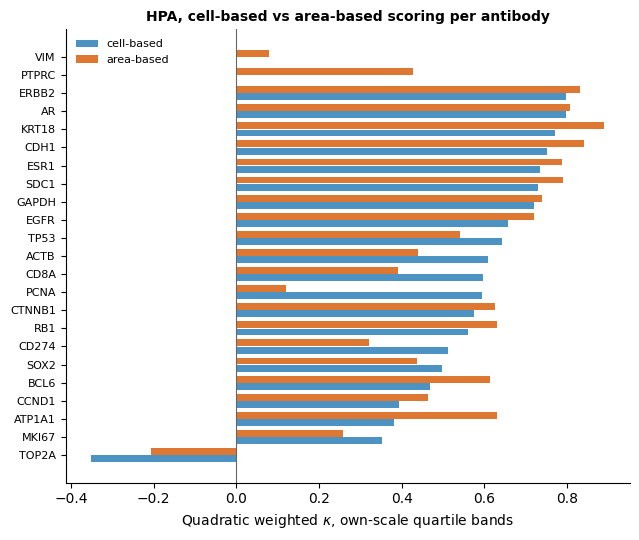


marker  n_cores  rho_area_score  p_rho  rho_meanOD  kappa_area
 KRT18       80           0.920  0.000       0.880       0.890
  CDH1       80           0.859  0.000       0.841       0.840
 ERBB2       80           0.825  0.000       0.815       0.830
    AR       74           0.832  0.000       0.802       0.806
  SDC1       80           0.824  0.000       0.804       0.790
  ESR1       78           0.792  0.000       0.798       0.787
 GAPDH       79           0.756  0.000       0.782       0.739
  EGFR       80           0.719  0.000       0.755       0.720
ATP1A1       80           0.646  0.000       0.586       0.630
   RB1       80           0.672  0.000       0.637       0.630
CTNNB1       78           0.658  0.000       0.674       0.626
  BCL6       80           0.605  0.000       0.596       0.612
  TP53       80           0.557  0.000       0.419       0.540
 CCND1       80           0.447  0.000       0.437       0.464
  ACTB       80           0.484  0.000       0.450    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title HPA area-mode scoring, all antibodies

"""Area-fraction scoring for every antibody in the HPA validation set.

No segmentation is performed. For each core: deconvolve, build a tissue
mask by Otsu on total optical density, classify DAB pixels within tissue
into weak/moderate/strong bands, and report stained area fraction and mean
optical density.

Threshold rule: Otsu on log10 per-pixel DAB optical density (within tissue)
for the negative cut, upper cuts at fixed log10 offsets of 0.398 and 0.699
above it (2.5x and 5x on the linear scale) -- same rule structure as the
cell-based pipeline, refit here on pixel data because per-pixel and
per-cell-mean optical density are different distributions. Thresholds are
estimated once per antibody, from all its cores pooled, and applied
unchanged to every core of that antibody.

Output is directly comparable in shape to sourcedata_hpa_percore.csv
(cell-based), so area_intensity_score and cell_h_score can be compared
per antibody.
"""

import os
import json
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2hed
from skimage.filters import threshold_otsu, gaussian
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score

Image.MAX_IMAGE_PIXELS = None

HPA_DIR = '/content/drive/MyDrive/HPA_calibration'
MANIFEST = f'{HPA_DIR}/hpa_cancer_manifest.csv'
IMAGE_DIR = ('/content/hpa_images' if os.path.isdir('/content/hpa_images')
             else f'{HPA_DIR}/images')
OUT_DIR = f'{HPA_DIR}/validation_frozen'
os.makedirs(OUT_DIR, exist_ok=True)

RESULTS_CSV = f'{OUT_DIR}/area_mode_percore.csv'
CHECKPOINT_EVERY = 50

TISSUE_OFFSET = 1.0     # multiplies the Otsu tissue/glass threshold
SIGMA = 3.0             # Gaussian smoothing before classification only
UPPER_LOG_OFFSETS = (0.398, 0.699)
EPS = 1e-5

LEVELS = ['Negative', 'Weak', 'Moderate', 'Strong']
LMAP = {v: i for i, v in enumerate(LEVELS)}

man = pd.read_csv(MANIFEST)
man = man[man.local_file.astype(str).str.len() > 0].reset_index(drop=True)
man = man[man.intensity.astype(str).isin(LEVELS)]
print(f'{len(man)} cores across {man.gene.nunique()} antibodies')


def total_od(rgb):
    x = rgb.astype(np.float32) + 1.0
    return float(np.log10(256.0)) - np.log10(x).mean(axis=2)


def tissue_mask(rgb, offset=1.0):
    od = total_od(rgb)
    t = float(threshold_otsu(od)) * float(offset)
    return od >= t


def to_z(x):
    return np.log10(np.clip(np.asarray(x, float), EPS, None))


def process_core(path):
    """Returns (mean_od_tissue, tissue_px, smoothed_dab_in_tissue,
    raw_dab_in_tissue) or None on failure."""
    try:
        rgb = np.asarray(Image.open(path).convert('RGB'))
    except Exception:
        return None
    tmask = tissue_mask(rgb, TISSUE_OFFSET)
    if tmask.sum() < 500:
        return None
    dab = rgb2hed(rgb)[:, :, 2].astype(np.float32)
    dab_s = (gaussian(dab, sigma=SIGMA, preserve_range=True).astype(np.float32)
             if SIGMA > 0 else dab)
    raw_in_tissue = dab[tmask]
    smooth_in_tissue = dab_s[tmask]
    return (float(raw_in_tissue.mean()), int(tmask.sum()),
            smooth_in_tissue, raw_in_tissue)


# ── resume support ──
done = set()
if os.path.exists(RESULTS_CSV):
    done = set(pd.read_csv(RESULTS_CSV, usecols=['local_file']).local_file)
todo = man[~man.local_file.isin(done)].reset_index(drop=True)
print(f'{len(done)} cached, {len(todo)} to process')

buf = []
t0 = time.time()
for i, row in todo.iterrows():
    path = os.path.join(IMAGE_DIR, row.local_file)
    out = process_core(path)
    if out is not None:
        mean_od, tissue_px, smooth_vals, raw_vals = out
        buf.append({
            'local_file': row.local_file, 'gene': row.gene,
            'cancer_type': row.cancer_type, 'intensity': row.intensity,
            'quantity': row.quantity, 'mean_od_tissue': mean_od,
            'tissue_px': tissue_px,
            'smooth_vals': smooth_vals.astype(np.float32),
            'raw_vals': raw_vals.astype(np.float32)})
    if (i + 1) % CHECKPOINT_EVERY == 0 or i == len(todo) - 1:
        if buf:
            # store distributions as compact percentile summaries plus
            # raw arrays are not persisted to CSV; threshold fitting and
            # scoring both happen in-memory below, in one pass
            pass
        el = time.time() - t0
        print(f'  [{i+1}/{len(todo)}]  {el/(i+1):.2f} s/core  '
              f'eta {(len(todo)-i-1)*el/(i+1)/60:.1f} min')

print(f'\n{len(buf)} cores processed with usable tissue')

# ── fit thresholds per antibody on pooled pixel data, then score ──
rows = []
by_gene = {}
for rec in buf:
    by_gene.setdefault(rec['gene'], []).append(rec)

for gene, recs in by_gene.items():
    pooled = np.concatenate([r['smooth_vals'] for r in recs])
    pooled = pooled[np.isfinite(pooled) & (pooled > 0)]
    if len(pooled) < 1000:
        continue
    z1 = float(threshold_otsu(to_z(pooled)))
    t1 = 10 ** z1
    t2 = 10 ** (z1 + UPPER_LOG_OFFSETS[0])
    t3 = 10 ** (z1 + UPPER_LOG_OFFSETS[1])
    cuts = sorted([t1, t2, t3])

    for r in recs:
        sm = r['smooth_vals']
        rw = r['raw_vals']
        band = np.searchsorted(cuts, sm, side='left')
        n = len(sm)
        pct = {b: 100 * (band == b).sum() / n for b in range(4)}
        stained = n - (band == 0).sum()
        mean_stained = rw[band > 0].mean() if stained > 0 else np.nan
        rows.append({
            'marker': gene, 'core': r['local_file'],
            'cancer_type': r['cancer_type'], 'intensity': r['intensity'],
            'quantity': r['quantity'], 'truth_num': LMAP[r['intensity']],
            'tissue_px': r['tissue_px'],
            'stained_area_fraction': stained / n,
            'mean_OD': r['mean_od_tissue'],
            'mean_OD_stained': (float(mean_stained)
                               if np.isfinite(mean_stained) else None),
            'pct_negative': pct[0], 'pct_weak': pct[1],
            'pct_moderate': pct[2], 'pct_strong': pct[3],
            'area_intensity_score': pct[1] + 2 * pct[2] + 3 * pct[3],
            't1': t1, 't2': t2, 't3': t3})

area_pc = pd.DataFrame(rows)
area_pc.to_csv(f'{OUT_DIR}/sourcedata_hpa_area_percore.csv', index=False)
print(f'\n{len(area_pc)} scored cores written')

# ── per-antibody agreement, area mode ──
summary_rows = []
for marker, grp in area_pc.groupby('marker'):
    if grp.truth_num.nunique() < 2 or len(grp) < 20:
        continue
    rho, p = spearmanr(grp.area_intensity_score, grp.truth_num)
    rho_od, _ = spearmanr(grp.mean_OD, grp.truth_num)
    q = grp.area_intensity_score.quantile([.25, .5, .75]).values
    band = np.digitize(grp.area_intensity_score, q)
    kappa = cohen_kappa_score(band, grp.truth_num, weights='quadratic')
    summary_rows.append({'marker': marker, 'n_cores': len(grp),
                         'rho_area_score': rho, 'p_rho': p,
                         'rho_meanOD': rho_od, 'kappa_area': kappa})
area_summary = pd.DataFrame(summary_rows).sort_values('kappa_area',
                                                      ascending=False)
area_summary.to_csv(f'{OUT_DIR}/sourcedata_hpa_area_summary.csv',
                    index=False)

# ── side-by-side with cell-based results, if available ──
cell_path = f'{OUT_DIR}/sourcedata_hpa_kappa_ranked.csv'
if os.path.exists(cell_path):
    cell_summary = pd.read_csv(cell_path)[['marker', 'kappa']].rename(
        columns={'kappa': 'kappa_cell'})
    compare = area_summary.merge(cell_summary, on='marker', how='outer')
    compare['better_mode'] = np.where(
        compare.kappa_area > compare.kappa_cell, 'area',
        np.where(compare.kappa_cell > compare.kappa_area, 'cell', 'tie'))
    compare = compare.sort_values('kappa_cell', ascending=True)
    compare.to_csv(f'{OUT_DIR}/sourcedata_area_vs_cell.csv', index=False)
    print()
    print(compare.round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    y = np.arange(len(compare))
    ax.barh(y - 0.2, compare.kappa_cell, height=0.38, label='cell-based',
           color='#2c7fb8', alpha=0.85)
    ax.barh(y + 0.2, compare.kappa_area, height=0.38, label='area-based',
           color='#d95f0e', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(compare.marker, fontsize=8)
    ax.axvline(0, color='#666', lw=0.8)
    ax.set_xlabel(r'Quadratic weighted $\kappa$, own-scale quartile bands')
    ax.legend(fontsize=8, frameon=False)
    ax.set_title('HPA, cell-based vs area-based scoring per antibody',
                fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/M_area_vs_cell_kappa.tiff', dpi=600,
               bbox_inches='tight', facecolor='white',
               pil_kwargs={'compression': 'tiff_lzw'})
    plt.savefig(f'{OUT_DIR}/M_area_vs_cell_kappa.svg', bbox_inches='tight',
               facecolor='white')
    plt.show()
else:
    print('\ncell-based kappa table not found; skipping comparison figure')

print()
print(area_summary.round(3).to_string(index=False))

zip_path = f'{HPA_DIR}/HPA_area_mode_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for name in ['sourcedata_hpa_area_percore.csv',
                'sourcedata_hpa_area_summary.csv',
                'sourcedata_area_vs_cell.csv',
                'M_area_vs_cell_kappa.tiff', 'M_area_vs_cell_kappa.svg']:
        p = f'{OUT_DIR}/{name}'
        if os.path.exists(p):
            archive.write(p, name)
print(f'\n{zip_path}')

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    pass

In [ ]:
# @title Regenerate nuclear + perinuclear figures with fixed data (area untouched)

"""
Rebuilds 1_confusion_<marker> and 2_representative_<marker> for nuclear and
perinuclear ring modes only, using nuclear_pc/ring_pc computed with the
corrected cellwise_to_percore (quantity removed from the groupby key, so
Negative-labeled cores are no longer silently dropped).

Area mode figures in figures_area/ are unaffected and left as-is.

Overwrites files in figures_nuclear/ and figures_perinuclear/ from the
earlier, buggy run.
"""

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import cohen_kappa_score, confusion_matrix

Image.MAX_IMAGE_PIXELS = None

HPA_DIR = '/content/drive/MyDrive/HPA_calibration'
OUT_DIR = f'{HPA_DIR}/validation_frozen'
IMAGE_DIR = ('/content/hpa_images' if os.path.isdir('/content/hpa_images')
             else f'{HPA_DIR}/images')

DISPLAY_MAX_PX = 900
MIN_CELLS_FOR_REP = 300
DPI = 600
FORMATS = ['tiff', 'svg']
DOWNLOAD = True

LEVELS = ['Negative', 'Weak', 'Moderate', 'Strong']
LMAP = {v: i for i, v in enumerate(LEVELS)}
LCOL = {'Negative': '#95a5a6', 'Weak': '#3498db',
        'Moderate': '#e67e22', 'Strong': '#c0392b'}


def whole_core_display(path):
    im = Image.open(path).convert('RGB')
    w, h = im.size
    s = max(1, int(np.ceil(max(w, h) / DISPLAY_MAX_PX)))
    if s > 1:
        im = im.resize((w // s, h // s), Image.LANCZOS)
    return np.asarray(im)


def make_confusion(grp, score_col, title, out_dir, stem):
    q = grp[score_col].quantile([.25, .5, .75]).values
    band = np.digitize(grp[score_col], q)
    kappa = cohen_kappa_score(band, grp.truth_num, weights='quadratic')
    cm = confusion_matrix(grp.truth_num, band, labels=[0, 1, 2, 3])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    fig, ax = plt.subplots(figsize=(4.6, 4.2), facecolor='white')
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                    fontsize=9, color='white' if norm[i, j] > 0.55
                    else 'black')
    ax.set_xticks(range(4)); ax.set_xticklabels(LEVELS, rotation=25, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(LEVELS)
    ax.set_xlabel(f'Predicted band  (cuts: {q[0]:.2f}, {q[1]:.2f}, '
                  f'{q[2]:.2f})', fontsize=8)
    ax.set_ylabel('Pathologist intensity')
    ax.set_title(f'{title}\nn = {len(grp)} cores, $\\kappa_w$ = {kappa:.3f}',
                fontsize=11, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('row fraction', fontsize=7)
    plt.tight_layout()

    written = []
    for ext in FORMATS:
        p = os.path.join(out_dir, f'{stem}.{ext}')
        if ext == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white',
                       pil_kwargs={'compression': 'tiff_lzw'})
        written.append(p)
    plt.close(fig)
    return kappa, cm, written


def make_representative(grp, score_col, core_col, cell_col, title, out_dir,
                        stem, min_cells=None):
    level_medians = grp.groupby('intensity')[score_col].median()
    reps = {}
    for level in LEVELS:
        sub = grp[grp.intensity == level]
        if min_cells is not None and cell_col in sub.columns:
            restricted = sub[sub[cell_col] >= min_cells]
            if len(restricted):
                sub = restricted
        if len(sub) == 0:
            continue
        target = level_medians[level]
        sub = sub.assign(_dist=(sub[score_col] - target).abs())
        reps[level] = sub.sort_values('_dist').iloc[0]

    if not reps:
        return None, []

    fig, axes = plt.subplots(1, len(LEVELS), figsize=(4.0 * len(LEVELS), 4.4),
                             facecolor='white')
    if len(LEVELS) == 1:
        axes = [axes]
    selection_rows = []
    for ax, level in zip(axes, LEVELS):
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(LCOL[level])
            spine.set_linewidth(2.5)
        if level not in reps:
            ax.text(0.5, 0.5, 'no core\navailable', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#888')
            ax.set_title(level, fontsize=10, fontweight='bold',
                        color=LCOL[level])
            continue
        row = reps[level]
        img_path = os.path.join(IMAGE_DIR, row[core_col])
        if os.path.exists(img_path):
            try:
                disp = whole_core_display(img_path)
                ax.imshow(disp)
            except Exception:
                ax.text(0.5, 0.5, 'load\nerror', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='#c0392b')
        else:
            ax.text(0.5, 0.5, 'image\nmissing', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#c0392b')
        cell_note = (f", n = {int(row[cell_col])} cells"
                    if cell_col in row and pd.notna(row.get(cell_col))
                    else '')
        ax.set_title(f'{level}\nscore {row[score_col]:.0f} '
                    f'(level median {level_medians[level]:.0f})'
                    f'{cell_note}',
                    fontsize=8.5, fontweight='bold', color=LCOL[level])
        selection_rows.append({
            'level': level, 'selected_core': row[core_col],
            'selected_score': row[score_col],
            'level_median_score': level_medians[level],
            'distance_from_median': row['_dist']})
    fig.suptitle(title, fontsize=11, fontweight='bold', y=1.04)
    plt.tight_layout()

    written = []
    for ext in FORMATS:
        p = os.path.join(out_dir, f'{stem}.{ext}')
        if ext == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white',
                       pil_kwargs={'compression': 'tiff_lzw'})
        written.append(p)
    plt.close(fig)
    return selection_rows, written


def run_mode(mode_name, out_subdir, df, score_col, core_col, cell_col,
            min_cells):
    out_dir = os.path.join(OUT_DIR, out_subdir)
    os.makedirs(out_dir, exist_ok=True)
    all_written = []
    kappa_rows = []
    sel_rows_all = []

    for marker in sorted(df.marker.unique()):
        grp = df[df.marker == marker]
        if grp.truth_num.nunique() < 2 or len(grp) < 20:
            continue

        kappa, cm, w1 = make_confusion(
            grp, score_col, f'{marker}, {mode_name} (fixed)', out_dir,
            f'1_confusion_{marker}')
        all_written += w1
        kappa_rows.append({'marker': marker, 'mode': mode_name,
                           'n_cores': len(grp), 'kappa': kappa,
                           'n_negative': int((grp.intensity=='Negative').sum())})

        sel, w2 = make_representative(
            grp, score_col, core_col, cell_col,
            f'{marker}, {mode_name}, representative cores', out_dir,
            f'2_representative_{marker}', min_cells=min_cells)
        all_written += w2
        if sel:
            for r in sel:
                r['marker'] = marker
                r['mode'] = mode_name
            sel_rows_all += sel

    kappa_df = pd.DataFrame(kappa_rows).sort_values('kappa', ascending=False)
    kappa_df.to_csv(os.path.join(out_dir, f'kappa_{mode_name}_fixed.csv'),
                    index=False)
    sel_df = pd.DataFrame(sel_rows_all)
    sel_df.to_csv(os.path.join(out_dir,
                              f'representative_selection_{mode_name}_fixed.csv'),
                 index=False)
    all_written += [os.path.join(out_dir, f'kappa_{mode_name}_fixed.csv'),
                    os.path.join(out_dir,
                                f'representative_selection_{mode_name}_fixed.csv')]

    print(f'\n=== {mode_name} (fixed) ===')
    print(kappa_df.round(3).to_string(index=False))
    print(f'{len(all_written)} files written to {out_dir}')
    return all_written, kappa_df


# nuclear_pc and ring_pc must already exist in memory from the fix cell
nuclear_written, nuclear_kappa_final = run_mode(
    'nuclear', 'figures_nuclear', nuclear_pc, 'H_score', 'core', 'n_cells',
    MIN_CELLS_FOR_REP)

ring_written, ring_kappa_final = run_mode(
    'perinuclear_ring', 'figures_perinuclear', ring_pc, 'H_score', 'core',
    'n_cells', MIN_CELLS_FOR_REP)

zip_path = f'{HPA_DIR}/HPA_nuclear_ring_figures_FIXED.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for mode_dir, files in [('figures_nuclear', nuclear_written),
                            ('figures_perinuclear', ring_written)]:
        for p in files:
            archive.write(p, os.path.join(mode_dir, os.path.basename(p)))
print(f'\n{zip_path}  {os.path.getsize(zip_path)/1e6:.1f} MB')

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    pass


=== nuclear (fixed) ===
marker    mode  n_cores  kappa  n_negative
 ERBB2 nuclear       80  0.850          20
    AR nuclear       74  0.838          20
 KRT18 nuclear       80  0.830          20
 PTPRC nuclear       78  0.812          25
  SDC1 nuclear       80  0.770          20
  CDH1 nuclear       78  0.751          19
  ESR1 nuclear       78  0.736          20
  EGFR nuclear       80  0.730          20
 GAPDH nuclear       79  0.729          20
  TP53 nuclear       80  0.650          20
  SOX2 nuclear       78  0.628          20
  PCNA nuclear       80  0.580          20
CTNNB1 nuclear       78  0.574          20
   RB1 nuclear       80  0.560          20
  ACTB nuclear       79  0.509          20
  BCL6 nuclear       80  0.480          21
  CD8A nuclear       68  0.439          22
ATP1A1 nuclear       80  0.420          20
 CCND1 nuclear       80  0.393          18
 MKI67 nuclear       76  0.371          20
 CD274 nuclear       78  0.313          20
   VIM nuclear       65  0.30

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Final per-antibody figures — one confusion matrix + one representative-core panel each, per the pre-specified mode assignment

"""
Produces exactly ONE confusion matrix and ONE representative-core figure per
antibody, using the mode assigned by the pre-specified rule below (annotated
biological compartment first, area as a stated fallback only where the
annotated-compartment mode falls below a minimum kappa bar and area is a
genuine improvement; nuclear kept for MKI67 despite a marginal kappa because
none of the three modes clear the bar and area is worse; VIM and CD274 kept
at their annotated compartment for the same reason).

TOP2A is excluded from this set and given a separate three-mode comparison
figure, since it fails (kappa < 0) in all three modes and is reported as an
unresolved case rather than assigned a mode.

Requires nuclear_pc, ring_pc (fixed, from the corrected cellwise_to_percore)
and area_pc already in memory or reloadable from their saved CSVs.

Output: validation_frozen/figures_final/
  1_confusion_<marker>.tiff/.svg
  2_representative_<marker>.tiff/.svg
  3_TOP2A_all_modes.tiff/.svg      (special case)
  mode_assignment_used.csv          (the rule, stated, for the methods section)
"""

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import cohen_kappa_score, confusion_matrix

Image.MAX_IMAGE_PIXELS = None

HPA_DIR = '/content/drive/MyDrive/HPA_calibration'
OUT_DIR = f'{HPA_DIR}/validation_frozen'
FIG_DIR = f'{OUT_DIR}/figures_final'
IMAGE_DIR = ('/content/hpa_images' if os.path.isdir('/content/hpa_images')
             else f'{HPA_DIR}/images')
os.makedirs(FIG_DIR, exist_ok=True)

DISPLAY_MAX_PX = 900
MIN_CELLS_FOR_REP = 300
DPI = 600
FORMATS = ['tiff', 'svg']
DOWNLOAD = True

LEVELS = ['Negative', 'Weak', 'Moderate', 'Strong']
LMAP = {v: i for i, v in enumerate(LEVELS)}
LCOL = {'Negative': '#95a5a6', 'Weak': '#3498db',
        'Moderate': '#e67e22', 'Strong': '#c0392b'}

# ── pre-specified assignment, with the reasoning kept alongside for export ──
FINAL_MODE_ASSIGNMENT = {
    'ERBB2': ('perinuclear_ring', 'annotated membranous, clears bar'),
    'AR':    ('nuclear',          'annotated nuclear, clears bar'),
    'KRT18': ('perinuclear_ring', 'annotated cytoplasmic, clears bar'),
    'PTPRC': ('perinuclear_ring', 'annotated membranous, clears bar, best overall'),
    'SDC1':  ('perinuclear_ring', 'annotated membranous, clears bar'),
    'CDH1':  ('perinuclear_ring', 'annotated membranous, clears bar'),
    'ESR1':  ('nuclear',          'annotated nuclear, clears bar'),
    'EGFR':  ('perinuclear_ring', 'annotated membranous, clears bar'),
    'GAPDH': ('perinuclear_ring', 'annotated cytoplasmic, clears bar'),
    'TP53':  ('nuclear',          'annotated nuclear, clears bar'),
    'SOX2':  ('nuclear',          'annotated nuclear, clears bar'),
    'PCNA':  ('nuclear',          'annotated nuclear, clears bar'),
    'CTNNB1':('perinuclear_ring', 'annotated membranous, clears bar'),
    'RB1':   ('nuclear',          'annotated nuclear, clears bar'),
    'ACTB':  ('perinuclear_ring', 'annotated cytoplasmic, clears bar'),
    'BCL6':  ('nuclear',          'annotated nuclear, clears bar'),
    'CD8A':  ('perinuclear_ring', 'annotated membranous, clears bar'),
    'ATP1A1':('area',             'annotated mode below 0.40 bar, area is a real improvement'),
    'CCND1': ('area',             'annotated mode below 0.40 bar, area is a real improvement'),
    'CD274': ('perinuclear_ring', 'annotated mode below bar but area gain marginal (<0.06); kept annotated'),
    'MKI67': ('nuclear',          'below bar in all modes; nuclear best of three, area worse; kept annotated'),
    'VIM':   ('perinuclear_ring', 'below bar in all modes; likely stromal contamination in Negative cores (see limitations); kept annotated'),
    # TOP2A intentionally absent -> handled as a separate failure case
}

SCORE_COL = {'nuclear': 'H_score', 'perinuclear_ring': 'H_score',
            'area': 'area_intensity_score'}
CORE_COL = {'nuclear': 'core', 'perinuclear_ring': 'core', 'area': 'core'}
CELL_COL = {'nuclear': 'n_cells', 'perinuclear_ring': 'n_cells',
           'area': 'tissue_px'}
MIN_CELLS = {'nuclear': MIN_CELLS_FOR_REP, 'perinuclear_ring': MIN_CELLS_FOR_REP,
            'area': None}

DATA = {'nuclear': nuclear_pc, 'perinuclear_ring': ring_pc, 'area': area_pc}


def whole_core_display(path):
    im = Image.open(path).convert('RGB')
    w, h = im.size
    s = max(1, int(np.ceil(max(w, h) / DISPLAY_MAX_PX)))
    if s > 1:
        im = im.resize((w // s, h // s), Image.LANCZOS)
    return np.asarray(im)


def make_confusion(grp, score_col, title, stem):
    q = grp[score_col].quantile([.25, .5, .75]).values
    band = np.digitize(grp[score_col], q)
    kappa = cohen_kappa_score(band, grp.truth_num, weights='quadratic')
    cm = confusion_matrix(grp.truth_num, band, labels=[0, 1, 2, 3])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    fig, ax = plt.subplots(figsize=(4.6, 4.2), facecolor='white')
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                    fontsize=9, color='white' if norm[i, j] > 0.55
                    else 'black')
    ax.set_xticks(range(4)); ax.set_xticklabels(LEVELS, rotation=25, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(LEVELS)
    ax.set_xlabel(f'Predicted band  (cuts: {q[0]:.2f}, {q[1]:.2f}, '
                  f'{q[2]:.2f})', fontsize=8)
    ax.set_ylabel('Pathologist intensity')
    ax.set_title(f'{title}\nn = {len(grp)} cores, $\\kappa_w$ = {kappa:.3f}',
                fontsize=11, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('row fraction', fontsize=7)
    plt.tight_layout()

    written = []
    for ext in FORMATS:
        p = os.path.join(FIG_DIR, f'{stem}.{ext}')
        if ext == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white',
                       pil_kwargs={'compression': 'tiff_lzw'})
        written.append(p)
    plt.close(fig)
    return kappa, written


def make_representative(grp, score_col, core_col, cell_col, title, stem,
                        min_cells=None):
    level_medians = grp.groupby('intensity')[score_col].median()
    reps = {}
    for level in LEVELS:
        sub = grp[grp.intensity == level]
        if min_cells is not None and cell_col in sub.columns:
            restricted = sub[sub[cell_col] >= min_cells]
            if len(restricted):
                sub = restricted
        if len(sub) == 0:
            continue
        target = level_medians[level]
        sub = sub.assign(_dist=(sub[score_col] - target).abs())
        reps[level] = sub.sort_values('_dist').iloc[0]

    if not reps:
        return []

    fig, axes = plt.subplots(1, len(LEVELS), figsize=(4.0 * len(LEVELS), 4.4),
                             facecolor='white')
    if len(LEVELS) == 1:
        axes = [axes]
    for ax, level in zip(axes, LEVELS):
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(LCOL[level])
            spine.set_linewidth(2.5)
        if level not in reps:
            ax.text(0.5, 0.5, 'no core\navailable', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#888')
            ax.set_title(level, fontsize=10, fontweight='bold',
                        color=LCOL[level])
            continue
        row = reps[level]
        img_path = os.path.join(IMAGE_DIR, row[core_col])
        if os.path.exists(img_path):
            try:
                ax.imshow(whole_core_display(img_path))
            except Exception:
                ax.text(0.5, 0.5, 'load\nerror', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='#c0392b')
        else:
            ax.text(0.5, 0.5, 'image\nmissing', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#c0392b')
        cell_note = (f", n = {int(row[cell_col])}"
                    if cell_col in row and pd.notna(row.get(cell_col))
                    else '')
        ax.set_title(f'{level}\nscore {row[score_col]:.0f} '
                    f'(median {level_medians[level]:.0f}){cell_note}',
                    fontsize=8.5, fontweight='bold', color=LCOL[level])
    fig.suptitle(title, fontsize=11, fontweight='bold', y=1.04)
    plt.tight_layout()

    written = []
    for ext in FORMATS:
        p = os.path.join(FIG_DIR, f'{stem}.{ext}')
        if ext == 'svg':
            fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
        else:
            fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white',
                       pil_kwargs={'compression': 'tiff_lzw'})
        written.append(p)
    plt.close(fig)
    return written


# ══════════════════════════════════════════════════════════════
# MAIN LOOP: one antibody, one assigned mode, one pair of figures
# ══════════════════════════════════════════════════════════════
all_written = []
assignment_log = []

for marker, (mode, reason) in FINAL_MODE_ASSIGNMENT.items():
    df = DATA[mode]
    grp = df[df.marker == marker]
    if grp.truth_num.nunique() < 2 or len(grp) < 20:
        print(f'{marker}: insufficient data in assigned mode {mode}, skipped')
        continue

    score_col = SCORE_COL[mode]
    kappa, w1 = make_confusion(
        grp, score_col, f'{marker}  ({mode.replace("_"," ")})',
        f'1_confusion_{marker}')
    all_written += w1

    w2 = make_representative(
        grp, score_col, CORE_COL[mode], CELL_COL[mode],
        f'{marker}, representative cores ({mode.replace("_"," ")})',
        f'2_representative_{marker}', min_cells=MIN_CELLS[mode])
    all_written += w2

    assignment_log.append({'marker': marker, 'assigned_mode': mode,
                           'kappa': kappa, 'reason': reason,
                           'n_cores': len(grp)})
    print(f'{marker:<8} -> {mode:<16}  kappa={kappa:.3f}   {reason}')

assignment_df = pd.DataFrame(assignment_log).sort_values('kappa',
                                                         ascending=False)
assignment_df.to_csv(os.path.join(FIG_DIR, 'mode_assignment_used.csv'),
                    index=False)
all_written.append(os.path.join(FIG_DIR, 'mode_assignment_used.csv'))

print('\n' + assignment_df.round(3).to_string(index=False))

# ══════════════════════════════════════════════════════════════
# TOP2A — separate three-mode comparison, reported as an unresolved failure
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), facecolor='white')
for ax, mode in zip(axes, ['nuclear', 'perinuclear_ring', 'area']):
    df = DATA[mode]
    grp = df[df.marker == 'TOP2A']
    score_col = SCORE_COL[mode]
    q = grp[score_col].quantile([.25, .5, .75]).values
    band = np.digitize(grp[score_col], q)
    kappa = cohen_kappa_score(band, grp.truth_num, weights='quadratic')
    cm = confusion_matrix(grp.truth_num, band, labels=[0, 1, 2, 3])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    im = ax.imshow(norm, cmap='Reds', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=8,
                    color='white' if norm[i, j] > 0.55 else 'black')
    ax.set_xticks(range(4)); ax.set_xticklabels(LEVELS, rotation=25, ha='right',
                                                fontsize=7)
    ax.set_yticks(range(4)); ax.set_yticklabels(LEVELS, fontsize=7)
    ax.set_title(f'{mode.replace("_"," ")}\n$\\kappa_w$={kappa:.3f}',
                fontsize=9, fontweight='bold')
fig.suptitle('TOP2A, inverted agreement in all three modes\n'
             '(unresolved; not assigned a mode, reported as a limitation)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
for ext in FORMATS:
    p = os.path.join(FIG_DIR, f'3_TOP2A_all_modes.{ext}')
    if ext == 'svg':
        fig.savefig(p, format='svg', bbox_inches='tight', facecolor='white')
    else:
        fig.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white',
                   pil_kwargs={'compression': 'tiff_lzw'})
    all_written.append(p)
plt.close(fig)

print(f'\n{len(all_written)} files written to {FIG_DIR}')

zip_path = f'{HPA_DIR}/HPA_final_per_antibody_figures.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for p in all_written:
        archive.write(p, os.path.basename(p))
print(f'{zip_path}  {os.path.getsize(zip_path)/1e6:.1f} MB')

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    pass

ERBB2    -> perinuclear_ring  kappa=0.800   annotated membranous, clears bar
AR       -> nuclear           kappa=0.838   annotated nuclear, clears bar
KRT18    -> perinuclear_ring  kappa=0.770   annotated cytoplasmic, clears bar
PTPRC    -> perinuclear_ring  kappa=0.822   annotated membranous, clears bar, best overall
SDC1     -> perinuclear_ring  kappa=0.730   annotated membranous, clears bar
CDH1     -> perinuclear_ring  kappa=0.741   annotated membranous, clears bar
ESR1     -> nuclear           kappa=0.736   annotated nuclear, clears bar
EGFR     -> perinuclear_ring  kappa=0.710   annotated membranous, clears bar
GAPDH    -> perinuclear_ring  kappa=0.719   annotated cytoplasmic, clears bar
TP53     -> nuclear           kappa=0.650   annotated nuclear, clears bar
SOX2     -> nuclear           kappa=0.628   annotated nuclear, clears bar
PCNA     -> nuclear           kappa=0.580   annotated nuclear, clears bar
CTNNB1   -> perinuclear_ring  kappa=0.533   annotated membranous, clears ba

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

nuclear: loading /content/drive/MyDrive/HPA_calibration/validation_frozen/sourcedata_hpa_nuclear_percore_fixed.csv
perinuclear_ring: loading /content/drive/MyDrive/HPA_calibration/validation_frozen/sourcedata_hpa_ring_percore_fixed.csv
area: loading /content/drive/MyDrive/HPA_calibration/validation_frozen/sourcedata_hpa_area_percore.csv


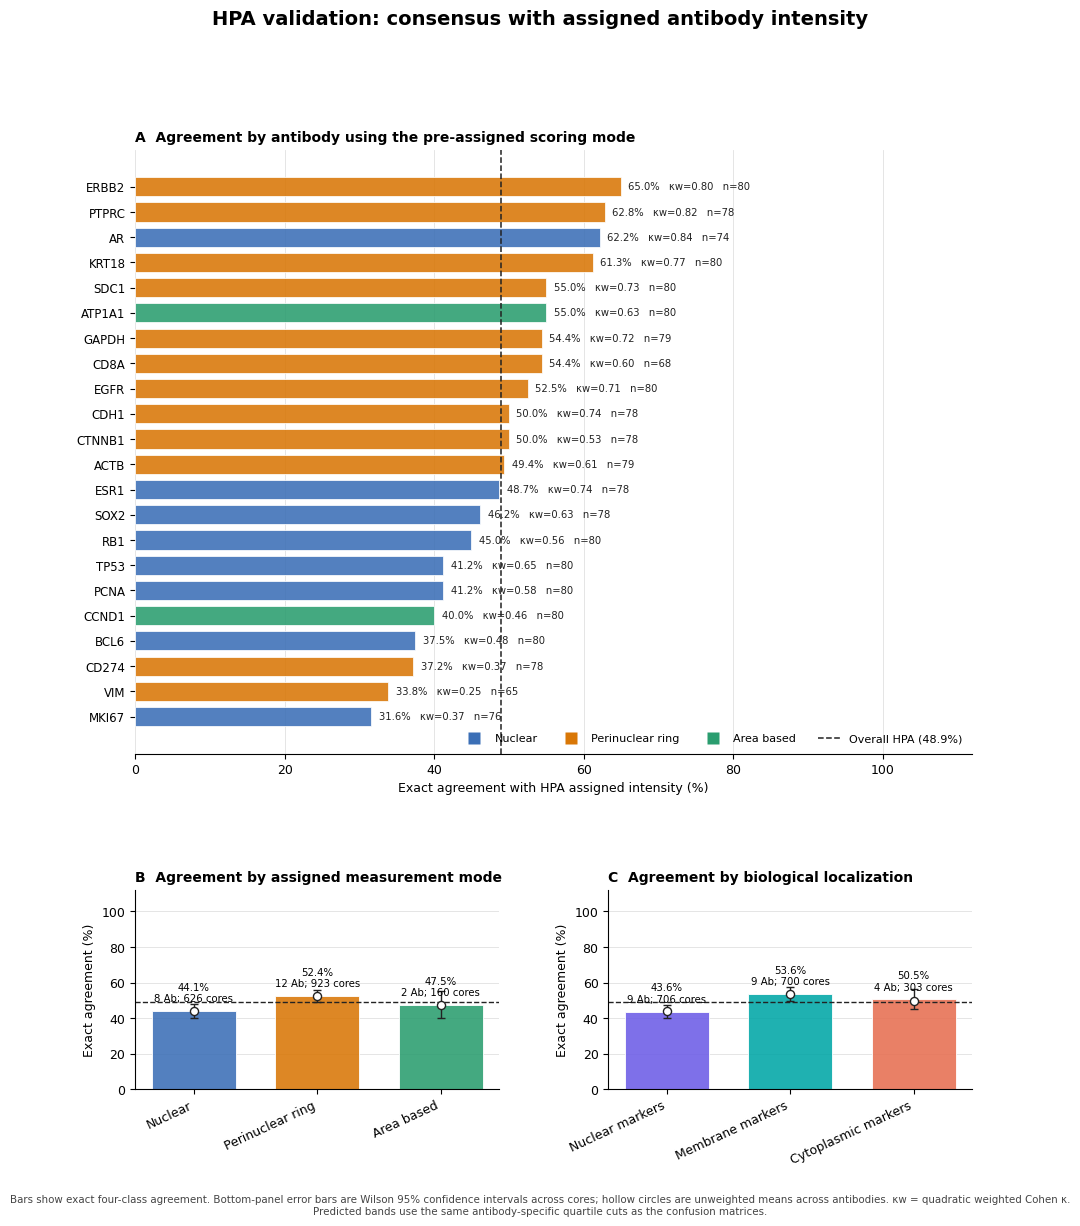

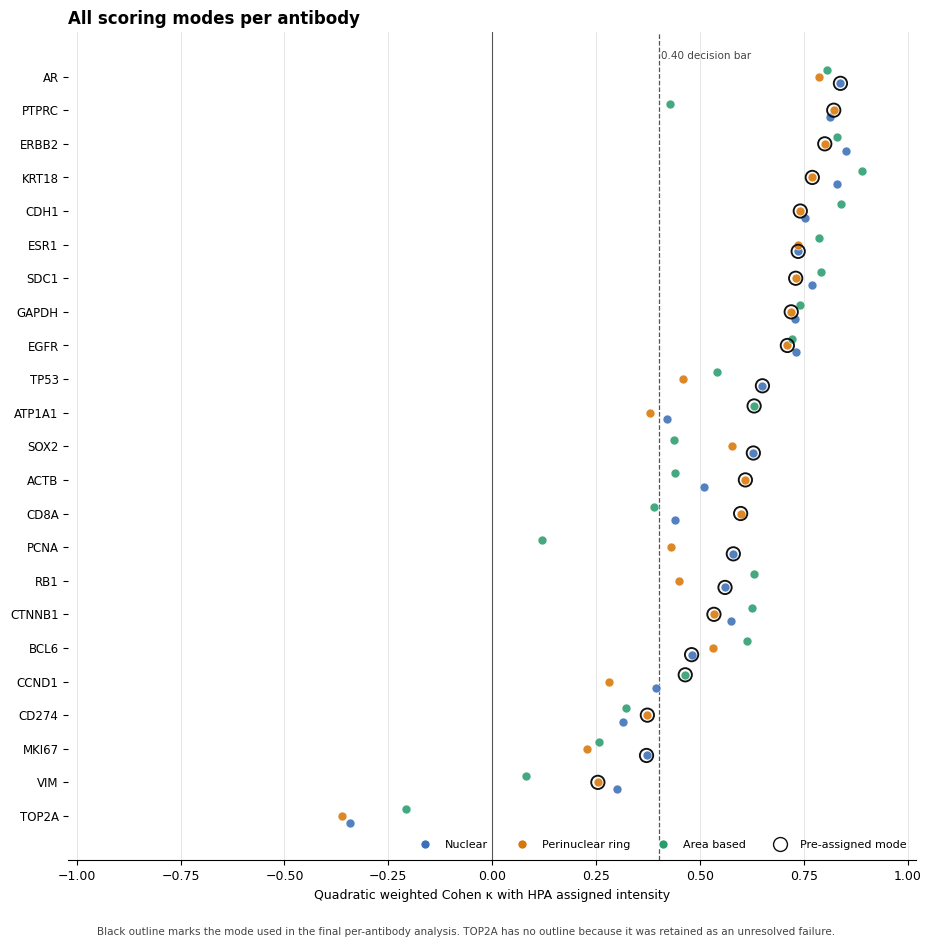


Per-antibody agreement:
marker    assigned_mode biological_localization  n_cores  exact_agreement_pct  within_one_grade_pct  quadratic_weighted_kappa
 ERBB2 perinuclear_ring              membranous       80               65.000                95.000                     0.800
 PTPRC perinuclear_ring              membranous       78               62.821                96.154                     0.822
    AR          nuclear                 nuclear       74               62.162                98.649                     0.838
 KRT18 perinuclear_ring             cytoplasmic       80               61.250                93.750                     0.770
ATP1A1             area              membranous       80               55.000                86.250                     0.630
  SDC1 perinuclear_ring              membranous       80               55.000                92.500                     0.730
 GAPDH perinuclear_ring             cytoplasmic       79               54.430                

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""Colab cell: final HPA agreement summary figure.

Run after the corrected nuclear_pc, ring_pc, area_pc and final mode-assignment
cells. The cell also persists the three per-core tables, so later runs can load
them without recomputing segmentation.

Outputs in /content/drive/MyDrive/HPA_calibration/validation_frozen/figures_final:
  4_HPA_final_agreement_summary.svg
  4_HPA_final_agreement_summary.tiff  (600 dpi, LZW)
  5_HPA_all_mode_comparison.svg
  5_HPA_all_mode_comparison.tiff      (600 dpi, LZW)
  sourcedata_final_agreement_by_antibody.csv
  sourcedata_final_agreement_by_mode.csv
  sourcedata_final_agreement_by_localization.csv
  sourcedata_all_mode_comparison_long.csv
  HPA_final_agreement_summary.zip
"""

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.metrics import cohen_kappa_score


# -----------------------------------------------------------------------------
# Paths and appearance
# -----------------------------------------------------------------------------
HPA_DIR = '/content/drive/MyDrive/HPA_calibration'
OUT_DIR = f'{HPA_DIR}/validation_frozen'
FIG_DIR = f'{OUT_DIR}/figures_final'
os.makedirs(FIG_DIR, exist_ok=True)

ASSIGNMENT_CSV = f'{FIG_DIR}/mode_assignment_used.csv'
MODE_COMPARISON_CSV = f'{OUT_DIR}/mode_comparison_full_FIXED.csv'
PERCORE_PATHS = {
    'nuclear': f'{OUT_DIR}/sourcedata_hpa_nuclear_percore_fixed.csv',
    'perinuclear_ring': f'{OUT_DIR}/sourcedata_hpa_ring_percore_fixed.csv',
    'area': f'{OUT_DIR}/sourcedata_hpa_area_percore.csv',
}
GLOBAL_NAMES = {
    'nuclear': 'nuclear_pc',
    'perinuclear_ring': 'ring_pc',
    'area': 'area_pc',
}
SCORE_COL = {
    'nuclear': 'H_score',
    'perinuclear_ring': 'H_score',
    'area': 'area_intensity_score',
}

DPI = 600
DOWNLOAD = True
LEVELS = ['Negative', 'Weak', 'Moderate', 'Strong']
LMAP = {name: i for i, name in enumerate(LEVELS)}

MODE_LABEL = {
    'nuclear': 'Nuclear',
    'perinuclear_ring': 'Perinuclear ring',
    'area': 'Area based',
}
MODE_COLOR = {
    'nuclear': '#3B6FB6',
    'perinuclear_ring': '#D97706',
    'area': '#2A9D6F',
}
BIO_COLOR = {
    'nuclear': '#6C5CE7',
    'membranous': '#00A6A6',
    'cytoplasmic': '#E76F51',
}

# Biological localization is kept separate from the selected measurement mode.
# TOP2A is absent because the earlier analysis designated it unresolved.
BIOLOGICAL_LOCALIZATION = {
    'MKI67': 'nuclear', 'TP53': 'nuclear', 'ESR1': 'nuclear',
    'AR': 'nuclear', 'CCND1': 'nuclear', 'FOXP3': 'nuclear',
    'PCNA': 'nuclear', 'RB1': 'nuclear', 'SOX2': 'nuclear',
    'BCL6': 'nuclear',
    'ERBB2': 'membranous', 'EGFR': 'membranous', 'CDH1': 'membranous',
    'CD274': 'membranous', 'PTPRC': 'membranous', 'SDC1': 'membranous',
    'ATP1A1': 'membranous', 'CTNNB1': 'membranous', 'CD8A': 'membranous',
    'VIM': 'cytoplasmic', 'ACTB': 'cytoplasmic',
    'GAPDH': 'cytoplasmic', 'KRT18': 'cytoplasmic',
}

matplotlib.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'svg.fonttype': 'none',       # editable text in Illustrator/Inkscape
    'savefig.facecolor': 'white',
})


# -----------------------------------------------------------------------------
# Load the corrected per-core results using the filenames found in the actual
# HPA_calibration CSV inventory. In-memory DataFrames are only fallbacks.
# -----------------------------------------------------------------------------
def load_or_persist_mode(mode):
    global_name = GLOBAL_NAMES[mode]
    path = PERCORE_PATHS[mode]
    if os.path.exists(path):
        print(f'{mode}: loading {path}')
        return pd.read_csv(path)
    obj = globals().get(global_name)
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        print(f'{mode}: fixed CSV absent; using in-memory {global_name}')
        return obj.copy()
    raise FileNotFoundError(
        f'Missing {path}, and in-memory {global_name} is unavailable.'
    )


DATA = {mode: load_or_persist_mode(mode) for mode in PERCORE_PATHS}

if os.path.exists(ASSIGNMENT_CSV):
    assignment = pd.read_csv(ASSIGNMENT_CSV)
elif 'FINAL_MODE_ASSIGNMENT' in globals():
    assignment = pd.DataFrame([
        {'marker': marker, 'assigned_mode': mode, 'reason': reason}
        for marker, (mode, reason) in FINAL_MODE_ASSIGNMENT.items()
    ])
else:
    raise FileNotFoundError(
        f'Missing {ASSIGNMENT_CSV}. Run the final mode-assignment cell first.'
    )

required_assignment = {'marker', 'assigned_mode'}
missing = required_assignment - set(assignment.columns)
if missing:
    raise ValueError(f'{ASSIGNMENT_CSV} is missing columns: {sorted(missing)}')


# -----------------------------------------------------------------------------
# Agreement calculations. Predicted bands use the same per-antibody quartile
# rule as the existing confusion-matrix code, ensuring identical results.
# -----------------------------------------------------------------------------
def clean_group(df, marker, score_col):
    grp = df.loc[df['marker'].astype(str) == str(marker)].copy()
    if 'truth_num' not in grp.columns:
        if 'intensity' not in grp.columns:
            raise ValueError(f'{marker}: neither truth_num nor intensity exists')
        grp['truth_num'] = grp['intensity'].astype(str).map(LMAP)
    grp['truth_num'] = pd.to_numeric(grp['truth_num'], errors='coerce')
    grp[score_col] = pd.to_numeric(grp[score_col], errors='coerce')
    return grp.dropna(subset=['truth_num', score_col]).copy()


rows = []
for rec in assignment.itertuples(index=False):
    marker = str(rec.marker)
    mode = str(rec.assigned_mode)
    if mode not in DATA:
        print(f'{marker}: unknown assigned mode {mode}; skipped')
        continue
    score_col = SCORE_COL[mode]
    if score_col not in DATA[mode].columns:
        raise ValueError(f'{mode} table is missing score column {score_col}')
    grp = clean_group(DATA[mode], marker, score_col)
    if len(grp) == 0 or grp['truth_num'].nunique() < 2:
        print(f'{marker}: insufficient assigned-mode data; skipped')
        continue

    cuts = grp[score_col].quantile([0.25, 0.50, 0.75]).to_numpy(float)
    predicted = np.digitize(grp[score_col].to_numpy(float), cuts)
    truth = grp['truth_num'].to_numpy(int)
    correct = predicted == truth
    adjacent = np.abs(predicted - truth) <= 1
    kappa = cohen_kappa_score(truth, predicted, weights='quadratic')

    rows.append({
        'marker': marker,
        'assigned_mode': mode,
        'mode_label': MODE_LABEL[mode],
        'biological_localization': BIOLOGICAL_LOCALIZATION.get(marker,
                                                                'unclassified'),
        'n_cores': int(len(grp)),
        'n_exact': int(correct.sum()),
        'n_adjacent': int(adjacent.sum()),
        'exact_agreement_pct': 100.0 * correct.mean(),
        'within_one_grade_pct': 100.0 * adjacent.mean(),
        'quadratic_weighted_kappa': float(kappa),
        'q25_score_cut': cuts[0],
        'q50_score_cut': cuts[1],
        'q75_score_cut': cuts[2],
    })

agreement = pd.DataFrame(rows)
if agreement.empty:
    raise RuntimeError('No antibody agreement results could be calculated.')

# Confirm that the recomputed kappa values match the final assignment table.
if 'kappa' in assignment.columns:
    check = agreement.merge(
        assignment[['marker', 'kappa']].rename(columns={'kappa': 'saved_kappa'}),
        on='marker', how='left')
    check['absolute_kappa_difference'] = (
        check.quadratic_weighted_kappa - check.saved_kappa).abs()
    if (check.absolute_kappa_difference > 0.01).any():
        print('\nWARNING: recomputed kappa differs from mode_assignment_used.csv:')
        print(check.loc[check.absolute_kappa_difference > 0.01,
                        ['marker', 'quadratic_weighted_kappa', 'saved_kappa',
                         'absolute_kappa_difference']].to_string(index=False))


def wilson_interval(k, n, z=1.959963984540054):
    """Wilson 95% interval for a binomial proportion; returns percentages."""
    if n <= 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return 100 * (centre - half), 100 * (centre + half)


def group_summary(frame, group_col, order=None):
    records = []
    groups = list(frame.groupby(group_col, sort=False))
    if order is not None:
        rank = {name: i for i, name in enumerate(order)}
        groups.sort(key=lambda item: rank.get(item[0], 999))
    for name, grp in groups:
        n = int(grp.n_cores.sum())
        k = int(grp.n_exact.sum())
        lo, hi = wilson_interval(k, n)
        records.append({
            group_col: name,
            'n_antibodies': int(len(grp)),
            'n_cores': n,
            'n_exact': k,
            'micro_exact_agreement_pct': 100 * k / n,
            'ci95_low': lo,
            'ci95_high': hi,
            'macro_antibody_mean_pct': grp.exact_agreement_pct.mean(),
            'mean_quadratic_weighted_kappa':
                grp.quadratic_weighted_kappa.mean(),
        })
    return pd.DataFrame(records)


mode_summary = group_summary(
    agreement, 'assigned_mode', ['nuclear', 'perinuclear_ring', 'area'])
bio_summary = group_summary(
    agreement[agreement.biological_localization != 'unclassified'],
    'biological_localization', ['nuclear', 'membranous', 'cytoplasmic'])

overall_n = int(agreement.n_cores.sum())
overall_k = int(agreement.n_exact.sum())
overall_lo, overall_hi = wilson_interval(overall_k, overall_n)
overall_pct = 100 * overall_k / overall_n

agreement.to_csv(f'{FIG_DIR}/sourcedata_final_agreement_by_antibody.csv',
                 index=False)
mode_summary.to_csv(f'{FIG_DIR}/sourcedata_final_agreement_by_mode.csv',
                    index=False)
bio_summary.to_csv(f'{FIG_DIR}/sourcedata_final_agreement_by_localization.csv',
                   index=False)


# -----------------------------------------------------------------------------
# Three-panel publication figure
# -----------------------------------------------------------------------------
ranked = agreement.sort_values(
    ['exact_agreement_pct', 'quadratic_weighted_kappa', 'marker'],
    ascending=[True, True, True]).reset_index(drop=True)

fig = plt.figure(figsize=(10.8, 12.2), facecolor='white')
gs = GridSpec(2, 2, figure=fig, height_ratios=[4.4, 1.45],
              width_ratios=[1, 1], hspace=0.34, wspace=0.30)
ax_rank = fig.add_subplot(gs[0, :])
ax_mode = fig.add_subplot(gs[1, 0])
ax_bio = fig.add_subplot(gs[1, 1])

# A. One ranked horizontal bar per antibody using only its assigned mode.
y = np.arange(len(ranked))
colors = [MODE_COLOR[m] for m in ranked.assigned_mode]
ax_rank.barh(y, ranked.exact_agreement_pct, color=colors, alpha=0.88,
             edgecolor='white', linewidth=0.6, height=0.76)
ax_rank.axvline(overall_pct, color='#222222', linestyle='--', linewidth=1.1,
                label=f'Overall, core weighted ({overall_pct:.1f}%)')
ax_rank.set_yticks(y)
ax_rank.set_yticklabels(ranked.marker, fontsize=8.5)
ax_rank.set_xlim(0, 112)
ax_rank.set_xlabel('Exact agreement with HPA assigned intensity (%)')
ax_rank.set_title('A  Agreement by antibody using the pre-assigned scoring mode',
                  loc='left', fontweight='bold')
ax_rank.grid(axis='x', color='#D9D9D9', linewidth=0.6, alpha=0.8)
ax_rank.set_axisbelow(True)
ax_rank.spines[['top', 'right', 'left']].set_visible(False)
for yi, row in ranked.iterrows():
    ax_rank.text(min(row.exact_agreement_pct + 1.0, 101.0), yi,
                 f'{row.exact_agreement_pct:.1f}%   '
                 f'κw={row.quadratic_weighted_kappa:.2f}   '
                 f'n={int(row.n_cores)}',
                 va='center', ha='left', fontsize=7.2, color='#222222')

handles = [
    Line2D([0], [0], marker='s', linestyle='', markersize=8,
           markerfacecolor=MODE_COLOR[m], markeredgecolor='none',
           label=MODE_LABEL[m])
    for m in ['nuclear', 'perinuclear_ring', 'area']
]
handles.append(Line2D([0], [0], color='#222222', linestyle='--', linewidth=1.1,
                      label=f'Overall HPA ({overall_pct:.1f}%)'))
ax_rank.legend(handles=handles, ncol=4, frameon=False, fontsize=8,
               loc='lower right')


def summary_bars(ax, summary, key, labels, colors, title):
    x = np.arange(len(summary))
    vals = summary.micro_exact_agreement_pct.to_numpy(float)
    lower = vals - summary.ci95_low.to_numpy(float)
    upper = summary.ci95_high.to_numpy(float) - vals
    bars = ax.bar(x, vals, width=0.68, color=[colors[v] for v in summary[key]],
                  alpha=0.88, edgecolor='white', linewidth=0.7)
    ax.errorbar(x, vals, yerr=np.vstack([lower, upper]), fmt='none',
                ecolor='#222222', elinewidth=1, capsize=3, capthick=1)
    # Hollow circle = unweighted mean of antibody percentages.
    ax.scatter(x, summary.macro_antibody_mean_pct, s=34, facecolor='white',
               edgecolor='#222222', linewidth=1.0, zorder=4,
               label='Mean across antibodies')
    for xi, bar, row in zip(x, bars, summary.itertuples(index=False)):
        ax.text(xi, bar.get_height() + 4.0,
                f'{bar.get_height():.1f}%\n'
                f'{int(row.n_antibodies)} Ab; {int(row.n_cores)} cores',
                ha='center', va='bottom', fontsize=7.3)
    ax.axhline(overall_pct, color='#222222', linestyle='--', linewidth=1.0)
    ax.set_ylim(0, 112)
    ax.set_xticks(x)
    # Inclined category labels, as requested.
    ax.set_xticklabels([labels[v] for v in summary[key]], rotation=25,
                       ha='right')
    ax.set_ylabel('Exact agreement (%)')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.grid(axis='y', color='#D9D9D9', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)


summary_bars(ax_mode, mode_summary, 'assigned_mode', MODE_LABEL, MODE_COLOR,
             'B  Agreement by assigned measurement mode')
summary_bars(ax_bio, bio_summary, 'biological_localization',
             {'nuclear': 'Nuclear markers', 'membranous': 'Membrane markers',
              'cytoplasmic': 'Cytoplasmic markers'}, BIO_COLOR,
             'C  Agreement by biological localization')

fig.suptitle('HPA validation: consensus with assigned antibody intensity',
             fontsize=14, fontweight='bold', y=0.995)
fig.text(
    0.5, 0.006,
    'Bars show exact four-class agreement. Bottom-panel error bars are Wilson '
    '95% confidence intervals across cores; hollow circles are unweighted '
    'means across antibodies. κw = quadratic weighted Cohen κ. Predicted bands '
    'use the same antibody-specific quartile cuts as the confusion matrices.',
    ha='center', va='bottom', fontsize=7.4, color='#444444', wrap=True)

svg_path = f'{FIG_DIR}/4_HPA_final_agreement_summary.svg'
tiff_path = f'{FIG_DIR}/4_HPA_final_agreement_summary.tiff'
fig.savefig(svg_path, format='svg', bbox_inches='tight', facecolor='white')
fig.savefig(tiff_path, format='tiff', dpi=DPI, bbox_inches='tight',
            facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()
plt.close(fig)


# -----------------------------------------------------------------------------
# Figure 5: all three modes per antibody. This uses the existing fixed summary
# table, so every dot is the kappa already reported by the pipeline. A black
# ring identifies the pre-assigned mode. TOP2A remains visible but unassigned.
# -----------------------------------------------------------------------------
if not os.path.exists(MODE_COMPARISON_CSV):
    raise FileNotFoundError(MODE_COMPARISON_CSV)

mode_wide = pd.read_csv(MODE_COMPARISON_CSV)
required_mode_cols = {
    'marker', 'kappa_nuclear', 'kappa_perinuclear_ring', 'kappa_area'
}
missing_mode_cols = required_mode_cols - set(mode_wide.columns)
if missing_mode_cols:
    raise ValueError(
        f'{MODE_COMPARISON_CSV} is missing {sorted(missing_mode_cols)}')

mode_long = mode_wide.melt(
    id_vars=['marker'],
    value_vars=['kappa_nuclear', 'kappa_perinuclear_ring', 'kappa_area'],
    var_name='kappa_column', value_name='quadratic_weighted_kappa')
mode_long['mode'] = mode_long.kappa_column.str.replace(
    'kappa_', '', regex=False)
mode_long = mode_long.merge(
    assignment[['marker', 'assigned_mode']], on='marker', how='left')
mode_long['is_assigned_mode'] = (
    mode_long['mode'] == mode_long['assigned_mode'])
mode_long.to_csv(f'{FIG_DIR}/sourcedata_all_mode_comparison_long.csv',
                 index=False)

# Rank by the assigned result where available, otherwise by the best of 3.
assigned_rank = agreement.set_index('marker').quadratic_weighted_kappa
best_rank = mode_wide.set_index('marker')[[
    'kappa_nuclear', 'kappa_perinuclear_ring', 'kappa_area']].max(axis=1)
rank_value = best_rank.copy()
rank_value.update(assigned_rank)
marker_order = rank_value.sort_values(ascending=True).index.tolist()

fig2_height = max(7.2, 0.34 * len(marker_order) + 1.7)
fig2, ax = plt.subplots(figsize=(9.4, fig2_height), facecolor='white')
y_base = np.arange(len(marker_order))
offset = {'nuclear': -0.20, 'perinuclear_ring': 0.0, 'area': 0.20}

for mode in ['nuclear', 'perinuclear_ring', 'area']:
    sub = (mode_long[mode_long['mode'] == mode]
           .set_index('marker').reindex(marker_order))
    y_mode = y_base + offset[mode]
    values = sub.quadratic_weighted_kappa.to_numpy(float)
    ax.scatter(values, y_mode, s=42, color=MODE_COLOR[mode], alpha=0.88,
               edgecolor='white', linewidth=0.5, label=MODE_LABEL[mode],
               zorder=3)
    selected = sub.is_assigned_mode.fillna(False).to_numpy(bool)
    ax.scatter(values[selected], y_mode[selected], s=92, facecolor='none',
               edgecolor='#111111', linewidth=1.35, zorder=4)

ax.axvline(0, color='#555555', linewidth=0.8)
ax.axvline(0.40, color='#555555', linewidth=0.9, linestyle='--')
ax.text(0.405, len(marker_order) - 0.25, '0.40 decision bar', fontsize=7.5,
        va='top', ha='left', color='#444444')
ax.set_yticks(y_base)
ax.set_yticklabels(marker_order, fontsize=8.5)
ax.set_xlim(-1.02, 1.02)
ax.set_xlabel('Quadratic weighted Cohen κ with HPA assigned intensity')
ax.set_title('All scoring modes per antibody', loc='left',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', color='#D9D9D9', linewidth=0.6, alpha=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=7,
           markerfacecolor=MODE_COLOR[m], markeredgecolor='white',
           label=MODE_LABEL[m])
    for m in ['nuclear', 'perinuclear_ring', 'area']
]
legend_handles.append(
    Line2D([0], [0], marker='o', linestyle='', markersize=10,
           markerfacecolor='none', markeredgecolor='#111111',
           label='Pre-assigned mode'))
ax.legend(handles=legend_handles, ncol=4, frameon=False, fontsize=8,
          loc='lower right')
fig2.text(
    0.5, 0.012,
    'Black outline marks the mode used in the final per-antibody analysis. '
    'TOP2A has no outline because it was retained as an unresolved failure.',
    ha='center', va='bottom', fontsize=7.5, color='#444444')
fig2.tight_layout(rect=[0, 0.035, 1, 1])

all_modes_svg = f'{FIG_DIR}/5_HPA_all_mode_comparison.svg'
all_modes_tiff = f'{FIG_DIR}/5_HPA_all_mode_comparison.tiff'
fig2.savefig(all_modes_svg, format='svg', bbox_inches='tight',
             facecolor='white')
fig2.savefig(all_modes_tiff, format='tiff', dpi=DPI, bbox_inches='tight',
             facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()
plt.close(fig2)


# One automatic download is more reliable in Colab than triggering two browser
# downloads; the archive contains both publication files and all source tables.
written = [
    svg_path,
    tiff_path,
    all_modes_svg,
    all_modes_tiff,
    f'{FIG_DIR}/sourcedata_final_agreement_by_antibody.csv',
    f'{FIG_DIR}/sourcedata_final_agreement_by_mode.csv',
    f'{FIG_DIR}/sourcedata_final_agreement_by_localization.csv',
    f'{FIG_DIR}/sourcedata_all_mode_comparison_long.csv',
]
zip_path = f'{FIG_DIR}/HPA_final_agreement_summary.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in written:
        archive.write(path, os.path.basename(path))

print('\nPer-antibody agreement:')
print(agreement[[
    'marker', 'assigned_mode', 'biological_localization', 'n_cores',
    'exact_agreement_pct', 'within_one_grade_pct',
    'quadratic_weighted_kappa'
]].sort_values('exact_agreement_pct', ascending=False).round(3).to_string(
    index=False))
print(f'\nOverall exact agreement: {overall_pct:.1f}% '
      f'(95% CI {overall_lo:.1f}–{overall_hi:.1f}; n={overall_n} cores)')
print(f'Files saved to {FIG_DIR}')
print(zip_path)

if DOWNLOAD:
    try:
        from google.colab import files as colab_files
        colab_files.download(zip_path)
    except ImportError:
        pass


In [ ]:
# Inspect every CSV under HPA_calibration without modifying anything

from pathlib import Path
import os
import pandas as pd

HPA_DIR = Path('/content/drive/MyDrive/HPA_calibration')

if not HPA_DIR.exists():
    raise FileNotFoundError(
        f'{HPA_DIR} is unavailable. Mount Google Drive first.'
    )

important = {
    'marker', 'gene', 'mode', 'assigned_mode', 'compartment',
    'intensity', 'truth_num', 'H_score', 'area_intensity_score',
    'core', 'file', 'local_file', 'n_cells', 'n_cores', 'kappa'
}

csv_paths = sorted(HPA_DIR.rglob('*.csv'))

print(f'Found {len(csv_paths)} CSV files\n')

for path in csv_paths:
    relative = path.relative_to(HPA_DIR)

    try:
        sample = pd.read_csv(path, nrows=5)
        columns = list(sample.columns)
        relevant = [c for c in columns if c in important]

        print('=' * 100)
        print(f'FILE: {relative}')
        print(f'SIZE: {os.path.getsize(path) / 1e6:.2f} MB')
        print(f'COLUMNS ({len(columns)}):')
        print(columns)

        if relevant:
            print('\nRELEVANT SAMPLE:')
            print(sample[relevant].to_string(index=False))
        else:
            print('\nNo expected agreement columns detected.')

    except Exception as error:
        print('=' * 100)
        print(f'FILE: {relative}')
        print(f'ERROR: {error}')

Found 30 CSV files

FILE: hpa_cancer_manifest.csv
SIZE: 0.59 MB
COLUMNS (18):
['gene', 'ensg', 'panel_localization', 'organ', 'cancer_type', 'patient', 'sex', 'age', 'staining', 'intensity', 'quantity', 'ihc_location', 'diagnosis', 'url', 'url_tif', 'local_file', 'loc_core', 'loc_class']

RELEVANT SAMPLE:
 gene intensity                                local_file
CCND1  Negative CCND1_Breast_cancer_1874_172033_A_5_5.jpg
CCND1  Moderate CCND1_Breast_cancer_1910_172033_A_4_1.jpg
CCND1      Weak CCND1_Breast_cancer_2420_172033_A_4_3.jpg
CCND1    Strong CCND1_Breast_cancer_2805_172033_A_6_5.jpg
CCND1  Negative CCND1_Breast_cancer_5502_172033_A_5_7.jpg
FILE: k_per_core.csv
SIZE: 0.51 MB
COLUMNS (13):
['local_file', 'gene', 'cancer_type', 'intensity', 'quantity', 'loc_class', 'compartment', 'n_cells', 'mode', 'spread', 'k', 'k_type', 'matched']

RELEVANT SAMPLE:
                              local_file gene intensity compartment  n_cells      mode
  ACTB_Breast_cancer_1391_6572_A_5_7.jpg ACTB

In [ ]:
!apt-get update -qq
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!DEBIAN_FRONTEND=noninteractive apt-get install -y -qq ttf-mscorefonts-installer
!fc-cache -f
!fc-list | grep -i arial

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!apt-get install -y -qq fonts-liberation

NOTE: Arial not found. Using Liberation Sans (/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf).
Markers present in the per-core files but absent from mode_assignment_used.csv: ['FOXP3', 'TOP2A']
These are excluded from Figures 1-3 and drawn in grey in Figure 4.
marker    assigned_mode  n_cores  c_index  kappa_w  exact_insample  exact_outofsample  exact_ceiling  optimism_pp
 ERBB2 perinuclear_ring       80    0.882    0.800          65.000             59.800        100.000        5.200
 PTPRC perinuclear_ring       78    0.895    0.822          62.821             60.463         87.821        2.358
    AR          nuclear       74    0.912    0.838          62.162             61.053         97.297        1.110
 KRT18 perinuclear_ring       80    0.879    0.770          61.250             59.575        100.000        1.675
  SDC1 perinuclear_ring       80    0.868    0.730          55.000             55.562        100.000       -0.562
ATP1A1             area       80    0.

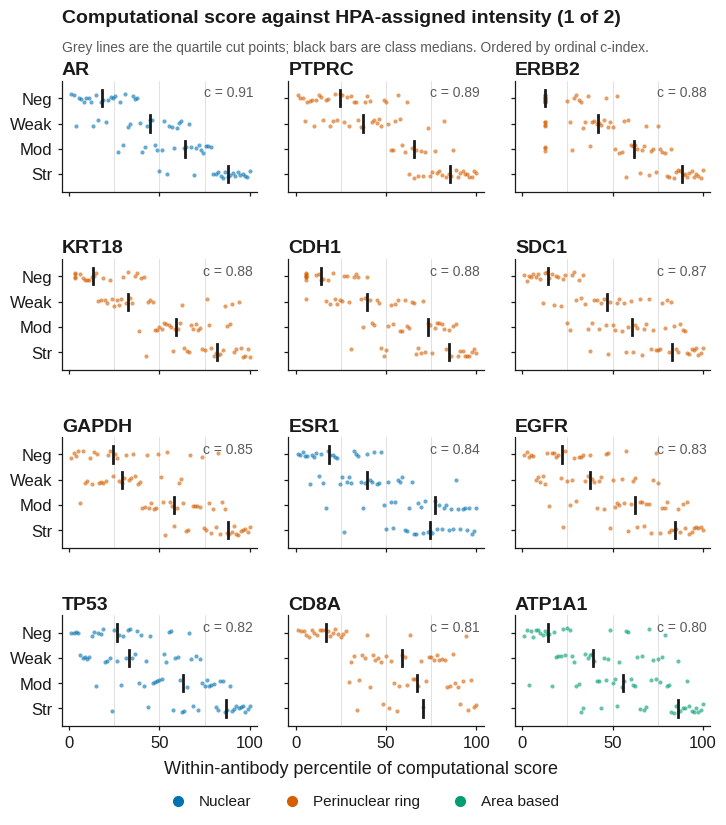

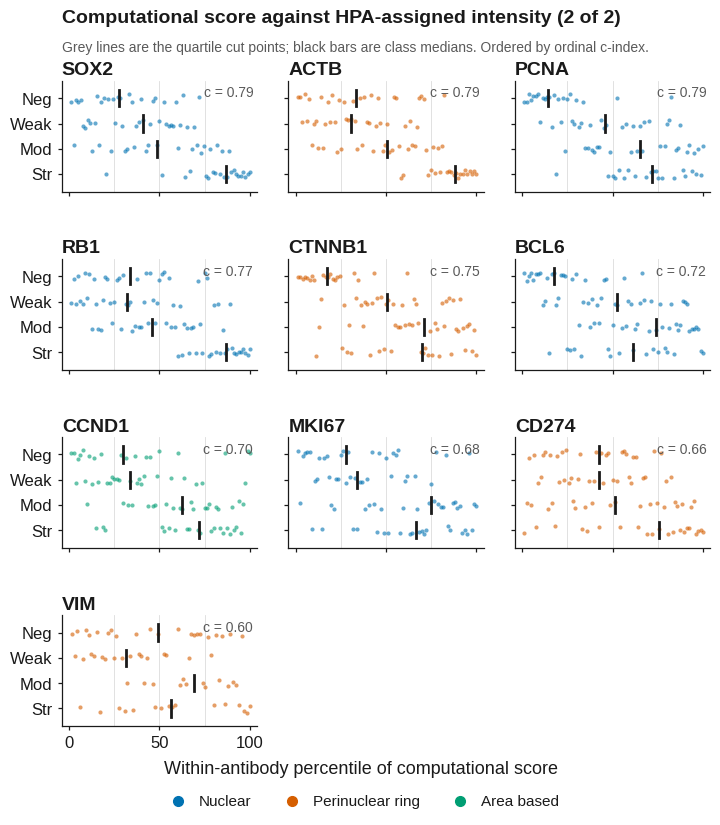

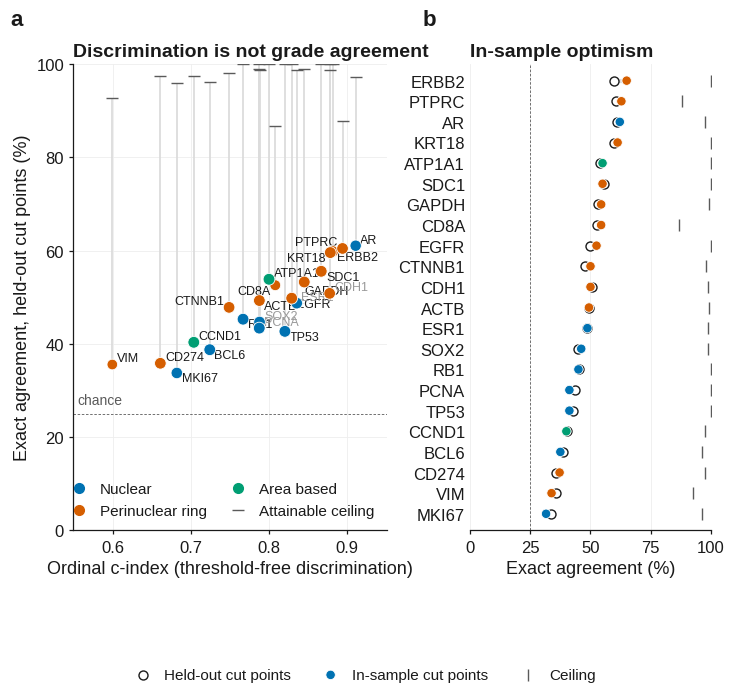

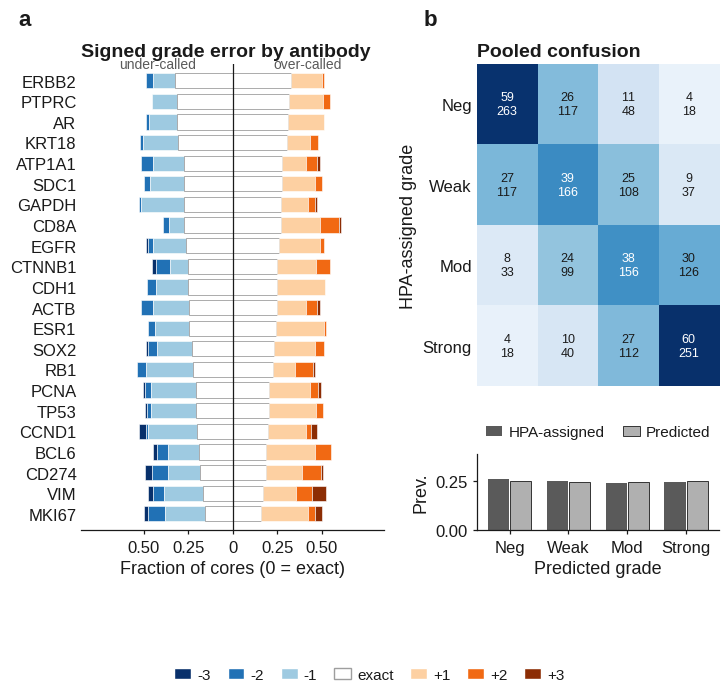

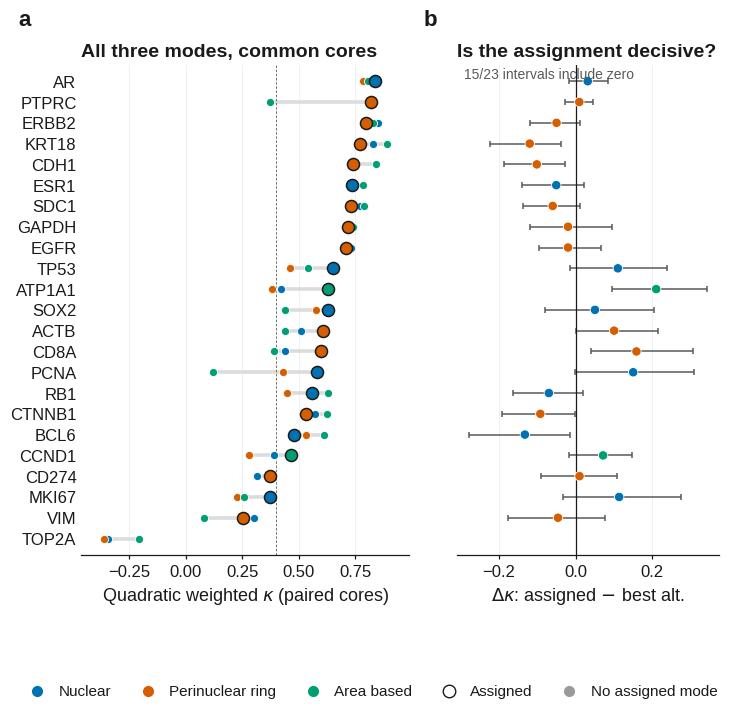

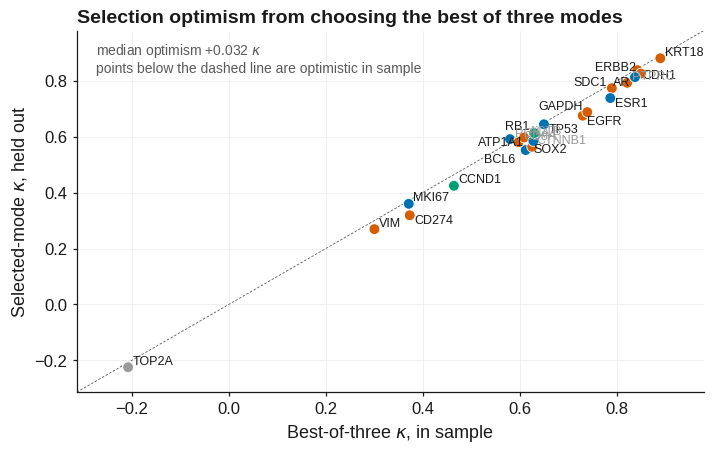

In [ ]:
"""
HPA agreement: analysis and figure program (rewrite).

What changed relative to the previous version, and why
-----------------------------------------------------
1. The previous code mapped continuous scores to four grades using the
   *evaluation set's own* quartiles. That forces the predicted marginal
   distribution to be exactly 25/25/25/25 and fits the cut points on the
   same cores used for scoring. Both are fixed here:
     - the attainable ceiling under fixed margins is computed and reported
       (sum_c min(pred_prev_c, truth_prev_c)),
     - a repeated split-sample estimate is added: cut points are fitted on
       one half of the cores and applied to the held-out half.
2. Threshold-free discrimination (Spearman rho, ordinal c-index) is
   separated from threshold placement (calibration). These are different
   claims and the old figures conflated them.
3. Pooled confidence intervals now use a cluster bootstrap over antibodies
   rather than a Wilson interval on pooled cores, which treats 1,800
   clustered cores as 1,800 independent trials.
4. Mode comparison is computed on the *paired* core intersection, with a
   bootstrap CI on the within-antibody difference, plus an explicit estimate
   of the selection optimism from picking the best of three modes.

Inputs (unchanged paths)
------------------------
  {OUT_DIR}/sourcedata_hpa_nuclear_percore_fixed.csv
  {OUT_DIR}/sourcedata_hpa_ring_percore_fixed.csv
  {OUT_DIR}/sourcedata_hpa_area_percore.csv
  {FIG_DIR}/mode_assignment_used.csv
  {OUT_DIR}/mode_comparison_full_FIXED.csv        (optional, cross-checked)

Outputs in {FIG_DIR}
--------------------
  F1_score_vs_grade.(svg|pdf)          raw evidence, per antibody
  F2_discrimination_calibration.(svg|pdf)
  F3_error_structure.(svg|pdf)
  F4_mode_comparison.(svg|pdf)
  sourcedata_*.csv                     one table per figure
  figure_legends.txt
"""

import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings('ignore', category=RuntimeWarning)

# =============================================================================
# Configuration
# =============================================================================
HPA_DIR = os.environ.get('HPA_DIR', '/content/drive/MyDrive/HPA_calibration')
OUT_DIR = f'{HPA_DIR}/validation_frozen'
FIG_DIR = f'{OUT_DIR}/figures_v4'
os.makedirs(FIG_DIR, exist_ok=True)

ASSIGNMENT_CSV = f'{OUT_DIR}/figures_final/mode_assignment_used.csv'
MODE_COMPARISON_CSV = f'{OUT_DIR}/mode_comparison_full_FIXED.csv'

PERCORE_PATHS = {
    'nuclear': f'{OUT_DIR}/sourcedata_hpa_nuclear_percore_fixed.csv',
    'perinuclear_ring': f'{OUT_DIR}/sourcedata_hpa_ring_percore_fixed.csv',
    'area': f'{OUT_DIR}/sourcedata_hpa_area_percore.csv',
}
SCORE_COL = {
    'nuclear': 'H_score',
    'perinuclear_ring': 'H_score',
    'area': 'area_intensity_score',
}

MODES = ['nuclear', 'perinuclear_ring', 'area']
LEVELS = ['Negative', 'Weak', 'Moderate', 'Strong']
LMAP = {name: i for i, name in enumerate(LEVELS)}

N_BOOT = 2000          # bootstrap replicates
N_SPLITS = 200         # repeated split-half replicates for out-of-sample cuts
SEED = 20260902
RNG = np.random.default_rng(SEED)

MODE_LABEL = {
    'nuclear': 'Nuclear',
    'perinuclear_ring': 'Perinuclear ring',
    'area': 'Area based',
}
# Okabe-Ito
MODE_COLOR = {
    'nuclear': '#0072B2',
    'perinuclear_ring': '#D55E00',
    'area': '#009E73',
}
UNASSIGNED_COLOR = '#9A9A9A'
GREY = '#5A5A5A'
LIGHT = '#DCDCDC'
INK = '#1A1A1A'

# Diverging palette for signed ordinal error (under-call ... over-call)
ERR_COLOR = {
    -3: '#08306B', -2: '#2171B5', -1: '#9ECAE1',
    0: '#FFFFFF',
    1: '#FDD0A2', 2: '#F16913', 3: '#8C2D04',
}

# -----------------------------------------------------------------------------
# Typography and output
# -----------------------------------------------------------------------------
# font.sans-serif is a FALLBACK CHAIN: if Arial is missing matplotlib drops to
# the next entry silently. This resolves it once and prints what was actually
# used, so a fallback is never invisible.
#
#   !apt-get update -qq
#   !echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula \
#          select true" | debconf-set-selections
#   !DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
#          ttf-mscorefonts-installer
#   !apt-get install -y -qq fonts-liberation
#   !fc-cache -f
# then delete matplotlib.get_cachedir() and restart the runtime.
#
# Liberation Sans is metrically identical to Arial and is an accepted
# substitute if the mscorefonts download fails, which it often does in Colab.
FONT_PREFERENCE = ['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans']


def resolve_font(candidates):
    from matplotlib import font_manager
    for name in candidates:
        try:
            path = font_manager.findfont(name, fallback_to_default=False)
        except Exception:
            continue
        if path and os.path.exists(path):
            return name, path
    return None, None


FONT_NAME, FONT_PATH = resolve_font(FONT_PREFERENCE)
if FONT_NAME is None:
    FONT_NAME = 'DejaVu Sans'
    print('WARNING: none of the preferred fonts are installed; '
          'falling back to DejaVu Sans.')
elif FONT_NAME != FONT_PREFERENCE[0]:
    print(f'NOTE: {FONT_PREFERENCE[0]} not found. Using {FONT_NAME} '
          f'({FONT_PATH}).')
else:
    print(f'Font in use: {FONT_NAME} ({FONT_PATH})')

# Axis ticks and axis titles never go below 12 pt, per the brief. In-plot
# annotations (point labels, matrix cell counts) are allowed to be smaller
# because they are not axis text and would otherwise force the layout apart.
PT_TICK = 12
PT_LABEL = 13
PT_TITLE = 14
PT_LETTER = 16
PT_LEGEND = 11
PT_ANNOT = 9
PT_SMALL = 10

# Line weights heavy enough to survive a 600 dpi raster and a later reduction.
LW_AXIS = 0.9
LW_GRID = 0.6
LW_EDGE = 0.6
LW_ERR = 1.1

FORMATS = ('svg', 'tiff')
DPI = 600

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [FONT_NAME],
    'font.size': PT_TICK,
    'axes.titlesize': PT_TITLE,
    'axes.titleweight': 'bold',
    'axes.labelsize': PT_LABEL,
    'axes.linewidth': LW_AXIS,
    'axes.edgecolor': INK,
    'xtick.labelsize': PT_TICK,
    'ytick.labelsize': PT_TICK,
    'xtick.major.width': LW_AXIS,
    'ytick.major.width': LW_AXIS,
    'xtick.major.size': 3.2,
    'ytick.major.size': 3.2,
    'xtick.color': INK,
    'ytick.color': INK,
    'text.color': INK,
    'axes.labelcolor': INK,
    'legend.fontsize': PT_LEGEND,
    'lines.linewidth': 1.1,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
})
MM = 1 / 25.4

# =============================================================================
# Fonts and export format
# =============================================================================
# Colab has no Arial, and matplotlib falls through a font.sans-serif list
# silently. Because svg.fonttype is 'none', whatever font actually resolves
# is the name written into the SVG, so a silent fallback means Illustrator
# will not render Arial even on a machine that has it. setup_font() registers
# any fonts it can find, reports what was actually chosen, and pins the family
# to that one name so the SVG carries it unambiguously.


def mode_color(m):
    """Colour for a mode; grey when the antibody has no assigned mode."""
    return MODE_COLOR.get(m, UNASSIGNED_COLOR)


# =============================================================================
# Loading
# =============================================================================
def load_percore(mode):
    path = PERCORE_PATHS[mode]
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    score_col = SCORE_COL[mode]
    if score_col not in df.columns:
        raise ValueError(f'{path} is missing {score_col}')
    if 'truth_num' not in df.columns:
        if 'intensity' not in df.columns:
            raise ValueError(f'{path}: neither truth_num nor intensity')
        df['truth_num'] = df['intensity'].astype(str).map(LMAP)
    out = pd.DataFrame({
        'marker': df['marker'].astype(str),
        'core': df['core'].astype(str),
        'truth': pd.to_numeric(df['truth_num'], errors='coerce'),
        'score': pd.to_numeric(df[score_col], errors='coerce'),
    })
    return out.dropna(subset=['truth', 'score']).assign(
        truth=lambda d: d['truth'].astype(int), mode=mode)


DATA = {mode: load_percore(mode) for mode in MODES}
LONG = pd.concat(DATA.values(), ignore_index=True)

assignment = pd.read_csv(ASSIGNMENT_CSV)
assignment['marker'] = assignment['marker'].astype(str)
if not {'marker', 'assigned_mode'} <= set(assignment.columns):
    raise ValueError(f'{ASSIGNMENT_CSV} needs marker and assigned_mode')
ASSIGNED = dict(zip(assignment.marker, assignment.assigned_mode.astype(str)))

UNASSIGNED = sorted(set(LONG.marker) - set(ASSIGNED))
if UNASSIGNED:
    print('Markers present in the per-core files but absent from '
          f'{os.path.basename(ASSIGNMENT_CSV)}: {UNASSIGNED}\n'
          'These are excluded from Figures 1-3 and drawn in grey in Figure 4.')


# =============================================================================
# Metrics
# =============================================================================
def quartile_cuts(score):
    return np.quantile(np.asarray(score, float), [0.25, 0.50, 0.75])


def apply_cuts(score, cuts):
    return np.digitize(np.asarray(score, float), cuts)


def kappa_w(truth, pred):
    if len(np.unique(truth)) < 2 and len(np.unique(pred)) < 2:
        return np.nan
    return cohen_kappa_score(truth, pred, weights='quadratic',
                             labels=[0, 1, 2, 3])


def ordinal_c_index(score, truth):
    """P(score ranks a higher-grade core above a lower-grade core), ties = 0.5.

    Threshold-free. 0.5 = no discrimination, 1.0 = perfect ordering.
    """
    s = np.asarray(score, float)
    t = np.asarray(truth, float)
    ds = s[:, None] - s[None, :]
    dt = t[:, None] - t[None, :]
    comparable = dt > 0
    n = comparable.sum()
    if n == 0:
        return np.nan
    concordant = ((ds > 0) & comparable).sum()
    tied = ((ds == 0) & comparable).sum()
    return (concordant + 0.5 * tied) / n


def agreement_ceiling(truth, n_classes=4):
    """Max attainable exact agreement when predicted margins are forced uniform.

    Under fixed row/column margins the trace cannot exceed
    sum_c min(pred_prev_c, truth_prev_c). With quartile cuts pred_prev = 1/4.
    """
    p_truth = np.bincount(np.asarray(truth, int), minlength=n_classes) / len(truth)
    p_pred = np.full(n_classes, 1.0 / n_classes)
    return float(np.minimum(p_pred, p_truth).sum())


def split_half_agreement(score, truth, n_splits=N_SPLITS, rng=None):
    """Cuts fitted on half the cores, evaluated on the held-out half.

    Stratified by truth grade so both halves span the grade range.
    Returns mean out-of-sample exact agreement and mean kappa_w.
    """
    rng = rng or RNG
    s = np.asarray(score, float)
    t = np.asarray(truth, int)
    idx_by_class = [np.flatnonzero(t == c) for c in range(4)]
    acc, kap = [], []
    for _ in range(n_splits):
        train, test = [], []
        for idx in idx_by_class:
            if len(idx) == 0:
                continue
            perm = rng.permutation(idx)
            half = max(1, len(perm) // 2)
            train.append(perm[:half])
            test.append(perm[half:])
        train = np.concatenate(train) if train else np.array([], int)
        test = np.concatenate(test) if test else np.array([], int)
        if len(train) < 8 or len(test) < 8:
            continue
        cuts = quartile_cuts(s[train])
        pred = apply_cuts(s[test], cuts)
        acc.append(np.mean(pred == t[test]))
        kap.append(kappa_w(t[test], pred))
    if not acc:
        return np.nan, np.nan
    return float(np.mean(acc)), float(np.nanmean(kap))


def boot_ci(values_fn, n, n_boot=N_BOOT, rng=None, alpha=0.05):
    """Percentile bootstrap over n exchangeable units."""
    rng = rng or RNG
    stats = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        stats[b] = values_fn(idx)
    lo, hi = np.nanpercentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


def place_labels(ax, xs, ys, labels, fontsize=5.0, color=INK):
    """Greedy non-overlapping point labels; falls back to a default offset."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    offsets = [(3.4, 2.2), (3.4, -6.0), (-3.4, 2.2), (-3.4, -6.0),
               (0, 6.0), (0, -8.5), (7.5, 0), (-7.5, 0),
               (7.5, 6.5), (-7.5, -9.0), (12, 4), (-12, -8),
               (14, -8), (-14, 6), (18, 0), (-18, 0),
               (20, 9), (-20, -12), (24, -4), (-24, 4)]
    placed = []
    for i in np.argsort(-np.asarray(ys, float)):
        done = False
        for dx, dy in offsets:
            far = abs(dx) > 9 or abs(dy) > 9
            txt = ax.annotate(
                labels[i], (xs[i], ys[i]), textcoords='offset points',
                xytext=(dx, dy), fontsize=fontsize, color=color,
                ha='left' if dx >= 0 else 'right',
                arrowprops=(dict(arrowstyle='-', lw=0.3, color='#B0B0B0',
                                 shrinkA=0.5, shrinkB=1.5) if far else None))
            bb = txt.get_window_extent(renderer=renderer).expanded(1.06, 1.25)
            if not any(bb.overlaps(q) for q in placed):
                placed.append(bb)
                done = True
                break
            txt.remove()
        if not done:
            txt = ax.annotate(labels[i], (xs[i], ys[i]),
                              textcoords='offset points', xytext=(3.4, 2.2),
                              fontsize=fontsize, color='#9A9A9A', ha='left')
            placed.append(txt.get_window_extent(renderer=renderer))


# -----------------------------------------------------------------------------
# Per-antibody table under the assigned mode
# -----------------------------------------------------------------------------
records = []
percore_rows = []
for marker, mode in sorted(ASSIGNED.items()):
    if mode not in DATA:
        print(f'{marker}: unknown mode {mode}; skipped')
        continue
    grp = DATA[mode].query('marker == @marker')
    if len(grp) < 8 or grp.truth.nunique() < 2:
        print(f'{marker}: insufficient data under {mode}; skipped')
        continue

    s = grp.score.to_numpy(float)
    t = grp.truth.to_numpy(int)
    n = len(t)

    cuts = quartile_cuts(s)
    pred = apply_cuts(s, cuts)
    err = pred - t

    ceiling = agreement_ceiling(t)
    exact = float(np.mean(pred == t))
    oos_exact, oos_kappa = split_half_agreement(s, t)

    lo, hi = boot_ci(lambda idx, s=s, t=t: np.mean(
        apply_cuts(s[idx], quartile_cuts(s[idx])) == t[idx]), n)

    rho = spearmanr(s, t).statistic
    cidx = ordinal_c_index(s, t)

    records.append({
        'marker': marker,
        'assigned_mode': mode,
        'n_cores': n,
        'rho_spearman': rho,
        'c_index': cidx,
        'kappa_w': kappa_w(t, pred),
        'exact_insample': 100 * exact,
        'exact_ci_low': 100 * lo,
        'exact_ci_high': 100 * hi,
        'exact_ceiling': 100 * ceiling,
        'exact_outofsample': 100 * oos_exact,
        'kappa_w_outofsample': oos_kappa,
        'optimism_pp': 100 * (exact - oos_exact),
        'kappa_over_kappa_max': ((exact - 0.25) / (ceiling - 0.25)
                                 if ceiling > 0.2501 else np.nan),
        'within_one_pct': 100 * np.mean(np.abs(err) <= 1),
        'mean_signed_error': float(np.mean(err)),
        **{f'truth_prev_{c}': float(np.mean(t == c)) for c in range(4)},
        **{f'err_{d:+d}': float(np.mean(err == d)) for d in range(-3, 4)},
    })
    percore_rows.append(pd.DataFrame({
        'marker': marker, 'mode': mode, 'core': grp.core.to_numpy(),
        'truth': t, 'score': s, 'predicted': pred, 'signed_error': err,
        'score_pct': 100 * (pd.Series(s).rank(pct=True).to_numpy()),
    }))

per_ab = pd.DataFrame(records).sort_values('exact_insample',
                                           ascending=False).reset_index(drop=True)
per_core = pd.concat(percore_rows, ignore_index=True)
if per_ab.empty:
    raise RuntimeError('No antibodies produced results.')


# -----------------------------------------------------------------------------
# Pooled estimates with a cluster bootstrap over antibodies
# -----------------------------------------------------------------------------
markers = per_ab.marker.tolist()
core_lists = {m: per_core.query('marker == @m') for m in markers}

def _pooled(idx):
    frames = [core_lists[markers[i]] for i in idx]
    hits = sum((f.predicted == f.truth).sum() for f in frames)
    tot = sum(len(f) for f in frames)
    return hits / tot

micro = 100 * _pooled(np.arange(len(markers)))
macro = per_ab.exact_insample.mean()
micro_lo, micro_hi = boot_ci(_pooled, len(markers))
micro_lo, micro_hi = 100 * micro_lo, 100 * micro_hi

def _pooled_macro(idx):
    return np.mean([per_ab.exact_insample.iloc[i] for i in idx])

macro_lo, macro_hi = boot_ci(_pooled_macro, len(markers))

pooled_oos = per_ab.exact_outofsample.mean()
mean_ceiling = per_ab.exact_ceiling.mean()

pooled = pd.DataFrame([
    {'estimator': 'Core-weighted, in-sample cuts', 'value_pct': micro,
     'ci_low': micro_lo, 'ci_high': micro_hi,
     'ci_method': 'cluster bootstrap over antibodies'},
    {'estimator': 'Antibody mean, in-sample cuts', 'value_pct': macro,
     'ci_low': macro_lo, 'ci_high': macro_hi,
     'ci_method': 'cluster bootstrap over antibodies'},
    {'estimator': 'Antibody mean, held-out cuts', 'value_pct': pooled_oos,
     'ci_low': np.nan, 'ci_high': np.nan,
     'ci_method': f'mean of {N_SPLITS} stratified split halves'},
    {'estimator': 'Attainable ceiling (mean)', 'value_pct': mean_ceiling,
     'ci_low': np.nan, 'ci_high': np.nan,
     'ci_method': 'sum_c min(pred_prev, truth_prev)'},
    {'estimator': 'Chance (forced uniform margins)', 'value_pct': 25.0,
     'ci_low': np.nan, 'ci_high': np.nan, 'ci_method': 'analytic'},
])


# -----------------------------------------------------------------------------
# Paired mode comparison on the common core set
# -----------------------------------------------------------------------------
wide = LONG.pivot_table(index=['marker', 'core'], columns='mode',
                        values='score', aggfunc='first')
truth_lu = (LONG.drop_duplicates(['marker', 'core'])
            .set_index(['marker', 'core']).truth)
wide = wide.join(truth_lu).dropna()

mode_rows = []
paired_core = []
for marker, grp in wide.groupby(level=0):
    if len(grp) < 12 or grp.truth.nunique() < 2:
        continue
    t = grp.truth.to_numpy(int)
    kappas, exacts = {}, {}
    preds = {}
    for mode in MODES:
        if mode not in grp.columns:
            continue
        s = grp[mode].to_numpy(float)
        p = apply_cuts(s, quartile_cuts(s))
        preds[mode] = p
        kappas[mode] = kappa_w(t, p)
        exacts[mode] = 100 * np.mean(p == t)
    if len(kappas) < 2:
        continue
    assigned = ASSIGNED.get(marker)
    alt = [m for m in kappas if m != assigned]
    best_alt = max(alt, key=lambda m: kappas[m]) if alt else None
    delta = (kappas[assigned] - kappas[best_alt]
             if assigned in kappas and best_alt else np.nan)

    n = len(t)
    def _delta(idx, t=t, preds=preds, assigned=assigned, best_alt=best_alt):
        return (kappa_w(t[idx], preds[assigned][idx])
                - kappa_w(t[idx], preds[best_alt][idx]))
    if assigned in preds and best_alt:
        d_lo, d_hi = boot_ci(_delta, n, n_boot=600)
    else:
        d_lo = d_hi = np.nan

    # Selection optimism: pick the best mode on one half, score on the other.
    sel_in, sel_out = [], []
    idx_by_class = [np.flatnonzero(t == c) for c in range(4)]
    for _ in range(100):
        tr, te = [], []
        for idx in idx_by_class:
            if len(idx) == 0:
                continue
            perm = RNG.permutation(idx)
            h = max(1, len(perm) // 2)
            tr.append(perm[:h]); te.append(perm[h:])
        tr = np.concatenate(tr); te = np.concatenate(te)
        if len(tr) < 8 or len(te) < 8:
            continue
        k_tr = {m: kappa_w(t[tr], apply_cuts(grp[m].to_numpy(float)[tr],
                                             quartile_cuts(grp[m].to_numpy(float)[tr])))
                for m in preds}
        pick = max(k_tr, key=lambda m: (k_tr[m] if np.isfinite(k_tr[m]) else -9))
        s_all = grp[pick].to_numpy(float)
        k_te = kappa_w(t[te], apply_cuts(s_all[te], quartile_cuts(s_all[tr])))
        sel_in.append(k_tr[pick]); sel_out.append(k_te)

    row = {'marker': marker, 'n_paired_cores': n,
           'assigned_mode': assigned, 'best_alternative': best_alt,
           'delta_kappa_assigned_minus_best_alt': delta,
           'delta_ci_low': d_lo, 'delta_ci_high': d_hi,
           'best_of_three_insample': max(
               (v for v in kappas.values() if np.isfinite(v)), default=np.nan),
           'selected_kappa_heldout': float(np.nanmean(sel_out)) if sel_out else np.nan,
           'selection_optimism': (float(np.nanmean(sel_in)) - float(np.nanmean(sel_out))
                                  if sel_out else np.nan)}
    row.update({f'kappa_{m}': kappas.get(m, np.nan) for m in MODES})
    row.update({f'exact_{m}': exacts.get(m, np.nan) for m in MODES})
    mode_rows.append(row)

mode_tab = pd.DataFrame(mode_rows)


# =============================================================================
# Output helper
# =============================================================================
def save(fig, stem):
    """Editable SVG plus a 600 dpi LZW TIFF."""
    paths = []
    for ext in FORMATS:
        p = f'{FIG_DIR}/{stem}.{ext}'
        if ext == 'tiff':
            fig.savefig(p, format='tiff', dpi=DPI, facecolor='white',
                        pil_kwargs={'compression': 'tiff_lzw'})
        else:
            fig.savefig(p, format=ext, facecolor='white')
        paths.append(p)
    return paths


written = []


# =============================================================================
# Figure 1 (split across F1a / F1b) - score against grade, per antibody
# =============================================================================
order_f1 = per_ab.sort_values('c_index', ascending=False).marker.tolist()
NCOL_F1, NROW_F1 = 3, 4
PER_FIG = NCOL_F1 * NROW_F1
chunks = [order_f1[i:i + PER_FIG] for i in range(0, len(order_f1), PER_FIG)]

for part, chunk in enumerate(chunks):
    nrow = int(np.ceil(len(chunk) / NCOL_F1))
    fig_h = 30 + 46 * nrow
    fig1 = plt.figure(figsize=(183 * MM, fig_h * MM))
    gs1 = GridSpec(nrow, NCOL_F1, figure=fig1, hspace=0.60, wspace=0.16,
                   left=0.085, right=0.985, top=1 - 24 / fig_h,
                   bottom=26 / fig_h)

    for k, marker in enumerate(chunk):
        ax = fig1.add_subplot(gs1[k // NCOL_F1, k % NCOL_F1])
        sub = per_core.query('marker == @marker')
        mode = per_ab.set_index('marker').assigned_mode[marker]
        colour = MODE_COLOR[mode]
        for cut in (25, 50, 75):
            ax.axvline(cut, color=LIGHT, lw=LW_GRID, zorder=0)
        for c in range(4):
            v = sub.query('truth == @c').score_pct.to_numpy()
            if len(v) == 0:
                continue
            jitter = RNG.uniform(-0.17, 0.17, len(v))
            ax.scatter(v, np.full(len(v), c) + jitter, s=9, color=colour,
                       alpha=0.60, linewidths=0, zorder=2)
            med = np.median(v)
            ax.plot([med, med], [c - 0.32, c + 0.32], color=INK, lw=2.0,
                    zorder=3)
        ax.set_ylim(3.7, -0.7)
        ax.set_xlim(-4, 104)
        ax.set_yticks(range(4))
        ax.set_xticks([0, 50, 100])
        if k % NCOL_F1 == 0:
            ax.set_yticklabels(['Neg', 'Weak', 'Mod', 'Str'])
        else:
            ax.set_yticklabels([])
        if k // NCOL_F1 != nrow - 1:
            ax.set_xticklabels([])
        row = per_ab.set_index('marker').loc[marker]
        ax.set_title(marker, loc='left', pad=4)
        ax.text(0.98, 0.95, f'c = {row.c_index:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=PT_SMALL, color=GREY)
        ax.spines[['top', 'right']].set_visible(False)

    for k in range(len(chunk), nrow * NCOL_F1):
        fig1.add_subplot(gs1[k // NCOL_F1, k % NCOL_F1]).axis('off')

    label = f'{part + 1} of {len(chunks)}'
    fig1.text(0.085, 1 - 6 / fig_h,
              f'Computational score against HPA-assigned intensity '
              f'({label})', fontsize=PT_TITLE, fontweight='bold', va='top')
    fig1.text(0.085, 1 - 14 / fig_h,
              'Grey lines are the quartile cut points; black bars are class '
              'medians. Ordered by ordinal c-index.',
              fontsize=PT_SMALL, color=GREY, va='top')
    fig1.text(0.5, 14 / fig_h,
              'Within-antibody percentile of computational score',
              ha='center', fontsize=PT_LABEL)
    h1 = [Line2D([0], [0], marker='o', ls='', ms=7, color=MODE_COLOR[m],
                 label=MODE_LABEL[m]) for m in MODES]
    fig1.legend(handles=h1, ncol=3, frameon=False, loc='lower center',
                bbox_to_anchor=(0.5, 1.5 / fig_h), fontsize=PT_LEGEND,
                handletextpad=0.4, columnspacing=1.6)
    written += save(fig1, f'F1{"ab"[part] if part < 2 else part}'
                          f'_score_vs_grade')


# =============================================================================
# Figure 2 - discrimination versus calibration
# =============================================================================
fig_h2 = max(155, 44 + 6.2 * len(per_ab))
fig2 = plt.figure(figsize=(183 * MM, fig_h2 * MM))
gs2 = GridSpec(1, 2, figure=fig2, wspace=0.30, left=0.100, right=0.985,
               top=1 - 18 / fig_h2, bottom=44 / fig_h2,
               width_ratios=[1.3, 1])
ax_a = fig2.add_subplot(gs2[0, 0])
ax_b = fig2.add_subplot(gs2[0, 1])

ax_a.axhline(25, color=GREY, lw=LW_GRID, ls=(0, (3, 2)))
ax_a.text(0.012, 26.5, 'chance', fontsize=PT_SMALL, color=GREY,
          va='bottom', transform=ax_a.get_yaxis_transform())
for _, r in per_ab.iterrows():
    ax_a.plot([r.c_index, r.c_index], [r.exact_outofsample, r.exact_ceiling],
              color=LIGHT, lw=1.3, zorder=1, solid_capstyle='butt')
ax_a.scatter(per_ab.c_index, per_ab.exact_ceiling, marker='_', s=70,
             color=GREY, lw=1.0, zorder=2)
for mode in MODES:
    m = per_ab.assigned_mode == mode
    ax_a.scatter(per_ab.c_index[m], per_ab.exact_outofsample[m],
                 s=np.clip(per_ab.n_cores[m] * 0.9, 30, 95),
                 color=MODE_COLOR[mode], edgecolor='white', lw=LW_EDGE,
                 zorder=4, label=MODE_LABEL[mode])
place_labels(ax_a, per_ab.c_index.to_numpy(float),
             per_ab.exact_outofsample.to_numpy(float),
             per_ab.marker.tolist(), fontsize=PT_ANNOT)
ax_a.set_xlabel('Ordinal c-index (threshold-free discrimination)')
ax_a.set_ylabel('Exact agreement, held-out cut points (%)')
ax_a.set_ylim(0, 100)
_c = per_ab.c_index.to_numpy(float)
ax_a.set_xlim(max(0.45, np.nanmin(_c) - 0.05), min(1.01, np.nanmax(_c) + 0.04))
ax_a.grid(color='#EEEEEE', lw=LW_GRID)
ax_a.set_axisbelow(True)
ax_a.spines[['top', 'right']].set_visible(False)
ax_a.set_title('Discrimination is not grade agreement', loc='left', pad=6)
fig2.text(0.012, 1 - 4 / fig_h2, 'a', fontsize=PT_LETTER,
          fontweight='bold', va='top')
h2 = [Line2D([0], [0], marker='o', ls='', ms=7, color=MODE_COLOR[m],
             label=MODE_LABEL[m]) for m in MODES]
h2.append(Line2D([0], [0], marker='_', ls='', ms=9, color=GREY,
                 label='Attainable ceiling'))
ax_a.legend(handles=h2, ncol=2, frameon=False, loc='lower right',
            handletextpad=0.4, columnspacing=1.0, borderaxespad=0.4)

srt = per_ab.sort_values('exact_insample')
yy = np.arange(len(srt))
ax_b.hlines(yy, srt.exact_outofsample, srt.exact_insample, color=LIGHT,
            lw=3.0, zorder=1)
ax_b.scatter(srt.exact_outofsample, yy, s=42, color='white', edgecolor=INK,
             lw=1.0, zorder=3, label='Held-out cut points')
ax_b.scatter(srt.exact_insample, yy, s=46,
             color=[mode_color(m) for m in srt.assigned_mode],
             edgecolor='white', lw=LW_EDGE, zorder=4,
             label='In-sample cut points')
ax_b.scatter(srt.exact_ceiling, yy, marker='|', s=70, color=GREY, lw=1.0,
             zorder=2, label='Ceiling')
ax_b.axvline(25, color=GREY, lw=LW_GRID, ls=(0, (3, 2)))
ax_b.set_yticks(yy)
ax_b.set_yticklabels(srt.marker)
ax_b.set_ylim(-0.8, len(srt) - 0.2)
ax_b.set_xlim(0, 100)
ax_b.set_xlabel('Exact agreement (%)')
ax_b.grid(axis='x', color='#EEEEEE', lw=LW_GRID)
ax_b.set_axisbelow(True)
ax_b.spines[['top', 'right', 'left']].set_visible(False)
ax_b.tick_params(axis='y', length=0)
ax_b.set_title('In-sample optimism', loc='left', pad=6)
fig2.text(0.585, 1 - 4 / fig_h2, 'b', fontsize=PT_LETTER,
          fontweight='bold', va='top')
_hb, _lb = ax_b.get_legend_handles_labels()
fig2.legend(_hb, _lb, ncol=3, frameon=False, fontsize=PT_LEGEND,
            loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h2),
            handletextpad=0.4, columnspacing=1.6)
written += save(fig2, 'F2_discrimination_calibration')


# =============================================================================
# Figure 3 - where the disagreements are
# =============================================================================
fig_h3 = max(165, 44 + 6.2 * len(per_ab))
fig3 = plt.figure(figsize=(183 * MM, fig_h3 * MM))
gs3 = GridSpec(1, 2, figure=fig3, wspace=0.34, left=0.100, right=0.985,
               top=1 - 18 / fig_h3, bottom=44 / fig_h3,
               width_ratios=[1.25, 1])
ax_e = fig3.add_subplot(gs3[0, 0])
gs3r = gs3[0, 1].subgridspec(2, 1, height_ratios=[4.2, 1], hspace=0.34)
ax_c = fig3.add_subplot(gs3r[0])
ax_m = fig3.add_subplot(gs3r[1])

srt3 = per_ab.sort_values('exact_insample').reset_index(drop=True)
for i, r in srt3.iterrows():
    left = -(r['err_-1'] + r['err_-2'] + r['err_-3']) - r['err_+0'] / 2
    for d in [-3, -2, -1, 0, 1, 2, 3]:
        w = r[f'err_{d:+d}']
        if w <= 0:
            continue
        ax_e.barh(i, w, left=left, height=0.74, color=ERR_COLOR[d],
                  edgecolor='#9E9E9E' if d == 0 else 'white',
                  lw=0.6 if d == 0 else 0.4, zorder=2)
        left += w
ax_e.axvline(0, color=INK, lw=LW_AXIS, zorder=3)
ax_e.set_yticks(np.arange(len(srt3)))
ax_e.set_yticklabels(srt3.marker)
ax_e.set_ylim(-0.8, len(srt3) - 0.2)
ax_e.set_xlabel('Fraction of cores (0 = exact)')
ax_e.set_xlim(-0.85, 0.85)
ax_e.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
ax_e.set_xticklabels(['0.50', '0.25', '0', '0.25', '0.50'])
ax_e.tick_params(axis='y', length=0)
ax_e.spines[['top', 'right', 'left']].set_visible(False)
ax_e.set_title('Signed grade error by antibody', loc='left', pad=6)
fig3.text(0.012, 1 - 4 / fig_h3, 'a', fontsize=PT_LETTER,
          fontweight='bold', va='top')
ax_e.text(-0.42, len(srt3) - 0.55, 'under-called', fontsize=PT_SMALL,
          color=GREY, ha='center', va='bottom')
ax_e.text(0.42, len(srt3) - 0.55, 'over-called', fontsize=PT_SMALL,
          color=GREY, ha='center', va='bottom')
leg3 = [Patch(facecolor=ERR_COLOR[d],
              edgecolor='#9E9E9E' if d == 0 else 'white',
              label=('exact' if d == 0 else f'{d:+d}'))
        for d in [-3, -2, -1, 0, 1, 2, 3]]
fig3.legend(handles=leg3, ncol=7, frameon=False, fontsize=PT_LEGEND,
            loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h3),
            handlelength=1.1, handletextpad=0.4, columnspacing=1.1)

conf = np.zeros((4, 4))
for t, p in zip(per_core.truth, per_core.predicted):
    conf[int(t), int(p)] += 1
row_norm = conf / np.clip(conf.sum(axis=1, keepdims=True), 1, None)
ax_c.imshow(row_norm, cmap='Blues', vmin=0, vmax=row_norm.max(),
            aspect='auto')
for i in range(4):
    for j in range(4):
        ax_c.text(j, i, f'{row_norm[i, j]*100:.0f}\n{int(conf[i, j])}',
                  ha='center', va='center', fontsize=PT_ANNOT,
                  color='white' if row_norm[i, j] > 0.55 * row_norm.max()
                  else INK)
ax_c.set_xticks(range(4)); ax_c.set_yticks(range(4))
ax_c.set_xticklabels([])
ax_c.set_yticklabels(['Neg', 'Weak', 'Mod', 'Strong'])
ax_c.set_ylabel('HPA-assigned grade')
ax_c.set_title('Pooled confusion', loc='left', pad=6)
fig3.text(0.575, 1 - 4 / fig_h3, 'b', fontsize=PT_LETTER,
          fontweight='bold', va='top')
for sp in ax_c.spines.values():
    sp.set_visible(False)
ax_c.tick_params(length=0)

p_true = conf.sum(axis=1) / conf.sum()
p_pred = conf.sum(axis=0) / conf.sum()
xm = np.arange(4)
ax_m.bar(xm - 0.19, p_true, width=0.36, color=GREY, label='HPA-assigned')
ax_m.bar(xm + 0.19, p_pred, width=0.36, color='#B0B0B0', edgecolor=INK,
         lw=0.6, label='Predicted')
ax_m.set_xticks(xm)
ax_m.set_xticklabels(['Neg', 'Weak', 'Mod', 'Strong'])
ax_m.set_ylim(0, max(p_true.max(), p_pred.max()) * 1.5)
ax_m.set_yticks([0, 0.25])
ax_m.set_ylabel('Prev.')
ax_m.set_xlabel('Predicted grade')
ax_m.spines[['top', 'right']].set_visible(False)
ax_m.legend(frameon=False, fontsize=PT_LEGEND, ncol=2, loc='upper center',
            bbox_to_anchor=(0.5, 1.45), handlelength=1.1,
            handletextpad=0.4, columnspacing=1.2, borderaxespad=0.0)
written += save(fig3, 'F3_error_structure')


# =============================================================================
# Figure 4 (split across F4a / F4b) - does the scoring mode matter
# =============================================================================
if not mode_tab.empty:
    mt = mode_tab.copy()
    mt['kappa_assigned'] = [
        r.get(f'kappa_{r.assigned_mode}', np.nan)
        if r.assigned_mode in MODES else np.nan
        for _, r in mt.iterrows()]
    mt = mt.sort_values('kappa_assigned', ascending=True,
                        na_position='first').reset_index(drop=True)

    fig_h4 = max(165, 42 + 6.2 * len(mt))
    fig4 = plt.figure(figsize=(183 * MM, fig_h4 * MM))
    gs4 = GridSpec(1, 2, figure=fig4, wspace=0.16, left=0.100, right=0.985,
                   top=1 - 18 / fig_h4, bottom=42 / fig_h4,
                   width_ratios=[1.25, 1])
    ax_s = fig4.add_subplot(gs4[0, 0])
    ax_d = fig4.add_subplot(gs4[0, 1])

    y4 = np.arange(len(mt))
    for i, r in enumerate(mt.itertuples(index=False)):
        vals = [getattr(r, f'kappa_{m}') for m in MODES]
        finite = [v for v in vals if np.isfinite(v)]
        if finite:
            ax_s.plot([min(finite), max(finite)], [i, i], color=LIGHT, lw=2.6,
                      zorder=1, solid_capstyle='round')
        for m, v in zip(MODES, vals):
            if not np.isfinite(v):
                continue
            assigned = (m == r.assigned_mode)
            ax_s.scatter(v, i, s=75 if assigned else 34,
                         color=MODE_COLOR[m], zorder=4 if assigned else 3,
                         edgecolor=INK if assigned else 'white',
                         lw=1.1 if assigned else LW_EDGE)
    ax_s.axvline(0.40, color=GREY, lw=LW_GRID, ls=(0, (3, 2)))
    kcols = [f'kappa_{m}' for m in MODES]
    kmin = float(np.nanmin(mt[kcols].to_numpy(float)))
    kmax = float(np.nanmax(mt[kcols].to_numpy(float)))
    ax_s.set_xlim(min(kmin - 0.10, 0.3), min(kmax + 0.10, 1.03))
    ax_s.set_yticks(y4); ax_s.set_yticklabels(mt.marker)
    ax_s.set_ylim(-0.8, len(mt) - 0.2)
    ax_s.set_xlabel(r'Quadratic weighted $\kappa$ (paired cores)')
    ax_s.tick_params(axis='y', length=0)
    ax_s.grid(axis='x', color='#EEEEEE', lw=LW_GRID); ax_s.set_axisbelow(True)
    ax_s.spines[['top', 'right', 'left']].set_visible(False)
    ax_s.set_title('All three modes, common cores', loc='left', pad=6)
    fig4.text(0.012, 1 - 4 / fig_h4, 'a', fontsize=PT_LETTER,
              fontweight='bold', va='top')
    h4 = [Line2D([0], [0], marker='o', ls='', ms=7, color=MODE_COLOR[m],
                 label=MODE_LABEL[m]) for m in MODES]
    h4.append(Line2D([0], [0], marker='o', ls='', ms=9, mfc='none',
                     mec=INK, label='Assigned'))
    if mt.assigned_mode.isna().any() or (~mt.assigned_mode.isin(MODES)).any():
        h4.append(Line2D([0], [0], marker='o', ls='', ms=7,
                         color=UNASSIGNED_COLOR, label='No assigned mode'))
    fig4.legend(handles=h4, ncol=5, frameon=False, fontsize=PT_LEGEND,
                loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h4),
                handletextpad=0.4, columnspacing=1.4)

    d = mt.delta_kappa_assigned_minus_best_alt.to_numpy(float)
    lo = np.clip(d - mt.delta_ci_low.to_numpy(float), 0, None)
    hi = np.clip(mt.delta_ci_high.to_numpy(float) - d, 0, None)
    ax_d.errorbar(d, y4, xerr=np.vstack([lo, hi]), fmt='none', ecolor=GREY,
                  elinewidth=LW_ERR, capsize=2.4, capthick=LW_ERR, zorder=2)
    ax_d.scatter(d, y4, s=46, color=[mode_color(m) for m in mt.assigned_mode],
                 edgecolor='white', lw=LW_EDGE, zorder=3)
    ax_d.axvline(0, color=INK, lw=LW_AXIS)
    ax_d.set_yticks(y4); ax_d.set_yticklabels([])
    ax_d.set_ylim(-0.8, len(mt) - 0.2)
    ax_d.set_xlabel(r'$\Delta\kappa$: assigned $-$ best alt.')
    ax_d.tick_params(axis='y', length=0)
    ax_d.grid(axis='x', color='#EEEEEE', lw=LW_GRID); ax_d.set_axisbelow(True)
    ax_d.spines[['top', 'right', 'left']].set_visible(False)
    ax_d.set_title('Is the assignment decisive?', loc='left', pad=6)
    fig4.text(0.575, 1 - 4 / fig_h4, 'b', fontsize=PT_LETTER,
              fontweight='bold', va='top')
    n_indec = int(((mt.delta_ci_low < 0) & (mt.delta_ci_high > 0)).sum())
    ax_d.text(0.03, 0.995, f'{n_indec}/{len(mt)} intervals include zero',
              transform=ax_d.transAxes, fontsize=PT_SMALL, color=GREY,
              va='top')
    written += save(fig4, 'F4a_mode_comparison')

    fig4b, ax_w = plt.subplots(figsize=(183 * MM, 120 * MM))
    fig4b.subplots_adjust(left=0.115, right=0.985, top=0.90, bottom=0.135)
    ax_w.scatter(mt.best_of_three_insample, mt.selected_kappa_heldout,
                 s=60, color=[mode_color(m) for m in mt.assigned_mode],
                 edgecolor='white', lw=LW_EDGE, zorder=3)
    place_labels(ax_w, mt.best_of_three_insample.to_numpy(float),
                 mt.selected_kappa_heldout.to_numpy(float),
                 mt.marker.tolist(), fontsize=PT_ANNOT)
    vals = np.concatenate([mt.best_of_three_insample.to_numpy(float),
                           mt.selected_kappa_heldout.to_numpy(float)])
    vals = vals[np.isfinite(vals)]
    pad = 0.08 * (vals.max() - vals.min() + 1e-9)
    lim = (vals.min() - pad, min(vals.max() + pad, 1.03))
    ax_w.plot(lim, lim, color=GREY, lw=LW_GRID, ls=(0, (3, 2)), zorder=1)
    ax_w.set_xlim(*lim); ax_w.set_ylim(*lim)
    ax_w.set_xlabel(r'Best-of-three $\kappa$, in sample')
    ax_w.set_ylabel(r'Selected-mode $\kappa$, held out')
    ax_w.grid(color='#EEEEEE', lw=LW_GRID); ax_w.set_axisbelow(True)
    ax_w.spines[['top', 'right']].set_visible(False)
    ax_w.set_title('Selection optimism from choosing the best of three modes',
                   loc='left', pad=6)
    med_opt = np.nanmedian(mt.selection_optimism)
    ax_w.text(0.03, 0.97,
              f'median optimism {med_opt:+.3f} $\\kappa$\n'
              f'points below the dashed line are optimistic in sample',
              transform=ax_w.transAxes, fontsize=PT_SMALL, color=GREY,
              va='top')
    written += save(fig4b, 'F4b_selection_optimism')


# =============================================================================
# Tables, legends, archive
# =============================================================================
per_ab.to_csv(f'{FIG_DIR}/sourcedata_per_antibody.csv', index=False)
per_core.to_csv(f'{FIG_DIR}/sourcedata_per_core_predictions.csv', index=False)
pooled.to_csv(f'{FIG_DIR}/sourcedata_pooled_estimates.csv', index=False)
mode_tab.to_csv(f'{FIG_DIR}/sourcedata_mode_comparison_paired.csv',
                index=False)
written += [f'{FIG_DIR}/sourcedata_per_antibody.csv',
            f'{FIG_DIR}/sourcedata_per_core_predictions.csv',
            f'{FIG_DIR}/sourcedata_pooled_estimates.csv',
            f'{FIG_DIR}/sourcedata_mode_comparison_paired.csv']

caption = f"""\
Figure 1 | Computational score against HPA-assigned intensity for each
antibody, shown across {len(chunks)} parts. Each point is one tissue core,
positioned by its within-antibody percentile score and grouped by the
intensity grade assigned by HPA. Black bars are class medians; grey vertical
lines are the quartile cut points used to convert scores into predicted
grades. Panels are ordered by the ordinal c-index, the probability that the
score ranks a higher-grade core above a lower-grade one. Colour indicates the
measurement mode assigned to that antibody.

Figure 2 | Discrimination and grade agreement are distinct. a, Exact
four-class agreement obtained with cut points fitted on held-out cores,
plotted against threshold-free discrimination. Dashes mark the attainable
agreement ceiling implied by each antibody's grade prevalence under
quartile-forced predicted margins; the dashed horizontal line is chance
(25%) for that mapping. Point area is proportional to the number of cores.
b, Exact agreement with cut points fitted in sample (filled) and on held-out
cores (open), with the ceiling marked. The gap is the optimism introduced by
fitting thresholds on the evaluation cores.

Figure 3 | Structure of the disagreements. a, Distribution of signed grade
error per antibody, centred on exact agreement; bars to the left are
under-called cores and to the right over-called. b, Confusion matrix pooled
across antibodies, showing row percentages and core counts, with the
marginal grade prevalence of the HPA labels and of the predictions below.

Figure 4 | Effect of the measurement mode. a, Quadratic weighted Cohen kappa
for all three modes computed on the cores common to all modes for that
antibody; the outlined point is the assigned mode and the dashed line the
pre-specified 0.40 threshold. b, Difference in kappa between the assigned
mode and the best alternative, with paired bootstrap 95% intervals.
c, Best-of-three kappa obtained in sample against the kappa of the mode
selected on one half of the cores and evaluated on the other half; the gap
below the identity line is the optimism from selecting the mode and
evaluating it on the same cores.

Pooled exact agreement: {micro:.1f}% core-weighted (95% CI
{micro_lo:.1f}-{micro_hi:.1f}, cluster bootstrap over {len(markers)}
antibodies); {macro:.1f}% as an unweighted antibody mean;
{pooled_oos:.1f}% with held-out cut points. Chance under the quartile
mapping is 25.0% and the mean attainable ceiling is {mean_ceiling:.1f}%.

Typeset in {FONT_NAME}. Figures are 183 mm wide; axis text is 12 pt and must
not be rescaled when assembling composites.
"""
caption_path = f'{FIG_DIR}/figure_legends.txt'
with open(caption_path, 'w', encoding='utf-8') as fh:
    fh.write(caption)
written.append(caption_path)

zip_path = f'{FIG_DIR}/HPA_figures_v4.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in written:
        z.write(p, os.path.basename(p))

print(per_ab[['marker', 'assigned_mode', 'n_cores', 'c_index', 'kappa_w',
              'exact_insample', 'exact_outofsample', 'exact_ceiling',
              'optimism_pp']].round(3).to_string(index=False))
print()
print(pooled.round(2).to_string(index=False))
print()
if not mode_tab.empty:
    print(mode_tab[['marker', 'assigned_mode', 'best_alternative',
                    'delta_kappa_assigned_minus_best_alt', 'delta_ci_low',
                    'delta_ci_high', 'selection_optimism']]
          .round(3).to_string(index=False))
print(f'\nWritten to {FIG_DIR}')
print(zip_path)

if os.environ.get('HPA_SHOW', '1') == '1':
    plt.show()

NOTE: Arial not found. Using Liberation Sans (/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf).
Font: Liberation Sans  (/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf)
  NOTE: Arial is not installed on this machine, so figures and SVG text will use Liberation Sans.
  To install Arial in Colab, run, then restart the runtime:
    !sudo apt-get install -y -qq ttf-mscorefonts-installer
    !sudo fc-cache -f
    !rm -rf ~/.cache/matplotlib
Nuclear               548,551 cells  4,000 patches  grades [1000, 1000, 1000, 1000]
Perinuclear ring      545,891 cells  4,000 patches  grades [1000, 1000, 1000, 1000]

Out-of-fold, per compartment and method:
compartment                   estimator  n_patches  c_index  kappa_w  exact_pct  chance_pct  ceiling_pct  kappa_over_kappa_max
    nuclear          Otsu / Yen, linear       4000    0.759    0.319     25.775        25.0       46.650                 0.036
    nuclear     Otsu, fixed log offsets       4000    0.930    0

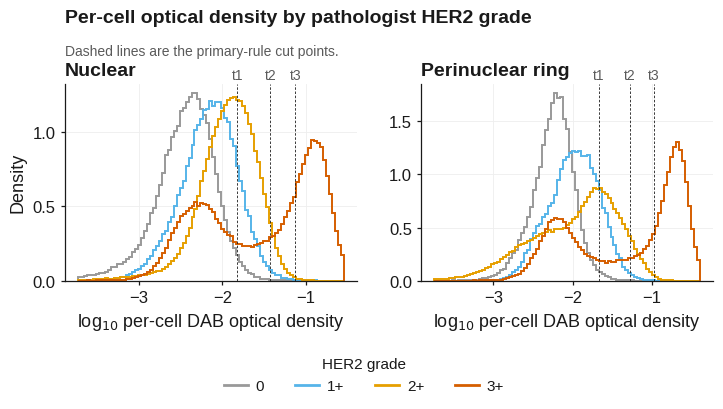

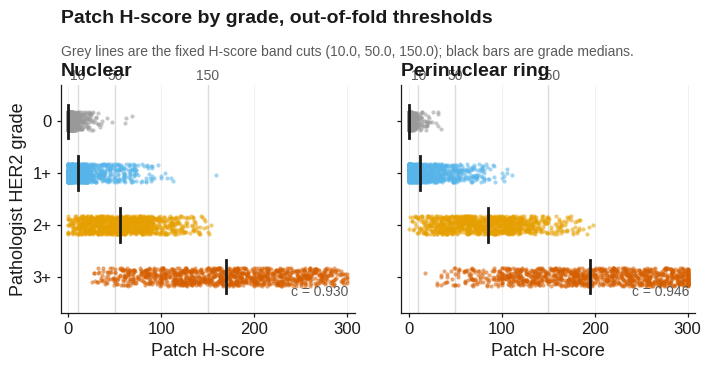

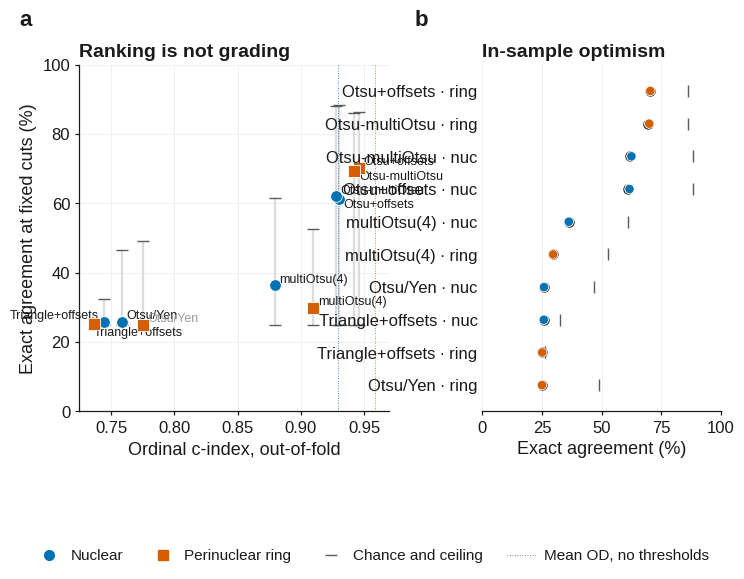

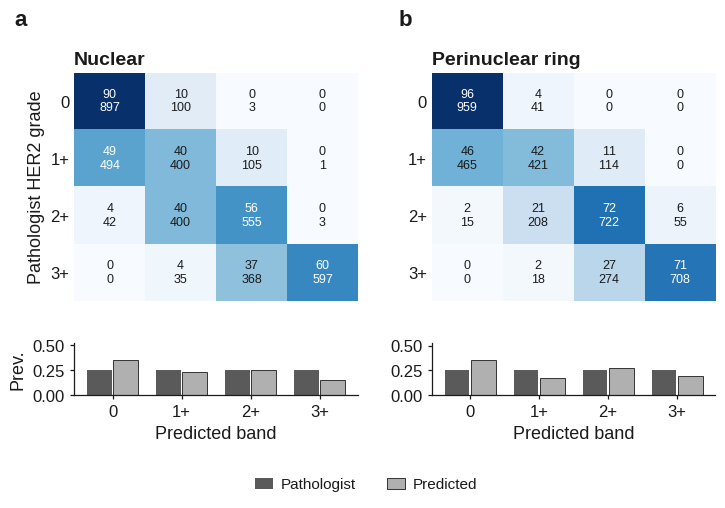

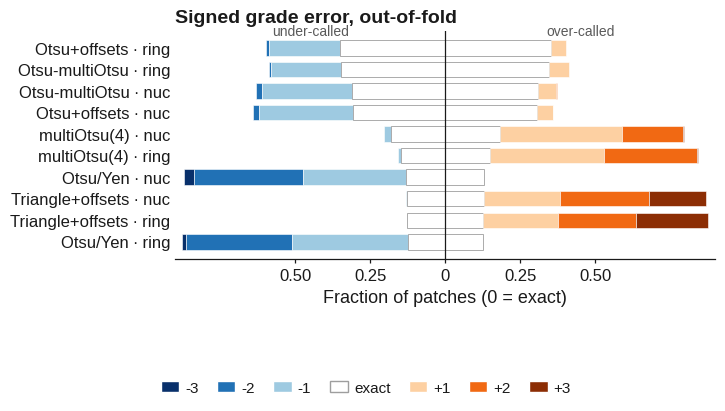

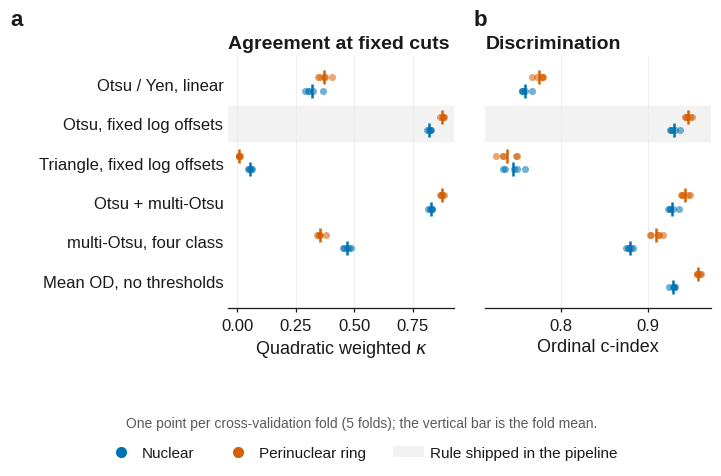

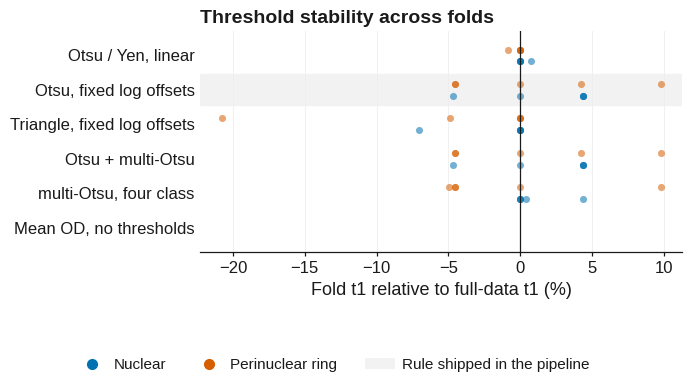

In [ ]:
"""
HER2 validation: analysis and figure program (rewrite).

Companion to hpa_figures_v4.py. Same statistical framing, adapted to the
differences in the HER2 arm:

  - Predicted grades come from FIXED H-score cuts (10, 50, 150), not from
    per-antibody quartiles. Predicted margins are therefore not forced
    uniform, so chance agreement is sum_c p_pred(c) * p_true(c) rather than
    25%, and the attainable ceiling is sum_c min(p_pred(c), p_true(c)).
  - Five-fold stratified CV over patches already exists, so every patch can
    be scored with thresholds fitted on folds that excluded it. Those
    out-of-fold scores are the headline; in-sample scores are shown only as
    the optimism they carry.
  - Both compartments are measured on the same patches, so the compartment
    comparison is paired and gets a bootstrap CI on the within-patch
    difference rather than two independent bars.
  - Threshold-free discrimination (Spearman rho, ordinal c-index) is
    reported separately from agreement at the fixed cuts, and mean OD with
    no thresholds is carried as the reference any thresholded rule has to
    beat.

Inputs (unchanged paths)
------------------------
  {OUT_DIR}/cells_membrane.csv
  {OUT_DIR}/cells_nuclear.csv
      required columns: file, her2_truth, DAB_OD_mean

Outputs in {FIG_DIR}
--------------------
  H1_od_and_score_by_grade.(svg|pdf)
  H2_discrimination_calibration.(svg|pdf)
  H3_error_structure.(svg|pdf)
  H4_method_comparison.(svg|pdf)
  sourcedata_*.csv
  figure_legends.txt
"""

import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from skimage.filters import (threshold_otsu, threshold_yen,
                             threshold_triangle, threshold_multiotsu)
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore', category=RuntimeWarning)

# =============================================================================
# Configuration
# =============================================================================
HER2_DIR = os.environ.get('HER2_DIR',
                          '/content/drive/MyDrive/HER2_IHC_40x')
OUT_DIR = f'{HER2_DIR}/validation_run'
FIG_DIR = f'{OUT_DIR}/figures_v4'
os.makedirs(FIG_DIR, exist_ok=True)

COMPARTMENTS = ['nuclear', 'membrane']
CELLS_PATH = {c: f'{OUT_DIR}/cells_{c}.csv' for c in COMPARTMENTS}

PRIMARY_METHOD = 'Otsu, fixed log offsets'
UPPER_LOG_OFFSETS = (0.398, 0.699)
HCUTS = (10.0, 50.0, 150.0)
N_SPLITS = 5
N_BOOT = 2000
SEED = 0
EPS = 1e-5
RNG = np.random.default_rng(SEED)

GRADES = ['0', '1+', '2+', '3+']
GMAP = {g: i for i, g in enumerate(GRADES)}

COMP_LABEL = {'nuclear': 'Nuclear', 'membrane': 'Perinuclear ring'}
COMP_COLOR = {'nuclear': '#0072B2', 'membrane': '#D55E00'}
COMP_MARKER = {'nuclear': 'o', 'membrane': 's'}

# Okabe-Ito, ordered so grade reads as increasing intensity
GRADE_COLOR = {'0': '#999999', '1+': '#56B4E9',
               '2+': '#E69F00', '3+': '#D55E00'}

GREY = '#5A5A5A'
LIGHT = '#DCDCDC'
INK = '#1A1A1A'
ERR_COLOR = {-3: '#08306B', -2: '#2171B5', -1: '#9ECAE1',
             0: '#FFFFFF',
             1: '#FDD0A2', 2: '#F16913', 3: '#8C2D04'}

# -----------------------------------------------------------------------------
# Typography and output
# -----------------------------------------------------------------------------
# font.sans-serif is a FALLBACK CHAIN: if Arial is missing matplotlib drops to
# the next entry silently. This resolves it once and prints what was actually
# used, so a fallback is never invisible.
#
#   !apt-get update -qq
#   !echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula \
#          select true" | debconf-set-selections
#   !DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
#          ttf-mscorefonts-installer
#   !apt-get install -y -qq fonts-liberation
#   !fc-cache -f
# then delete matplotlib.get_cachedir() and restart the runtime.
#
# Liberation Sans is metrically identical to Arial and is an accepted
# substitute if the mscorefonts download fails, which it often does in Colab.
FONT_PREFERENCE = ['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans']


def resolve_font(candidates):
    from matplotlib import font_manager
    for name in candidates:
        try:
            path = font_manager.findfont(name, fallback_to_default=False)
        except Exception:
            continue
        if path and os.path.exists(path):
            return name, path
    return None, None


FONT_NAME, FONT_PATH = resolve_font(FONT_PREFERENCE)
if FONT_NAME is None:
    FONT_NAME = 'DejaVu Sans'
    print('WARNING: none of the preferred fonts are installed; '
          'falling back to DejaVu Sans.')
elif FONT_NAME != FONT_PREFERENCE[0]:
    print(f'NOTE: {FONT_PREFERENCE[0]} not found. Using {FONT_NAME} '
          f'({FONT_PATH}).')
else:
    print(f'Font in use: {FONT_NAME} ({FONT_PATH})')

# Axis ticks and axis titles never go below 12 pt, per the brief. In-plot
# annotations (point labels, matrix cell counts) are allowed to be smaller
# because they are not axis text and would otherwise force the layout apart.
PT_TICK = 12
PT_LABEL = 13
PT_TITLE = 14
PT_LETTER = 16
PT_LEGEND = 11
PT_ANNOT = 9
PT_SMALL = 10

# Line weights heavy enough to survive a 600 dpi raster and a later reduction.
LW_AXIS = 0.9
LW_GRID = 0.6
LW_EDGE = 0.6
LW_ERR = 1.1

FORMATS = ('svg', 'tiff')
DPI = 600

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [FONT_NAME],
    'font.size': PT_TICK,
    'axes.titlesize': PT_TITLE,
    'axes.titleweight': 'bold',
    'axes.labelsize': PT_LABEL,
    'axes.linewidth': LW_AXIS,
    'axes.edgecolor': INK,
    'xtick.labelsize': PT_TICK,
    'ytick.labelsize': PT_TICK,
    'xtick.major.width': LW_AXIS,
    'ytick.major.width': LW_AXIS,
    'xtick.major.size': 3.2,
    'ytick.major.size': 3.2,
    'xtick.color': INK,
    'ytick.color': INK,
    'text.color': INK,
    'axes.labelcolor': INK,
    'legend.fontsize': PT_LEGEND,
    'lines.linewidth': 1.1,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
})
MM = 1 / 25.4

# =============================================================================
# Fonts and export format
# =============================================================================
# Colab has no Arial, and matplotlib falls through a font.sans-serif list
# silently. Because svg.fonttype is 'none', whatever font actually resolves
# is the name written into the SVG, so a silent fallback means Illustrator
# will not render Arial even on a machine that has it. setup_font() registers
# any fonts it can find, reports what was actually chosen, and pins the family
# to that one name so the SVG carries it unambiguously.
FONT_SEARCH_DIRS = [
    '/usr/share/fonts', '/usr/local/share/fonts',
    os.path.expanduser('~/.fonts'),
    '/content/fonts', '/content/drive/MyDrive/fonts',
]
FONT_PREFERENCE = ['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans']


def setup_font(preference=None, verbose=True):
    """Register available fonts and pin the first preference that exists."""
    from matplotlib import font_manager
    from matplotlib.font_manager import FontProperties

    preference = preference or FONT_PREFERENCE
    for directory in FONT_SEARCH_DIRS:
        if not os.path.isdir(directory):
            continue
        for ext in ('ttf', 'otf', 'TTF', 'OTF'):
            for path in glob.glob(os.path.join(directory, '**', f'*.{ext}'),
                                  recursive=True):
                try:
                    font_manager.fontManager.addfont(path)
                except Exception:
                    pass

    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in preference if n in available), 'DejaVu Sans')
    matplotlib.rcParams['font.family'] = 'sans-serif'
    matplotlib.rcParams['font.sans-serif'] = [chosen]
    if verbose:
        resolved = font_manager.findfont(FontProperties(family=chosen))
        print(f'Font: {chosen}  ({resolved})')
        if chosen != preference[0]:
            print(f'  NOTE: {preference[0]} is not installed on this machine, '
                  f'so figures and SVG text will use {chosen}.')
            print('  To install Arial in Colab, run, then restart the runtime:')
            print('    !sudo apt-get install -y -qq ttf-mscorefonts-installer')
            print('    !sudo fc-cache -f')
            print('    !rm -rf ~/.cache/matplotlib')
    return chosen


FONT_USED = setup_font()

TIFF_DPI = 300          # raster export resolution
SAVE_FORMATS = ('svg', 'pdf', 'tiff')



# =============================================================================
# Threshold methods (unchanged from the pipeline)
# =============================================================================
def to_z(x):
    return np.log10(np.clip(np.asarray(x, float), EPS, None))


def m_otsu_log_offsets(x):
    z1 = float(threshold_otsu(to_z(x)))
    return tuple(10 ** np.array([z1, z1 + UPPER_LOG_OFFSETS[0],
                                 z1 + UPPER_LOG_OFFSETS[1]]))


def m_otsu_yen_linear(x):
    o = float(threshold_otsu(x))
    upper = x[x > o]
    y = float(threshold_yen(upper)) if len(upper) > 5 else o
    t1, t2 = sorted([o, y])
    t3 = float(np.median(x[x > t2])) if (x > t2).any() else t2
    return t1, t2, t3


def m_triangle_log_offsets(x):
    z1 = float(threshold_triangle(to_z(x)))
    return tuple(10 ** np.array([z1, z1 + UPPER_LOG_OFFSETS[0],
                                 z1 + UPPER_LOG_OFFSETS[1]]))


def m_otsu_then_multiotsu(x):
    z = to_z(x)
    z1 = float(threshold_otsu(z))
    upper = z[z > z1]
    if len(upper) < 100:
        return None
    try:
        z2, z3 = threshold_multiotsu(upper, classes=3)
    except ValueError:
        return None
    return tuple(10 ** np.array([z1, z2, z3]))


def m_multiotsu(x):
    try:
        return tuple(10 ** threshold_multiotsu(to_z(x), classes=4))
    except ValueError:
        return None


METHODS = {
    'Otsu / Yen, linear': m_otsu_yen_linear,
    'Otsu, fixed log offsets': m_otsu_log_offsets,
    'Triangle, fixed log offsets': m_triangle_log_offsets,
    'Otsu + multi-Otsu': m_otsu_then_multiotsu,
    'multi-Otsu, four class': m_multiotsu,
}
METHOD_ORDER = list(METHODS)
REFERENCE = 'Mean OD, no thresholds'

# Compact names for axes where the full method name will not fit
SHORT_METHOD = {
    'Otsu / Yen, linear': 'Otsu/Yen',
    'Otsu, fixed log offsets': 'Otsu+offsets',
    'Triangle, fixed log offsets': 'Triangle+offsets',
    'Otsu + multi-Otsu': 'Otsu-multiOtsu',
    'multi-Otsu, four class': 'multiOtsu(4)',
    REFERENCE: 'mean OD',
}
SHORT_COMP = {'nuclear': 'nuc', 'membrane': 'ring'}


def short_row(method, compartment):
    return f'{SHORT_METHOD.get(method, method)} · {SHORT_COMP[compartment]}'


# =============================================================================
# Loading and compact representation
# =============================================================================
def load_compartment(compartment):
    path = CELLS_PATH[compartment]
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, usecols=lambda c: c in
                     {'file', 'her2_truth', 'DAB_OD_mean'})
    missing = {'file', 'her2_truth', 'DAB_OD_mean'} - set(df.columns)
    if missing:
        raise ValueError(f'{path} is missing {sorted(missing)}')
    df['her2_truth'] = df.her2_truth.astype(str)
    df = df[df.her2_truth.isin(GRADES)]
    df['DAB_OD_mean'] = pd.to_numeric(df.DAB_OD_mean, errors='coerce')
    df = df[np.isfinite(df.DAB_OD_mean) & (df.DAB_OD_mean > 0)]
    return df.reset_index(drop=True)


class Compartment:
    """Cell-level optical density indexed by patch, with patch-level truth."""

    def __init__(self, name, df):
        self.name = name
        codes, files = pd.factorize(df.file)
        self.codes = codes.astype(np.int32)
        self.files = np.asarray(files)
        self.x = df.DAB_OD_mean.to_numpy(np.float64)
        self.truth = (df.groupby('file').her2_truth.first()
                      .reindex(self.files).map(GMAP).to_numpy(int))
        self.n_per = np.bincount(self.codes,
                                 minlength=len(self.files)).astype(float)
        self.mean_od = (df.groupby('file').DAB_OD_mean.mean()
                        .reindex(self.files).to_numpy(float))
        self.n_patches = len(self.files)
        self.n_cells = len(self.x)

    def hscore(self, cuts):
        """Patch H-score from cell-level bands at the given cuts."""
        b = np.searchsorted(np.sort(np.asarray(cuts, float)), self.x,
                            side='left')
        h = np.zeros(self.n_patches)
        for k in (1, 2, 3):
            h += k * 100 * np.bincount(self.codes[b == k],
                                       minlength=self.n_patches) / self.n_per
        return h


DATA = {}
for comp in COMPARTMENTS:
    DATA[comp] = Compartment(comp, load_compartment(comp))
    d = DATA[comp]
    print(f'{COMP_LABEL[comp]:<18} {d.n_cells:>10,} cells  '
          f'{d.n_patches:>5,} patches  '
          f'grades {np.bincount(d.truth, minlength=4).tolist()}')


# =============================================================================
# Metrics
# =============================================================================
def bands_from_hscore(h):
    return np.digitize(np.asarray(h, float), HCUTS)


def kappa_w(truth, pred):
    if len(np.unique(truth)) < 2 and len(np.unique(pred)) < 2:
        return np.nan
    return cohen_kappa_score(truth, pred, weights='quadratic',
                             labels=[0, 1, 2, 3])


def ordinal_c_index(score, truth):
    """P(score ranks a higher-grade patch above a lower-grade one), ties 0.5."""
    s = np.asarray(score, float)
    t = np.asarray(truth, float)
    ds = s[:, None] - s[None, :]
    dt = t[:, None] - t[None, :]
    comparable = dt > 0
    n = comparable.sum()
    if n == 0:
        return np.nan
    return (((ds > 0) & comparable).sum()
            + 0.5 * ((ds == 0) & comparable).sum()) / n


def margin_stats(truth, pred, n_classes=4):
    """Chance and ceiling implied by the observed marginal distributions.

    With fixed H-score cuts the predicted margins are whatever the rule
    produces, so neither quantity is a constant the way it is under a
    quartile rule.
    """
    p_true = np.bincount(np.asarray(truth, int),
                         minlength=n_classes) / len(truth)
    p_pred = np.bincount(np.asarray(pred, int),
                         minlength=n_classes) / len(pred)
    return float((p_pred * p_true).sum()), float(np.minimum(p_pred,
                                                            p_true).sum())


def score_metrics(score, truth, label):
    pred = bands_from_hscore(score)
    exact = float(np.mean(pred == truth))
    chance, ceiling = margin_stats(truth, pred)
    denom = ceiling - chance
    return {
        'estimator': label,
        'n_patches': len(truth),
        'rho_spearman': spearmanr(score, truth).statistic,
        'c_index': ordinal_c_index(score, truth),
        'kappa_w': kappa_w(truth, pred),
        'exact_pct': 100 * exact,
        'within_one_pct': 100 * float(np.mean(np.abs(pred - truth) <= 1)),
        'chance_pct': 100 * chance,
        'ceiling_pct': 100 * ceiling,
        'kappa_over_kappa_max': ((exact - chance) / denom
                                 if denom > 1e-9 else np.nan),
        'mean_signed_error': float(np.mean(pred - truth)),
        **{f'err_{d:+d}': float(np.mean((pred - truth) == d))
           for d in range(-3, 4)},
    }


def boot_ci(stat_fn, n, n_boot=N_BOOT, rng=None, alpha=0.05):
    rng = rng or RNG
    out = np.empty(n_boot)
    for b in range(n_boot):
        out[b] = stat_fn(rng.integers(0, n, n))
    lo, hi = np.nanpercentile(out, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


def place_labels(ax, xs, ys, labels, fontsize=5.0, color=INK):
    """Greedy non-overlapping point labels with leader lines when far."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    offsets = [(3.4, 2.2), (3.4, -6.0), (-3.4, 2.2), (-3.4, -6.0),
               (0, 6.0), (0, -8.5), (7.5, 0), (-7.5, 0),
               (7.5, 6.5), (-7.5, -9.0), (12, 4), (-12, -8),
               (16, -8), (-16, 6), (20, 0), (-20, 0)]
    placed = []
    for i in np.argsort(-np.asarray(ys, float)):
        done = False
        for dx, dy in offsets:
            far = abs(dx) > 9 or abs(dy) > 9
            txt = ax.annotate(
                labels[i], (xs[i], ys[i]), textcoords='offset points',
                xytext=(dx, dy), fontsize=fontsize, color=color,
                ha='left' if dx >= 0 else 'right',
                arrowprops=(dict(arrowstyle='-', lw=0.3, color='#B0B0B0',
                                 shrinkA=0.5, shrinkB=1.5) if far else None))
            bb = txt.get_window_extent(renderer=renderer).expanded(1.06, 1.25)
            if not any(bb.overlaps(q) for q in placed):
                placed.append(bb)
                done = True
                break
            txt.remove()
        if not done:
            txt = ax.annotate(labels[i], (xs[i], ys[i]),
                              textcoords='offset points', xytext=(3.4, 2.2),
                              fontsize=fontsize, color='#9A9A9A', ha='left')
            placed.append(txt.get_window_extent(renderer=renderer))


# =============================================================================
# In-sample and out-of-fold scoring
# =============================================================================
insample_rows, oof_rows, fold_rows = [], [], []
THRESHOLDS = {}          # (compartment, method) -> cuts fitted on all cells
SCORES_IS = {}           # (compartment, method) -> in-sample H-scores
SCORES_OOF = {}          # (compartment, method) -> out-of-fold H-scores

for comp in COMPARTMENTS:
    d = DATA[comp]

    # ---- in-sample: thresholds fitted on every cell, scored on every patch
    for method in METHOD_ORDER:
        cuts = METHODS[method](d.x)
        if cuts is None:
            print(f'{comp}/{method}: threshold fit failed; skipped')
            continue
        THRESHOLDS[(comp, method)] = cuts
        h = d.hscore(cuts)
        SCORES_IS[(comp, method)] = h
        row = score_metrics(h, d.truth, method)
        row.update({'compartment': comp, 'fit': 'in-sample',
                    't1': cuts[0], 't2': cuts[1], 't3': cuts[2]})
        insample_rows.append(row)

    # ---- out-of-fold: each patch scored with cuts fitted without it
    oof = {m: np.full(d.n_patches, np.nan) for m in METHOD_ORDER}
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    for fold, (train, test) in enumerate(
            skf.split(np.zeros(d.n_patches), d.truth)):
        train_cells = np.isin(d.codes, train)
        x_train = d.x[train_cells]
        for method in METHOD_ORDER:
            cuts = METHODS[method](x_train)
            if cuts is None:
                continue
            h = d.hscore(cuts)
            oof[method][test] = h[test]
            pred_t = bands_from_hscore(h[test])
            fold_rows.append({
                'compartment': comp, 'method': method, 'fold': fold,
                'n_test': len(test),
                'rho_spearman': spearmanr(h[test], d.truth[test]).statistic,
                'c_index': ordinal_c_index(h[test], d.truth[test]),
                'kappa_w': kappa_w(d.truth[test], pred_t),
                'exact_pct': 100 * float(np.mean(pred_t == d.truth[test])),
                't1': cuts[0], 't2': cuts[1], 't3': cuts[2]})
        # threshold-free reference needs no fitting, recorded once per fold
        fold_rows.append({
            'compartment': comp, 'method': REFERENCE, 'fold': fold,
            'n_test': len(test),
            'rho_spearman': spearmanr(d.mean_od[test],
                                      d.truth[test]).statistic,
            'c_index': ordinal_c_index(d.mean_od[test], d.truth[test]),
            'kappa_w': np.nan, 'exact_pct': np.nan,
            't1': np.nan, 't2': np.nan, 't3': np.nan})

    for method in METHOD_ORDER:
        h = oof[method]
        if not np.isfinite(h).all():
            continue
        SCORES_OOF[(comp, method)] = h
        row = score_metrics(h, d.truth, method)
        row.update({'compartment': comp, 'fit': 'out-of-fold'})
        oof_rows.append(row)

    # threshold-free reference, discrimination only
    ref = {'estimator': REFERENCE, 'compartment': comp, 'fit': 'no thresholds',
           'n_patches': d.n_patches,
           'rho_spearman': spearmanr(d.mean_od, d.truth).statistic,
           'c_index': ordinal_c_index(d.mean_od, d.truth)}
    oof_rows.append(ref)

insample = pd.DataFrame(insample_rows)
oof = pd.DataFrame(oof_rows)
folds = pd.DataFrame(fold_rows)

thresholded_oof = oof[oof.estimator != REFERENCE].copy()
if thresholded_oof.empty:
    raise RuntimeError('No out-of-fold results were produced.')

# optimism: in-sample minus out-of-fold, matched on compartment and method
opt = insample.merge(
    thresholded_oof[['compartment', 'estimator', 'exact_pct', 'kappa_w',
                     'c_index']],
    on=['compartment', 'estimator'], suffixes=('_is', '_oof'))
opt['optimism_pp'] = opt.exact_pct_is - opt.exact_pct_oof
opt['optimism_kappa'] = opt.kappa_w_is - opt.kappa_w_oof


# -----------------------------------------------------------------------------
# Bootstrap CIs on the primary method, and the paired compartment difference
# -----------------------------------------------------------------------------
primary_rows = []
for comp in COMPARTMENTS:
    key = (comp, PRIMARY_METHOD)
    if key not in SCORES_OOF:
        continue
    h, t = SCORES_OOF[key], DATA[comp].truth
    pred = bands_from_hscore(h)
    n = len(t)
    e_lo, e_hi = boot_ci(lambda i: np.mean(pred[i] == t[i]), n)
    k_lo, k_hi = boot_ci(lambda i: kappa_w(t[i], pred[i]), n, n_boot=600)
    primary_rows.append({
        'compartment': comp, 'method': PRIMARY_METHOD,
        'exact_pct': 100 * float(np.mean(pred == t)),
        'exact_ci_low': 100 * e_lo, 'exact_ci_high': 100 * e_hi,
        'kappa_w': kappa_w(t, pred),
        'kappa_ci_low': k_lo, 'kappa_ci_high': k_hi,
        'n_patches': n})
primary = pd.DataFrame(primary_rows)

# paired difference between compartments on the patches they share
paired = None
if len(COMPARTMENTS) == 2 and all((c, PRIMARY_METHOD) in SCORES_OOF
                                  for c in COMPARTMENTS):
    a, b = COMPARTMENTS
    fa = pd.Series(SCORES_OOF[(a, PRIMARY_METHOD)], index=DATA[a].files)
    fb = pd.Series(SCORES_OOF[(b, PRIMARY_METHOD)], index=DATA[b].files)
    shared = fa.index.intersection(fb.index)
    if len(shared) >= 20:
        ta = pd.Series(DATA[a].truth, index=DATA[a].files).reindex(shared)
        t_sh = ta.to_numpy(int)
        pa = bands_from_hscore(fa.reindex(shared).to_numpy(float))
        pb = bands_from_hscore(fb.reindex(shared).to_numpy(float))
        n = len(shared)

        def _dk(i):
            return kappa_w(t_sh[i], pa[i]) - kappa_w(t_sh[i], pb[i])

        dk_lo, dk_hi = boot_ci(_dk, n, n_boot=600)
        paired = pd.DataFrame([{
            'compartment_a': a, 'compartment_b': b,
            'n_shared_patches': n,
            'kappa_a': kappa_w(t_sh, pa), 'kappa_b': kappa_w(t_sh, pb),
            'delta_kappa': kappa_w(t_sh, pa) - kappa_w(t_sh, pb),
            'delta_ci_low': dk_lo, 'delta_ci_high': dk_hi,
            'exact_a_pct': 100 * float(np.mean(pa == t_sh)),
            'exact_b_pct': 100 * float(np.mean(pb == t_sh))}])


# =============================================================================
# Output helper
# =============================================================================
def save(fig, stem):
    """Editable SVG plus a 600 dpi LZW TIFF."""
    paths = []
    for ext in FORMATS:
        p = f'{FIG_DIR}/{stem}.{ext}'
        if ext == 'tiff':
            fig.savefig(p, format='tiff', dpi=DPI, facecolor='white',
                        pil_kwargs={'compression': 'tiff_lzw'})
        else:
            fig.savefig(p, format=ext, facecolor='white')
        paths.append(p)
    return paths


written = []


# =============================================================================
# Figure H1a - per-cell optical density by grade
# =============================================================================
fig_h1 = 108
figH1a = plt.figure(figsize=(183 * MM, fig_h1 * MM))
gs1a = GridSpec(1, 2, figure=figH1a, wspace=0.22, left=0.085, right=0.985,
                top=1 - 24 / fig_h1, bottom=34 / fig_h1)

for col, comp in enumerate(COMPARTMENTS):
    d = DATA[comp]
    cuts = THRESHOLDS.get((comp, PRIMARY_METHOD))
    ax = figH1a.add_subplot(gs1a[0, col])
    z = to_z(d.x)
    cell_truth = d.truth[d.codes]
    lo, hi = np.percentile(z, [0.2, 99.8])
    bins = np.linspace(lo, hi, 90)
    for g in GRADES:
        v = z[cell_truth == GMAP[g]]
        if len(v) == 0:
            continue
        if len(v) > 400_000:
            v = RNG.choice(v, 400_000, replace=False)
        ax.hist(v, bins=bins, density=True, histtype='step', linewidth=1.4,
                color=GRADE_COLOR[g], label=g)
    if cuts is not None:
        for cut, name in zip(cuts, ['t1', 't2', 't3']):
            ax.axvline(np.log10(cut), color=INK, lw=LW_GRID, ls=(0, (3, 2)))
            ax.text(np.log10(cut), 1.01, name,
                    transform=ax.get_xaxis_transform(), fontsize=PT_SMALL,
                    ha='center', va='bottom', color=GREY)
    ax.set_xlabel(r'log$_{10}$ per-cell DAB optical density')
    if col == 0:
        ax.set_ylabel('Density')
    ax.set_title(COMP_LABEL[comp], loc='left', pad=6)
    ax.grid(color='#EEEEEE', lw=LW_GRID)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

hG = [Line2D([0], [0], color=GRADE_COLOR[g], lw=2.0, label=g) for g in GRADES]
figH1a.legend(handles=hG, ncol=4, frameon=False, loc='lower center',
              bbox_to_anchor=(0.5, 2 / fig_h1), title='HER2 grade',
              title_fontsize=PT_LEGEND, fontsize=PT_LEGEND, handlelength=1.6,
              handletextpad=0.5, columnspacing=2.0)
figH1a.text(0.085, 1 - 5 / fig_h1,
            'Per-cell optical density by pathologist HER2 grade',
            fontsize=PT_TITLE, fontweight='bold', va='top')
figH1a.text(0.085, 1 - 14 / fig_h1,
            'Dashed lines are the primary-rule cut points.',
            fontsize=PT_SMALL, color=GREY, va='top')
written += save(figH1a, 'H1a_percell_od_by_grade')


# =============================================================================
# Figure H1b - patch H-score by grade, out-of-fold thresholds
# =============================================================================
figH1b = plt.figure(figsize=(183 * MM, fig_h1 * MM))
gs1b = GridSpec(1, 2, figure=figH1b, wspace=0.16, left=0.105, right=0.985,
                top=1 - 24 / fig_h1, bottom=26 / fig_h1)

for col, comp in enumerate(COMPARTMENTS):
    d = DATA[comp]
    ax = figH1b.add_subplot(gs1b[0, col])
    h = SCORES_OOF.get((comp, PRIMARY_METHOD),
                       SCORES_IS.get((comp, PRIMARY_METHOD)))
    for cut in HCUTS:
        ax.axvline(cut, color=LIGHT, lw=1.0, zorder=0)
        ax.text(cut, 1.01, f'{cut:.0f}', transform=ax.get_xaxis_transform(),
                fontsize=PT_SMALL, ha='center', va='bottom', color=GREY)
    for g in GRADES:
        v = h[d.truth == GMAP[g]]
        if len(v) == 0:
            continue
        jitter = RNG.uniform(-0.18, 0.18, len(v))
        ax.scatter(v, np.full(len(v), GMAP[g]) + jitter, s=9,
                   color=GRADE_COLOR[g], alpha=0.55, linewidths=0, zorder=2)
        med = np.median(v)
        ax.plot([med, med], [GMAP[g] - 0.32, GMAP[g] + 0.32], color=INK,
                lw=2.0, zorder=3)
    ax.set_ylim(3.7, -0.7)
    ax.set_yticks(range(4))
    ax.set_yticklabels(GRADES if col == 0 else [])
    ax.set_xlim(-8, 308)
    ax.set_xticks([0, 100, 200, 300])
    ax.set_xlabel('Patch H-score')
    if col == 0:
        ax.set_ylabel('Pathologist HER2 grade')
    ax.text(0.98, 0.06, f'c = {ordinal_c_index(h, d.truth):.3f}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=PT_SMALL, color=GREY)
    ax.set_title(COMP_LABEL[comp], loc='left', pad=6)
    ax.grid(axis='x', color='#EEEEEE', lw=LW_GRID)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

figH1b.text(0.105, 1 - 5 / fig_h1,
            'Patch H-score by grade, out-of-fold thresholds',
            fontsize=PT_TITLE, fontweight='bold', va='top')
figH1b.text(0.105, 1 - 14 / fig_h1,
            f'Grey lines are the fixed H-score band cuts {HCUTS}; black bars '
            f'are grade medians.', fontsize=PT_SMALL, color=GREY, va='top')
written += save(figH1b, 'H1b_patch_hscore_by_grade')


# =============================================================================
# Figure H2 - discrimination against agreement, and in-sample optimism
# =============================================================================
fig_h2 = 150
figH2 = plt.figure(figsize=(183 * MM, fig_h2 * MM))
gsH2 = GridSpec(1, 2, figure=figH2, wspace=0.34, left=0.095, right=0.985,
                top=1 - 18 / fig_h2, bottom=44 / fig_h2,
                width_ratios=[1.3, 1])
axA = figH2.add_subplot(gsH2[0, 0])
axB = figH2.add_subplot(gsH2[0, 1])

pts = thresholded_oof.dropna(subset=['c_index', 'exact_pct'])
for _, r in pts.iterrows():
    axA.plot([r.c_index, r.c_index], [r.chance_pct, r.ceiling_pct],
             color=LIGHT, lw=1.6, zorder=1, solid_capstyle='butt')
axA.scatter(pts.c_index, pts.ceiling_pct, marker='_', s=80, color=GREY,
            lw=1.0, zorder=2)
axA.scatter(pts.c_index, pts.chance_pct, marker='_', s=80, color=GREY,
            lw=1.0, zorder=2)
for comp in COMPARTMENTS:
    m = pts.compartment == comp
    axA.scatter(pts.c_index[m], pts.exact_pct[m], s=70,
                marker=COMP_MARKER[comp], color=COMP_COLOR[comp],
                edgecolor='white', lw=LW_EDGE, zorder=4,
                label=COMP_LABEL[comp])
for comp in COMPARTMENTS:
    ref = oof[(oof.estimator == REFERENCE) & (oof.compartment == comp)]
    if len(ref):
        axA.axvline(float(ref.c_index.iloc[0]), color=COMP_COLOR[comp],
                    lw=LW_GRID, ls=(0, (1, 2)), zorder=1)
place_labels(axA, pts.c_index.to_numpy(float), pts.exact_pct.to_numpy(float),
             [SHORT_METHOD.get(m, m) for m in pts.estimator],
             fontsize=PT_ANNOT)
axA.set_xlabel('Ordinal c-index, out-of-fold')
axA.set_ylabel('Exact agreement at fixed cuts (%)')
axA.set_ylim(0, 100)
_cx = pts.c_index.to_numpy(float)
if np.ptp(_cx) < 0.02:
    axA.set_xlim(np.nanmin(_cx) - 0.02, min(1.005, np.nanmax(_cx) + 0.02))
axA.grid(color='#EEEEEE', lw=LW_GRID)
axA.set_axisbelow(True)
axA.spines[['top', 'right']].set_visible(False)
axA.set_title('Ranking is not grading', loc='left', pad=6)
figH2.text(0.012, 1 - 4 / fig_h2, 'a', fontsize=PT_LETTER,
           fontweight='bold', va='top')
hA = [Line2D([0], [0], marker=COMP_MARKER[c], ls='', ms=7,
             color=COMP_COLOR[c], label=COMP_LABEL[c]) for c in COMPARTMENTS]
hA += [Line2D([0], [0], marker='_', ls='', ms=9, color=GREY,
              label='Chance and ceiling'),
       Line2D([0], [0], ls=(0, (1, 2)), lw=LW_GRID, color=GREY,
              label='Mean OD, no thresholds')]
figH2.legend(handles=hA, ncol=4, frameon=False, fontsize=PT_LEGEND,
             loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h2),
             handletextpad=0.4, columnspacing=1.6)

srt = opt.sort_values('exact_pct_oof').reset_index(drop=True)
yy = np.arange(len(srt))
axB.hlines(yy, srt.exact_pct_oof, srt.exact_pct_is, color=LIGHT, lw=3.0,
           zorder=1)
axB.scatter(srt.exact_pct_oof, yy, s=42, color='white', edgecolor=INK,
            lw=1.0, zorder=3, label='Out-of-fold')
axB.scatter(srt.exact_pct_is, yy, s=46,
            color=[COMP_COLOR[c] for c in srt.compartment],
            edgecolor='white', lw=LW_EDGE, zorder=4, label='In sample')
axB.scatter(srt.ceiling_pct, yy, marker='|', s=80, color=GREY, lw=1.0,
            zorder=2, label='Ceiling')
axB.set_yticks(yy)
axB.set_yticklabels([short_row(m, c) for m, c in
                     zip(srt.estimator, srt.compartment)], fontsize=PT_TICK)
axB.set_ylim(-0.8, len(srt) - 0.2)
axB.set_xlim(0, 100)
axB.set_xlabel('Exact agreement (%)')
axB.grid(axis='x', color='#EEEEEE', lw=LW_GRID)
axB.set_axisbelow(True)
axB.spines[['top', 'right', 'left']].set_visible(False)
axB.tick_params(axis='y', length=0)
axB.set_title('In-sample optimism', loc='left', pad=6)
figH2.text(0.560, 1 - 4 / fig_h2, 'b', fontsize=PT_LETTER,
           fontweight='bold', va='top')
written += save(figH2, 'H2_discrimination_calibration')


# =============================================================================
# Figure H3a - confusion matrices, primary method, out of fold
# =============================================================================
fig_h3a = 132
figH3a = plt.figure(figsize=(183 * MM, fig_h3a * MM))
gs3a = GridSpec(1, 2, figure=figH3a, wspace=0.26, left=0.095, right=0.985,
                top=1 - 20 / fig_h3a, bottom=30 / fig_h3a)

for col, comp in enumerate(COMPARTMENTS):
    inner = gs3a[0, col].subgridspec(2, 1, height_ratios=[4.4, 1], hspace=0.30)
    axc = figH3a.add_subplot(inner[0])
    axm = figH3a.add_subplot(inner[1])

    key = (comp, PRIMARY_METHOD)
    h = SCORES_OOF.get(key, SCORES_IS.get(key))
    t = DATA[comp].truth
    pred = bands_from_hscore(h)
    conf = np.zeros((4, 4))
    for ti, pi in zip(t, pred):
        conf[int(ti), int(pi)] += 1
    rown = conf / np.clip(conf.sum(axis=1, keepdims=True), 1, None)
    axc.imshow(rown, cmap='Blues', vmin=0, vmax=rown.max(), aspect='auto')
    for i in range(4):
        for j in range(4):
            axc.text(j, i, f'{rown[i, j]*100:.0f}\n{int(conf[i, j])}',
                     ha='center', va='center', fontsize=PT_ANNOT,
                     color='white' if rown[i, j] > 0.55 * rown.max() else INK)
    axc.set_xlim(-0.5, 3.5)
    axc.set_xticks(range(4)); axc.set_yticks(range(4))
    axc.set_xticklabels([])
    axc.set_yticklabels(GRADES)
    if col == 0:
        axc.set_ylabel('Pathologist HER2 grade')
    axc.set_title(COMP_LABEL[comp], loc='left', pad=6)
    for sp in axc.spines.values():
        sp.set_visible(False)
    axc.tick_params(length=0)

    p_true = conf.sum(axis=1) / conf.sum()
    p_pred = conf.sum(axis=0) / conf.sum()
    xm = np.arange(4)
    axm.bar(xm - 0.19, p_true, width=0.36, color=GREY, label='Pathologist')
    axm.bar(xm + 0.19, p_pred, width=0.36, color='#B0B0B0', edgecolor=INK,
            lw=0.6, label='Predicted')
    axm.set_xticks(xm)
    axm.set_xticklabels(GRADES)
    axm.set_ylim(0, max(p_true.max(), p_pred.max()) * 1.45)
    axm.set_yticks([0, 0.25, 0.5])
    axm.set_xlabel('Predicted band')
    if col == 0:
        axm.set_ylabel('Prev.')
    axm.spines[['top', 'right']].set_visible(False)

figH3a.text(0.012, 1 - 4 / fig_h3a, 'a', fontsize=PT_LETTER,
            fontweight='bold', va='top')
figH3a.text(0.545, 1 - 4 / fig_h3a, 'b', fontsize=PT_LETTER,
            fontweight='bold', va='top')
_hm, _lm = axm.get_legend_handles_labels()
figH3a.legend(_hm, _lm, ncol=2, frameon=False, fontsize=PT_LEGEND,
              loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h3a),
              handlelength=1.2, handletextpad=0.5, columnspacing=2.0)
written += save(figH3a, 'H3a_confusion_by_compartment')


# =============================================================================
# Figure H3b - signed grade error for every method and compartment
# =============================================================================
err = thresholded_oof.copy()
err['row_label'] = [short_row(m, c) for m, c in
                    zip(err.estimator, err.compartment)]
err = err.sort_values('exact_pct').reset_index(drop=True)

fig_h3b = max(110, 46 + 7.0 * len(err))
figH3b, axE = plt.subplots(figsize=(183 * MM, fig_h3b * MM))
figH3b.subplots_adjust(left=0.235, right=0.985, top=1 - 18 / fig_h3b,
                       bottom=40 / fig_h3b)
for i, r in err.iterrows():
    left = -(r['err_-1'] + r['err_-2'] + r['err_-3']) - r['err_+0'] / 2
    for dd in [-3, -2, -1, 0, 1, 2, 3]:
        w = r[f'err_{dd:+d}']
        if w <= 0:
            continue
        axE.barh(i, w, left=left, height=0.72, color=ERR_COLOR[dd],
                 edgecolor='#9E9E9E' if dd == 0 else 'white',
                 lw=0.6 if dd == 0 else 0.4, zorder=2)
        left += w
axE.axvline(0, color=INK, lw=LW_AXIS, zorder=3)
axE.set_yticks(np.arange(len(err)))
axE.set_yticklabels(err.row_label)
axE.set_ylim(-0.8, len(err) - 0.2)
axE.set_xlim(-0.9, 0.9)
axE.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
axE.set_xticklabels(['0.50', '0.25', '0', '0.25', '0.50'])
axE.set_xlabel('Fraction of patches (0 = exact)')
axE.tick_params(axis='y', length=0)
axE.spines[['top', 'right', 'left']].set_visible(False)
axE.set_title('Signed grade error, out-of-fold', loc='left', pad=6)
axE.text(-0.45, len(err) - 0.55, 'under-called', fontsize=PT_SMALL,
         color=GREY, ha='center', va='bottom')
axE.text(0.45, len(err) - 0.55, 'over-called', fontsize=PT_SMALL,
         color=GREY, ha='center', va='bottom')
legE = [Patch(facecolor=ERR_COLOR[dd],
              edgecolor='#9E9E9E' if dd == 0 else 'white',
              label=('exact' if dd == 0 else f'{dd:+d}'))
        for dd in [-3, -2, -1, 0, 1, 2, 3]]
figH3b.legend(handles=legE, ncol=7, frameon=False, fontsize=PT_LEGEND,
              loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h3b),
              handlelength=1.2, handletextpad=0.4, columnspacing=1.2)
written += save(figH3b, 'H3b_signed_error')


# =============================================================================
# Figure H4a - per-fold agreement and discrimination by method
# =============================================================================
present = [m for m in METHOD_ORDER if m in set(folds.method)]
rows_order = present + ([REFERENCE] if REFERENCE in set(folds.method) else [])
ypos = {m: i for i, m in enumerate(rows_order[::-1])}

fig_h4 = max(120, 58 + 11.0 * len(rows_order))
figH4a = plt.figure(figsize=(183 * MM, fig_h4 * MM))
gs4a = GridSpec(1, 2, figure=figH4a, wspace=0.14, left=0.315, right=0.985,
                top=1 - 16 / fig_h4, bottom=44 / fig_h4)
axK = figH4a.add_subplot(gs4a[0, 0])
axR = figH4a.add_subplot(gs4a[0, 1])


def fold_panel(ax, metric, xlabel, title, show_labels):
    for m in rows_order:
        if m == PRIMARY_METHOD:
            ax.axhspan(ypos[m] - 0.45, ypos[m] + 0.45, color='#F2F2F2',
                       zorder=0)
    for m in rows_order:
        for comp in COMPARTMENTS:
            sub = folds[(folds.method == m) & (folds.compartment == comp)]
            v = sub[metric].to_numpy(float)
            v = v[np.isfinite(v)]
            if len(v) == 0:
                continue
            off = -0.17 if comp == COMPARTMENTS[0] else 0.17
            ax.scatter(v, np.full(len(v), ypos[m] + off), s=26,
                       color=COMP_COLOR[comp], alpha=0.55, linewidths=0,
                       zorder=2)
            ax.scatter([v.mean()], [ypos[m] + off], s=110, marker='|',
                       color=COMP_COLOR[comp], lw=1.8, zorder=3)
    ax.set_yticks([ypos[m] for m in rows_order])
    ax.set_yticklabels(rows_order if show_labels else [])
    ax.set_ylim(-0.7, len(rows_order) - 0.3)
    ax.tick_params(axis='y', length=0)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', color='#EEEEEE', lw=LW_GRID)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_title(title, loc='left', pad=6)
    v_all = folds[metric].to_numpy(float)
    v_all = v_all[np.isfinite(v_all)]
    if len(v_all) and np.ptp(v_all) < 1e-3:
        ax.set_xlim(v_all.mean() - 0.02, v_all.mean() + 0.02)


fold_panel(axK, 'kappa_w', r'Quadratic weighted $\kappa$',
           'Agreement at fixed cuts', True)
fold_panel(axR, 'c_index', 'Ordinal c-index', 'Discrimination', False)
figH4a.text(0.012, 1 - 4 / fig_h4, 'a', fontsize=PT_LETTER,
            fontweight='bold', va='top')
figH4a.text(0.655, 1 - 4 / fig_h4, 'b', fontsize=PT_LETTER,
            fontweight='bold', va='top')
hH4 = [Line2D([0], [0], marker='o', ls='', ms=7, color=COMP_COLOR[c],
              label=COMP_LABEL[c]) for c in COMPARTMENTS]
hH4.append(Patch(facecolor='#F2F2F2', edgecolor='none',
                 label='Rule shipped in the pipeline'))
figH4a.legend(handles=hH4, ncol=3, frameon=False, fontsize=PT_LEGEND,
              loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h4),
              handletextpad=0.4, columnspacing=1.8)
figH4a.text(0.5, 13 / fig_h4,
            f'One point per cross-validation fold ({N_SPLITS} folds); '
            f'the vertical bar is the fold mean.',
            fontsize=PT_SMALL, color=GREY, ha='center', va='bottom')
written += save(figH4a, 'H4a_method_comparison')


# =============================================================================
# Figure H4b - threshold stability across folds
# =============================================================================
fig_h4b = max(105, 46 + 11.0 * len(rows_order))
figH4b, axT = plt.subplots(figsize=(183 * MM, fig_h4b * MM))
figH4b.subplots_adjust(left=0.315, right=0.985, top=1 - 20 / fig_h4b,
                       bottom=36 / fig_h4b)
for m in rows_order:
    if m == PRIMARY_METHOD:
        axT.axhspan(ypos[m] - 0.45, ypos[m] + 0.45, color='#F2F2F2', zorder=0)
for m in rows_order:
    if m == REFERENCE:
        continue
    for comp in COMPARTMENTS:
        sub = folds[(folds.method == m) & (folds.compartment == comp)]
        t1 = sub.t1.to_numpy(float)
        t1 = t1[np.isfinite(t1)]
        base = THRESHOLDS.get((comp, m), (np.nan,))[0]
        if len(t1) == 0 or not np.isfinite(base) or base <= 0:
            continue
        rel = 100 * (t1 / base - 1)
        off = -0.17 if comp == COMPARTMENTS[0] else 0.17
        axT.scatter(rel, np.full(len(rel), ypos[m] + off), s=26,
                    color=COMP_COLOR[comp], alpha=0.55, linewidths=0, zorder=2)
axT.axvline(0, color=INK, lw=LW_AXIS)
axT.set_yticks([ypos[m] for m in rows_order])
axT.set_yticklabels(rows_order)
axT.set_ylim(-0.7, len(rows_order) - 0.3)
axT.tick_params(axis='y', length=0)
axT.set_xlabel('Fold t1 relative to full-data t1 (%)')
axT.grid(axis='x', color='#EEEEEE', lw=LW_GRID)
axT.set_axisbelow(True)
axT.spines[['top', 'right', 'left']].set_visible(False)
axT.set_title('Threshold stability across folds', loc='left', pad=6)
figH4b.legend(handles=hH4, ncol=3, frameon=False, fontsize=PT_LEGEND,
              loc='lower center', bbox_to_anchor=(0.5, 2 / fig_h4b),
              handletextpad=0.4, columnspacing=1.8)
written += save(figH4b, 'H4b_threshold_stability')


# =============================================================================
# Tables, legends, archive
# =============================================================================
tables = {
    'sourcedata_her2_insample.csv': insample,
    'sourcedata_her2_outoffold.csv': oof,
    'sourcedata_her2_folds.csv': folds,
    'sourcedata_her2_optimism.csv': opt,
    'sourcedata_her2_primary_ci.csv': primary,
}
if paired is not None:
    tables['sourcedata_her2_compartment_paired.csv'] = paired
for name, df in tables.items():
    df.to_csv(f'{FIG_DIR}/{name}', index=False)
    written.append(f'{FIG_DIR}/{name}')

caption = f"""\
Figure H1 | Raw evidence, split across two panels for legibility. H1a,
distribution of log10 per-cell mean deconvolved DAB optical density for each
pathologist HER2 grade, in each measurement compartment; dashed lines are the
cut points produced by the {PRIMARY_METHOD} rule fitted on all cells. H1b,
patch H-score computed with out-of-fold thresholds, one point per patch,
grouped by grade; black bars are grade medians and grey lines the fixed
H-score band cuts {HCUTS}. The ordinal c-index is the probability that the
H-score ranks a higher-grade patch above a lower-grade one.

Figure H2 | Discrimination and grade agreement are distinct. a, Exact
four-class agreement at the fixed H-score cuts, using out-of-fold thresholds,
against threshold-free discrimination, for every threshold method and
compartment. The vertical line at each point spans the chance agreement and
the attainable ceiling implied by that estimator's predicted and observed
grade prevalences; dotted vertical lines mark the c-index of mean optical
density with no thresholds. b, Exact agreement with thresholds fitted in
sample and out of fold, with the ceiling marked; the gap is the optimism
carried by in-sample threshold fitting.

Figure H3 | Structure of the disagreements under the {PRIMARY_METHOD} rule,
out of fold. H3a, confusion matrices for each compartment, showing row
percentages and patch counts, with the marginal grade prevalence of the
pathologist labels and of the predictions below. H3b, distribution of signed
grade error for every method and compartment, centred on exact agreement;
bars to the left are under-called patches and to the right over-called.

Figure H4 | Threshold method comparison across {N_SPLITS} cross-validation
folds. H4a, quadratic weighted kappa at the fixed H-score cuts and ordinal
c-index, one point per fold with the fold mean marked; the c-index panel
includes mean optical density with no thresholds as a threshold-free
reference. H4b, the first cut point estimated within each fold, expressed
relative to the cut point fitted on all cells, as a measure of how stable
each rule is to the sample it is fitted on. The shaded row is the rule
shipped in the pipeline.

Typeset in {FONT_NAME}. Figures are 183 mm wide; axis text is 12 pt and must
not be rescaled when assembling composites.
"""
with open(f'{FIG_DIR}/figure_legends.txt', 'w', encoding='utf-8') as fh:
    fh.write(caption)
written.append(f'{FIG_DIR}/figure_legends.txt')

zip_path = f'{FIG_DIR}/HER2_figures_v4.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in written:
        z.write(p, os.path.basename(p))

print('\nOut-of-fold, per compartment and method:')
print(thresholded_oof[['compartment', 'estimator', 'n_patches', 'c_index',
                       'kappa_w', 'exact_pct', 'chance_pct', 'ceiling_pct',
                       'kappa_over_kappa_max']].round(3).to_string(index=False))
print('\nOptimism (in-sample minus out-of-fold):')
print(opt[['compartment', 'estimator', 'exact_pct_is', 'exact_pct_oof',
           'optimism_pp', 'optimism_kappa']].round(3).to_string(index=False))
print('\nPrimary method, bootstrap CIs over patches:')
print(primary.round(3).to_string(index=False))
if paired is not None:
    print('\nPaired compartment difference on shared patches:')
    print(paired.round(3).to_string(index=False))
print(f'\nWritten to {FIG_DIR}')
print(zip_path)

if os.environ.get('HER2_SHOW', '1') == '1':
    plt.show()